# Haar and DCT Time Reparameterization in NumPyro

Many time series models have one latent variable per time step. A local level model, for example, has one random-walk increment per week. These variables are independent under the prior, but the data couple them, because every observation depends on all the increments before it.

This coupling is a problem for the two inference methods we use most. A mean-field variational guide, such as `AutoNormal`, has one independent Normal per coordinate and cannot represent it. The NUTS sampler with a diagonal mass matrix can represent it, but it needs small steps and long trajectories.

Pyro addresses this coupling in its forecasting module with the `time_reparam` argument of the [`Forecaster`](https://docs.pyro.ai/en/stable/contrib.forecast.html) class. It rewrites every time-indexed latent variable in a Haar wavelet basis or in a discrete cosine basis. Both bases are orthonormal, so this change of variables is a rotation. The model does not change, only the coordinates that the guide or the sampler works with.

This reparameterization is now available in the NumPyro ecosystem. The transforms `HaarTransform` and `DiscreteCosineTransform`, and the reparameterizers `HaarReparam` and `DiscreteCosineReparam`, are part of NumPyro since version `0.22` (see [numpyro#2208](https://github.com/pyro-ppl/numpyro/pull/2208)). The function `time_reparam` of [`numpyro_forecast`](https://github.com/juanitorduz/numpyro_forecast) applies them to the latent variables under the `time` plate of a forecasting model (see [numpyro_forecast#135](https://github.com/juanitorduz/numpyro_forecast/pull/135)).

In this notebook we answer three questions: *what* this reparameterization is, *why* it helps, and *how* NumPyro implements it. We first work with a model where we can compute everything exactly, and then we move to a real forecasting model.

For a weekly ridership model, the same `AutoNormal` guide improves its evidence lower bound (ELBO) by about $75$ to $80$ nats (natural-log units) in the rotated coordinates, and its estimates and forecasts move toward the NUTS reference. The rotation is not a complete fix: the uncertainty of the level is still too small, and with the DCT it collapses at the end of the series.

For NUTS the rotation reduces the number of leapfrog steps, as the theory predicts. Each step costs more, though, and on the ridership model there is no overall gain per second.

We assume that you can write a NumPyro model and that you have used stochastic variational inference (SVI) and NUTS before. On the math side we need orthogonal matrices, eigenvalues and the multivariate Gaussian distribution.

For an introduction to SVI see [PyData Berlin 2025: Introduction to Stochastic Variational Inference with NumPyro](https://juanitorduz.github.io/intro_svi/). The forecasting example is the model from [From Pyro to NumPyro: Forecasting a univariate, heavy tailed time series](https://juanitorduz.github.io/numpyro_forecasting-univariate/).

## Outline

Here are the steps we follow:

1. **Local Level Model.** We write the simplest model with a time-indexed latent variable and compute its posterior in closed form.
2. **Posterior Geometry.** We look at the shape of that posterior and at why it is hard for coordinate-wise methods.
3. **Orthonormal Time Transforms.** We define the reparameterization and the two bases, the discrete cosine transform (DCT) and the Haar transform.
4. **Mean-Field Gap.** We derive how much a mean-field guide loses in each basis, and what this does to the uncertainty of the level and to the scale estimates.
5. **Sampler Conditioning.** We derive what a diagonal mass matrix leaves for the sampler in each basis.
6. **NumPyro Implementation.** We sketch the transforms, the reparameterizers and the function `time_reparam`.
7. **Local Level Experiments.** We check the two derivations with SVI and NUTS.
8. **Ridership Forecasting Model.** We move to the weekly BART ridership data and to a model with unknown scales and a heavy-tailed likelihood.
9. **Variational Inference.** We compare the ELBO of the same guide in the three coordinate systems.
10. **NUTS Sampling.** We compare the cost and the effective sample size of NUTS in the three coordinate systems.
11. **Posterior and Forecast Comparison.** We compare the variational fits with the NUTS reference and score the forecasts.

## Prepare Notebook

We need NumPyro `0.22` or later and `numpyro_forecast` `0.4` or later.

In [1]:
from collections.abc import Callable
from time import perf_counter
from typing import NamedTuple

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from jax import random
from jax.example_libraries.optimizers import exponential_decay
from jaxtyping import Array, Float
from matplotlib.lines import Line2D
from numpyro import handlers
from numpyro.distributions.transforms import (
    DiscreteCosineTransform,
    HaarTransform,
    Transform,
)
from numpyro.infer import (
    MCMC,
    NUTS,
    SVI,
    Predictive,
    Trace_ELBO,
    init_to_uniform,
    init_to_value,
)
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.reparam import DiscreteCosineReparam, HaarReparam, LocScaleReparam
from numpyro.infer.util import log_density
from numpyro.optim import Adam
from numpyro_forecast import (
    Horizon,
    draw_posterior,
    eval_crps,
    forecast,
    innovations,
    predict,
    predict_in_sample,
    time_reparam,
)
from numpyro_forecast.datasets import load_bart_weekly
from numpyro_forecast.features import fourier_features
from scipy.optimize import minimize
from xarray import DataTree

numpyro.set_host_device_count(n=4)

seed: int = 42
rng_key = random.PRNGKey(seed=seed)

HDI_PROB = 0.94

az.style.use("arviz-darkgrid")
az.rcParams["stats.ci_kind"] = "hdi"
az.rcParams["stats.ci_prob"] = HDI_PROB
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

# One color per coordinate system, used in every figure.
COLORS = {"none": "C0", "haar": "C1", "dct": "C2"}

# Numbers inside bars, on a white box so that they stay readable.
BAR_LABEL_STYLE = {
    "label_type": "center",
    "fontsize": 13,
    "bbox": {"boxstyle": "round,pad=0.2", "facecolor": "white", "edgecolor": "none"},
}

Model = Callable[..., None]

%config InlineBackend.figure_format = "retina"

## Local Level Model

We start with the simplest model that has the problem. Let $T$ be the number of time steps and $y_t$ the observation at time $t = 1, \ldots, T$. The local level model says that $y_t$ is a noisy measurement of a latent level $\ell_t$, and that the level is a random walk with increments $\delta_t$.

The quantity we want is the posterior of the increments given the observations. We want to know how well a mean-field guide can approximate it and how fast NUTS can sample from it.

Let $\sigma_\delta$ be the scale of the increments and $\sigma$ the scale of the observation noise. The model is

$$
\delta_t \sim \text{Normal}(0, \sigma_\delta), \qquad \ell_t = \sum_{s \le t} \delta_s, \qquad y_t \sim \text{Normal}(\ell_t, \sigma).
$$

The latent variables are the increments $\delta = (\delta_1, \ldots, \delta_T)$, not the levels. This is how the Pyro forecasting tutorial and the `innovations` building block of `numpyro_forecast` write a random walk: sample white noise and take a cumulative sum. In vector form the level is $\ell = L \delta$, where $L$ is the $T \times T$ lower-triangular matrix of ones.

In this first part we keep the two scales $\sigma_\delta$ and $\sigma$ fixed. Then the model is linear and Gaussian and we can compute everything exactly. We come back to unknown scales and to a non-Gaussian likelihood in the ridership example.

First, let's write the model in NumPyro. The time axis is an event dimension of the `drift` site.

In [2]:
T_TOY = 256
DRIFT_SCALE = 0.2
SIGMA = 1.0


def local_level_model(
    t_obs: int,
    drift_scale: float,
    sigma: float,
    y: Float[Array, " t_obs"] | None = None,
) -> None:
    "Local level model with the increments as latent variables."
    drift = numpyro.sample(
        "drift", dist.Normal(0.0, drift_scale).expand([t_obs]).to_event(1)
    )
    level = numpyro.deterministic("level", jnp.cumsum(drift))
    numpyro.sample("y", dist.Normal(level, sigma).to_event(1), obs=y)

Next, we simulate one data set from the model itself. We use $T = 256$ time steps, $\sigma_\delta = 0.2$ and $\sigma = 1$.

In [3]:
toy_args = (T_TOY, DRIFT_SCALE, SIGMA)

rng_key, rng_subkey = random.split(rng_key)
prior_draw = Predictive(local_level_model, num_samples=1)(rng_subkey, *toy_args)
toy_drift = prior_draw["drift"][0]
toy_level = prior_draw["level"][0]
toy_y = prior_draw["y"][0]

### Exact Posterior

The prior of $\delta$ is Gaussian and the likelihood is Gaussian in $L \delta$. Therefore the posterior $\text{P}(\delta \mid y)$ is a multivariate Gaussian.

Let $\bar{\delta}$ be its mean and $\Lambda$ its precision matrix (the inverse of its covariance). They are

$$
\Lambda = \frac{1}{\sigma_\delta^2} I + \frac{1}{\sigma^2} L^\top L, \qquad \bar{\delta} = \frac{1}{\sigma^2} \Lambda^{-1} L^\top y.
$$

We make two remarks:

- **The precision does not depend on the data.** It only depends on $T$ and on the two scales. The geometry we study below is a property of the model, not of one data set.
- **The coupling comes from the cumulative sum.** The entry $(L^\top L)_{ij} = T + 1 - \max(i, j)$ counts the observations that depend on both $\delta_i$ and $\delta_j$. Two increments are coupled through every observation at or after the later of the two.

Let's compute the exact posterior of the increments and of the level $\ell = L \delta$, which has mean $L \bar{\delta}$ and covariance $L \Lambda^{-1} L^\top$.

In [4]:
def posterior_precision(t_obs: int, drift_scale: float, sigma: float) -> np.ndarray:
    "Posterior precision of the increments of the local level model."
    cumsum = np.tril(np.ones((t_obs, t_obs)))
    return np.eye(t_obs) / drift_scale**2 + cumsum.T @ cumsum / sigma**2


toy_time = np.arange(1, T_TOY + 1)
cumsum_matrix = np.tril(np.ones((T_TOY, T_TOY)))

precision = posterior_precision(*toy_args)
covariance = np.linalg.inv(precision)

drift_mean = covariance @ cumsum_matrix.T @ np.asarray(toy_y, dtype=float) / SIGMA**2
level_mean = cumsum_matrix @ drift_mean
level_sd = np.sqrt(np.diag(cumsum_matrix @ covariance @ cumsum_matrix.T))

We plot the simulated observations, the level that generated them, and the exact posterior of the level with its central $94\%$ interval.

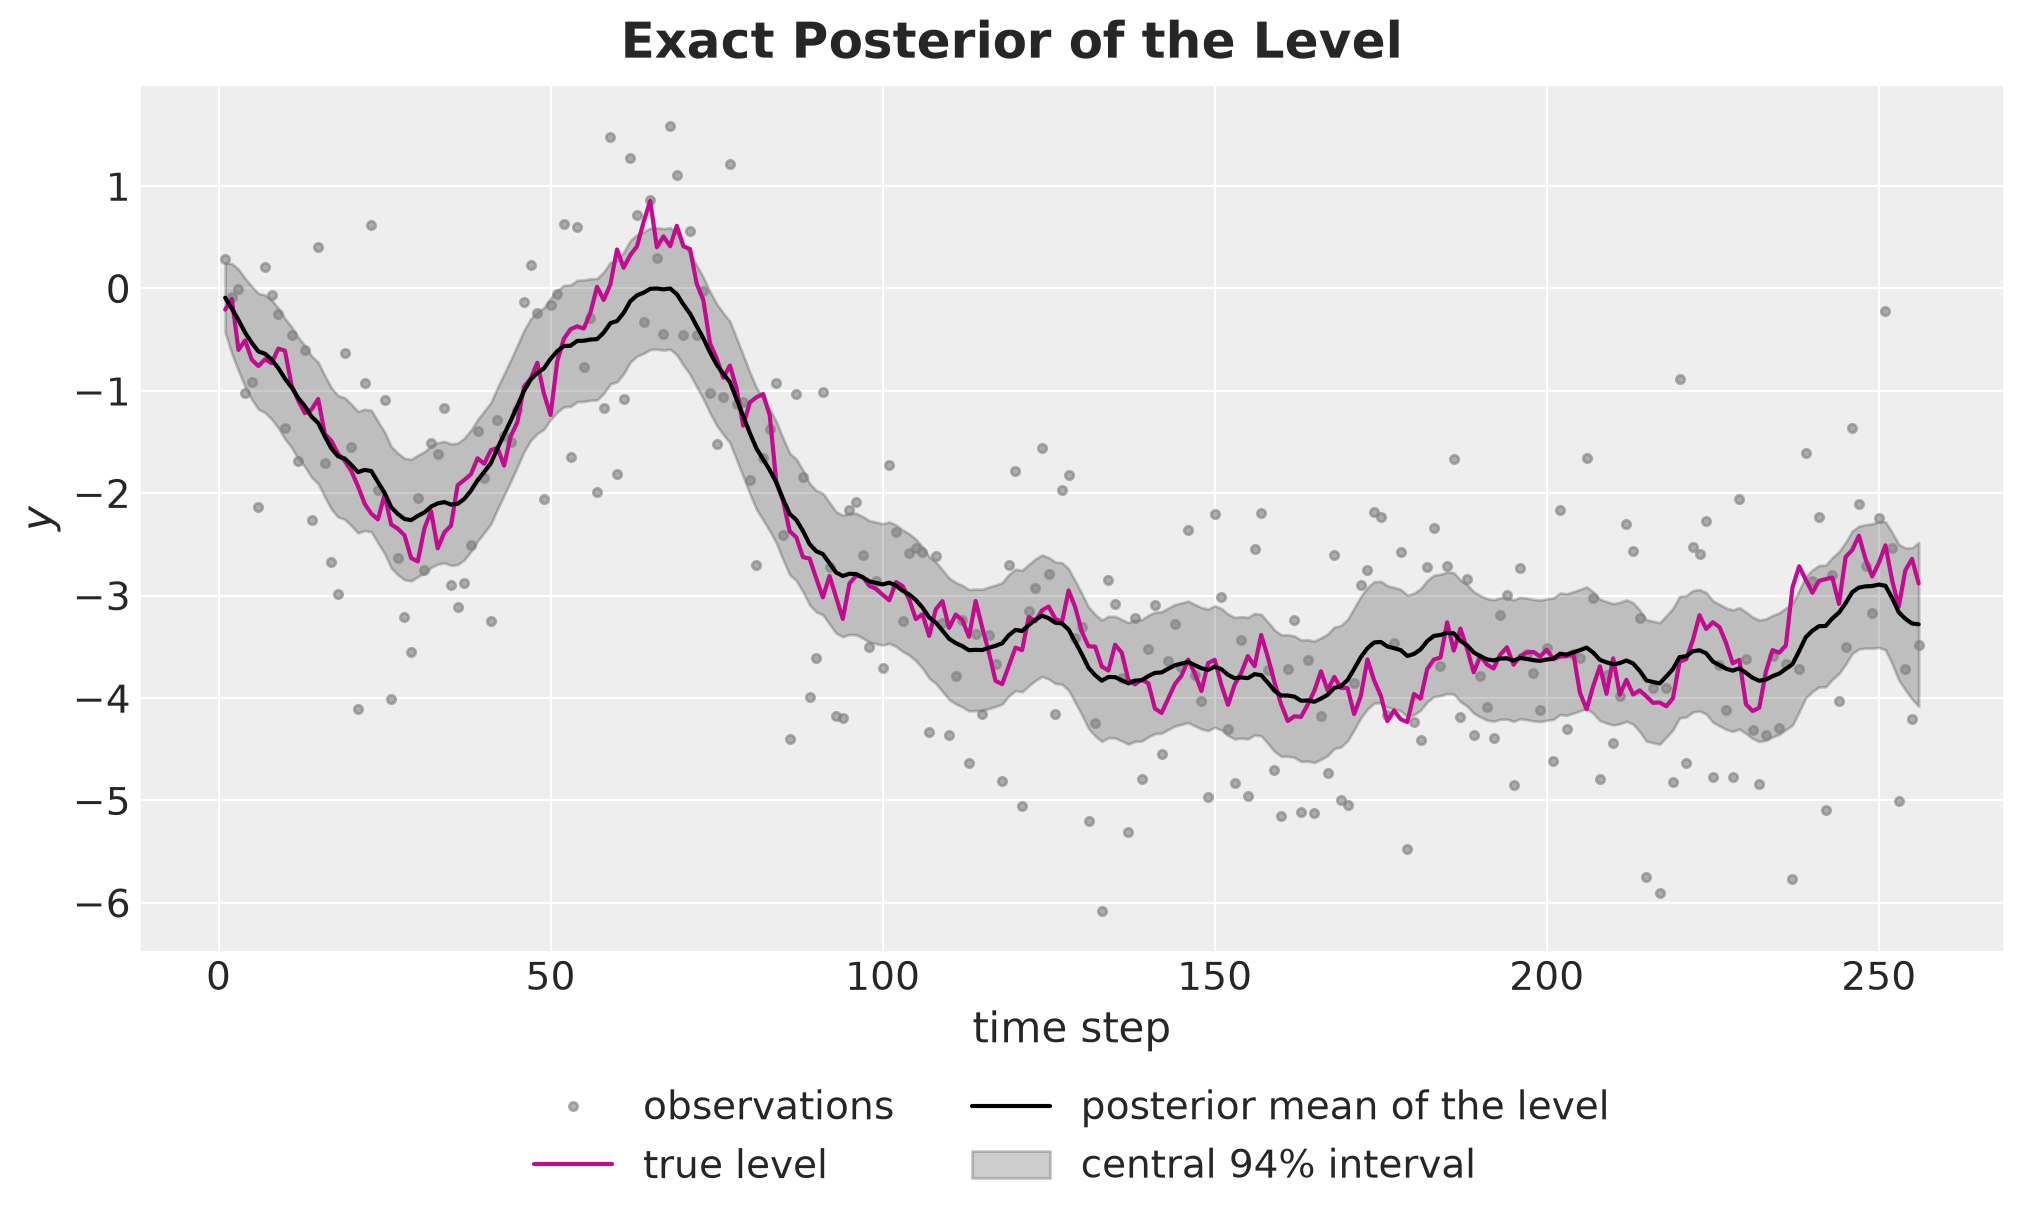

In [5]:
# Number of standard deviations of a central interval with probability HDI_PROB.
z_score = dist.Normal(0.0, 1.0).icdf(0.5 + HDI_PROB / 2)

fig, ax = plt.subplots()
ax.plot(
    toy_time, toy_y, "o", color="gray", markersize=3, alpha=0.6, label="observations"
)
ax.plot(toy_time, toy_level, color="C3", label="true level")
ax.plot(toy_time, level_mean, color="black", label="posterior mean of the level")
ax.fill_between(
    toy_time,
    level_mean - z_score * level_sd,
    level_mean + z_score * level_sd,
    color="black",
    alpha=0.2,
    label="central $94\\%$ interval",
)
ax.set(xlabel="time step", ylabel="$y$")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
fig.suptitle("Exact Posterior of the Level", fontsize=18, fontweight="bold");

The figure shows the data, the level that we want to recover, and its exact posterior.

- **The posterior tracks the level.** The posterior mean follows the true level, and the true level stays inside the interval most of the time.
- **The interval has a constant width.** Away from the two ends, the data constrain the level with the same precision at every time step. We will see below that a mean-field guide on the increments cannot reproduce this property.

## Posterior Geometry

What does the posterior of the increments look like? The contours of a Gaussian density are ellipsoids, and the eigenvectors of $\Lambda$ are their axes.

A large eigenvalue is a *stiff* direction, where the data leave little freedom. A small eigenvalue is a *loose* direction.

For this model we know the axes in closed form. The inverse of $L^\top L$ is a second-difference matrix: it is tridiagonal with $2$ on the diagonal (and $1$ in the first entry) and $-1$ next to it. The eigenvectors of such a matrix are cosines.

For $k = 0, \ldots, T - 1$ the eigenvectors $v_k$ and the eigenvalues $\lambda_k$ of $L^\top L$ are

$$
v_k(t) \propto \cos\left(\frac{(2k + 1)(2t - 1)\pi}{2(2T + 1)}\right), \qquad \lambda_k = \frac{1}{4 \sin^2\left(\frac{(2k + 1)\pi}{2(2T + 1)}\right)} .
$$

The matrix $\Lambda$ has the same eigenvectors, with eigenvalues $\sigma_\delta^{-2} + \sigma^{-2} \lambda_k$. The index $k$ is a frequency: $v_0$ is the smoothest direction and $v_{T-1}$ the most oscillating one.

Let $\rho = \sigma_\delta / \sigma$ be the ratio of the two scales. The posterior variance along $v_k$, relative to the prior variance $\sigma_\delta^2$, is

$$
\frac{1}{1 + \rho^2 \lambda_k} .
$$

This ratio is the shrinkage of direction $k$. A value close to $1$ means that the data say nothing about that direction, and a value close to $0$ means that the data determine it.

Let's check the closed form against a numerical eigendecomposition.

In [6]:
frequency = np.arange(T_TOY)

cumsum_eigenvalues = 1 / (
    4 * np.sin((2 * frequency + 1) * np.pi / (2 * (2 * T_TOY + 1))) ** 2
)
precision_eigenvalues = 1 / DRIFT_SCALE**2 + cumsum_eigenvalues / SIGMA**2

eigenvectors = np.cos(
    np.outer(2 * toy_time - 1, 2 * frequency + 1) * np.pi / (2 * (2 * T_TOY + 1))
)
eigenvectors /= np.linalg.norm(eigenvectors, axis=0)

np.testing.assert_allclose(
    np.sort(precision_eigenvalues), np.linalg.eigvalsh(precision), rtol=1e-8
)
np.testing.assert_allclose(
    precision @ eigenvectors, eigenvectors * precision_eigenvalues, rtol=1e-6, atol=1e-6
)

The closed form agrees with the numerical eigendecomposition.

Now we plot the four stiffest directions (left) and the shrinkage of all $256$ directions (right).

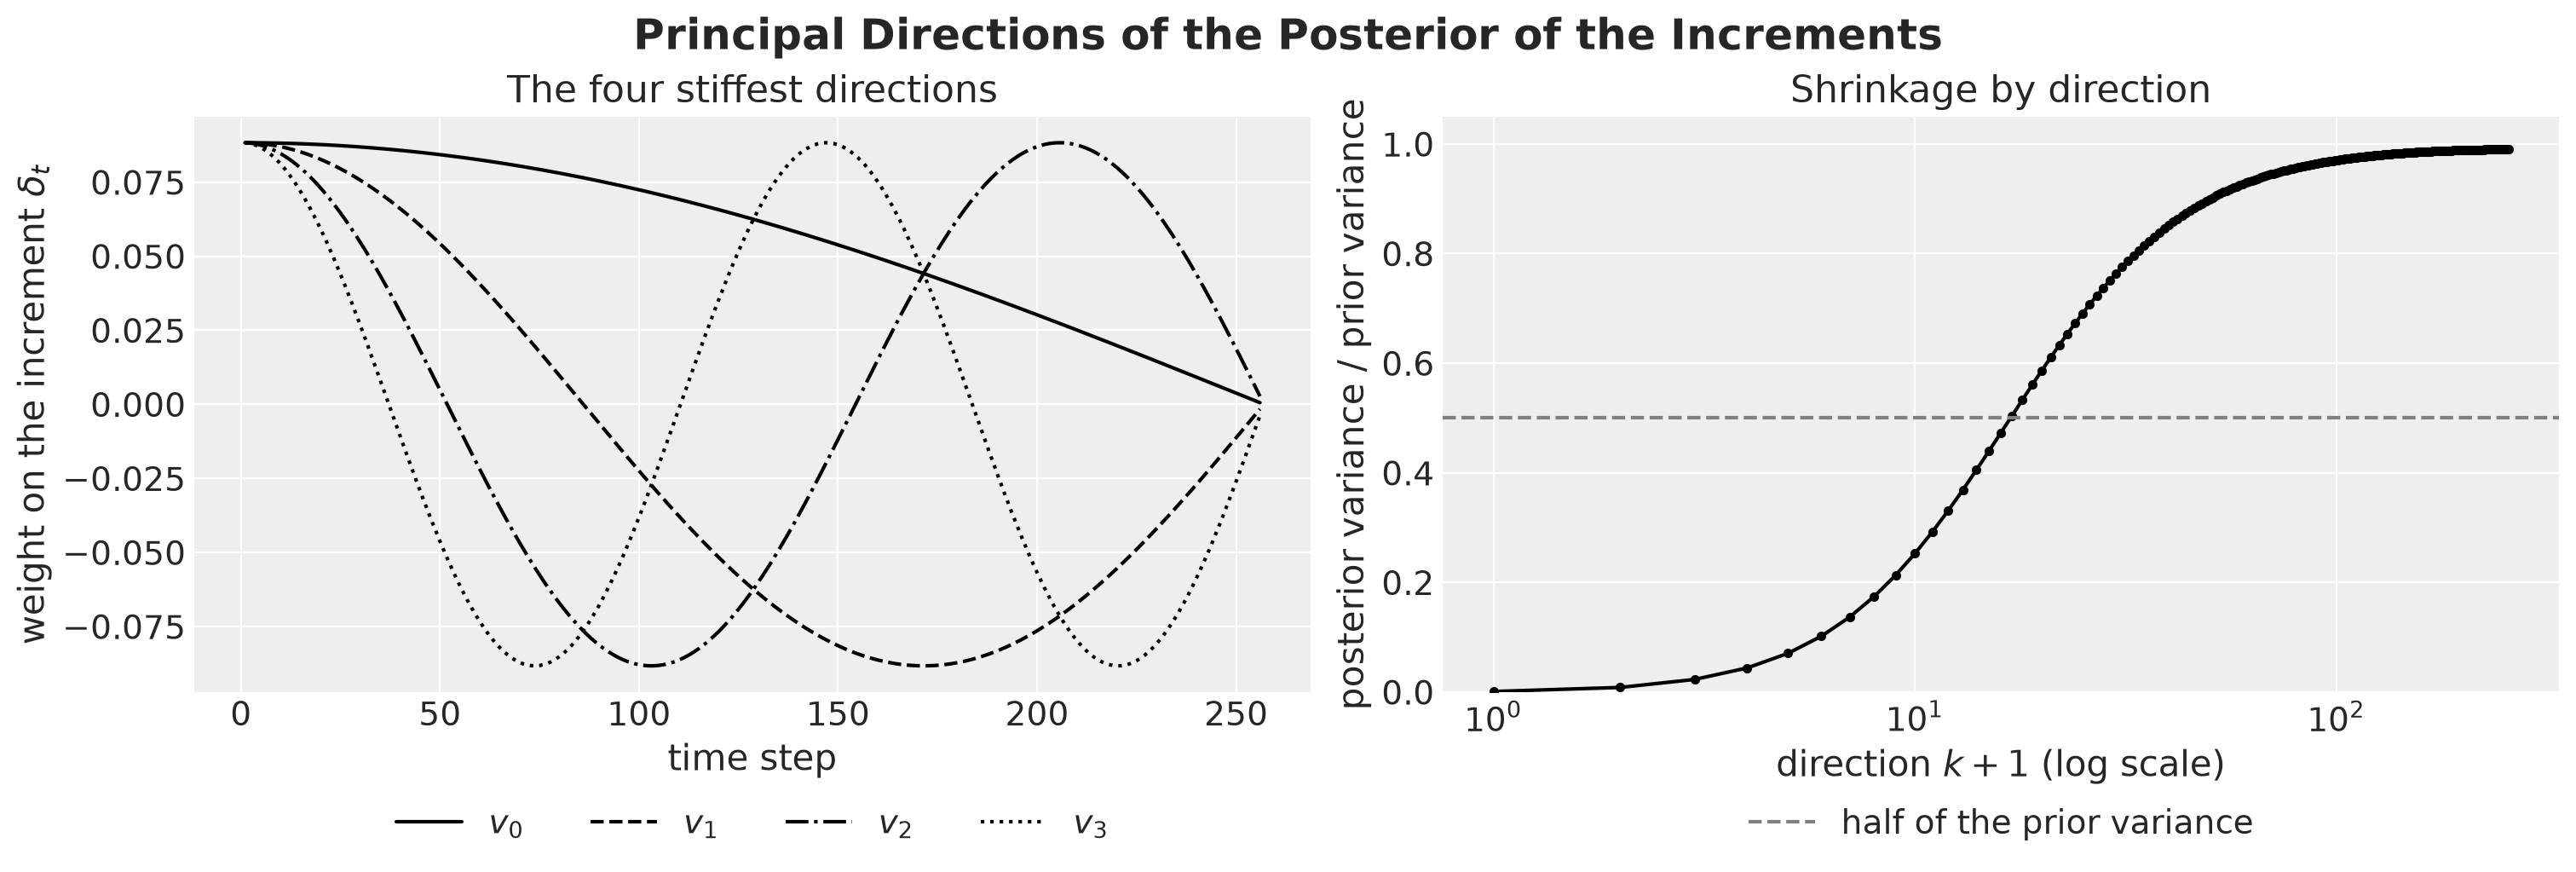

In [7]:
shrinkage = 1 / (DRIFT_SCALE**2 * precision_eigenvalues)
direction_styles = ["-", "--", "-.", ":"]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
for i, linestyle in enumerate(direction_styles):
    axes[0].plot(
        toy_time,
        eigenvectors[:, i],
        color="black",
        linestyle=linestyle,
        label=f"$v_{i}$",
    )
axes[0].set(
    xlabel="time step",
    ylabel="weight on the increment $\\delta_t$",
    title="The four stiffest directions",
)
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4)
axes[1].plot(frequency + 1, shrinkage, "o-", color="black", markersize=3)
axes[1].axhline(0.5, color="gray", linestyle="--", label="half of the prior variance")
axes[1].set(
    xscale="log",
    xlabel="direction $k + 1$ (log scale)",
    ylabel="posterior variance / prior variance",
    title="Shrinkage by direction",
    ylim=(0, 1.05),
)
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.15))
fig.suptitle(
    "Principal Directions of the Posterior of the Increments",
    fontsize=18,
    fontweight="bold",
);

The left panel shows the weights of the four stiffest directions on the increments. The right panel shows how much of the prior variance is left along each direction.

- **The stiff directions are smooth.** The stiffest direction $v_0$ moves all the increments in the same direction. This shifts the level at every later time step, and every observation constrains it.
- **Most directions stay at the prior.** Only $16$ of the $256$ directions lose more than half of their prior variance. The oscillating directions barely move the level, because consecutive increments cancel out, and the data do not constrain them.
- **The ellipsoid is very elongated.** The ratio between the largest and the smallest eigenvalue of $\Lambda$, its condition number, is about $1057$.

The condition number of $\Lambda$ is approximately

$$
\frac{1 + \rho^2 (2T + 1)^2 / \pi^2}{1 + \rho^2 / 4} .
$$

For a fixed $\rho$ it grows with the *square* of the length of the series, and for a fixed $T$ it grows with $\rho^2$.

Observe that none of the stiff directions is a coordinate axis. Each one mixes all the increments. This is the cause of the problem: mean-field guides and diagonal mass matrices work coordinate by coordinate.

## Orthonormal Time Transforms

The idea of the reparameterization is to rotate the coordinates such that the axes of the ellipsoid become coordinate axes, at least approximately.

Let $U$ be a $T \times T$ orthonormal matrix, that is $U U^\top = I$, and define the new latent variable $z = U \delta$. We sample $z$ and we recover the increments as $\delta = U^\top z$. Three properties make this change of variables convenient:

- **The density does not change.** The density of $z$ is the density of $\delta$ evaluated at $U^\top z$, times $|\det U^\top| = 1$. There is no Jacobian term, and the model is the same model.
- **White noise stays white noise.** If the increments $\delta_t$ are independent $\text{Normal}(0, \sigma_\delta)$ variables, then the coefficients $z_k$ are independent $\text{Normal}(0, \sigma_\delta)$ variables too. The prior keeps its simple form.
- **The precision is rotated.** The posterior precision of $z$ is $\Lambda_U = U \Lambda U^\top$.

A rotation does not change methods that treat all directions alike. A full-rank Gaussian guide reaches the same ELBO in every orthonormal basis, and HMC with an identity mass matrix behaves the same in every orthonormal basis. The rotation matters for the methods that work coordinate by coordinate: a mean-field guide and a diagonal mass matrix.

The best choice of $U$ is the matrix of eigenvectors of $\Lambda$, which makes $\Lambda_U$ diagonal. For the local level model these eigenvectors do not depend on the scales, and we know them in closed form. In a real model we do not know them: the likelihood is not Gaussian, and other parameters, such as an intercept or a regression, couple with the path.

We do know that the stiff directions are smooth and that the loose ones oscillate. Therefore we use a fixed basis that sorts the coordinates from coarse to fine. Pyro offers two.

### Discrete Cosine Transform

The rows of the orthonormal DCT (type II) are cosines of increasing frequency. For $k = 0, \ldots, T - 1$ and $t = 1, \ldots, T$,

$$
C_{k t} = c_k \cos\left(\frac{\pi k (2t - 1)}{2T}\right), \qquad c_0 = \sqrt{1 / T}, \qquad c_k = \sqrt{2 / T} \ \text{ for } k \ge 1 .
$$

The first coefficient $z_0$ is the average increment times $\sqrt{T}$. The next ones are slow trends, and the last ones are step-to-step oscillations. The transform costs $O(T \log T)$ operations with a fast Fourier transform.

### Haar Transform

The Haar transform compares the averages of neighboring blocks at different scales. For $T = 2^n$ the first row is constant, $H_{0 t} = \sqrt{1 / T}$.

For each scale $j = 0, \ldots, n - 1$ we split the time axis into $2^j$ blocks of length $T / 2^j$, and each block gives one row. That row is $\sqrt{2^j / T}$ on the first half of the block, $-\sqrt{2^j / T}$ on the second half, and $0$ outside the block.

In other words, a Haar coefficient is proportional to the difference between the averages of the two halves of a block. The rows are localized in time, which the cosines are not. The transform costs $O(T)$ operations.

**Remark (other lengths and constrained sites):** When $T$ is not a power of two, NumPyro uses a block-structured version of the same idea, and the first row is no longer a global average. For $T = 417$, for example, it is the average of the first $256$ values. For a constrained latent variable, NumPyro applies the rotation in the unconstrained space.

From now on we label the three coordinate systems `none` (the original increments), `haar` and `dct`. All the figures use these labels and the same three colors.

Let's build the two matrices from the NumPyro transforms. We apply each transform to the columns of the identity matrix, and we check that the result is orthonormal and that the DCT matches the formula.

In [8]:
def transform_matrix(transform: Transform, t_obs: int) -> np.ndarray:
    "Matrix `u` of a linear transform, such that `u @ x == transform(x)`."
    return np.asarray(jax.vmap(transform)(jnp.eye(t_obs)), dtype=float).T


rotations = {
    "none": np.eye(T_TOY),
    "haar": transform_matrix(HaarTransform(dim=-1), T_TOY),
    "dct": transform_matrix(DiscreteCosineTransform(dim=-1), T_TOY),
}

for rotation in rotations.values():
    np.testing.assert_allclose(rotation @ rotation.T, np.eye(T_TOY), atol=1e-5)

dct_scale = np.where(frequency == 0, np.sqrt(1 / T_TOY), np.sqrt(2 / T_TOY))
dct_formula = dct_scale[:, None] * np.cos(
    np.pi * np.outer(frequency, 2 * toy_time - 1) / (2 * T_TOY)
)
np.testing.assert_allclose(rotations["dct"], dct_formula, atol=1e-5)

Both matrices are orthonormal. We plot the first four rows of each basis next to the four stiffest directions of the posterior. Each vector has its own horizontal strip, and each strip is scaled to the same height.

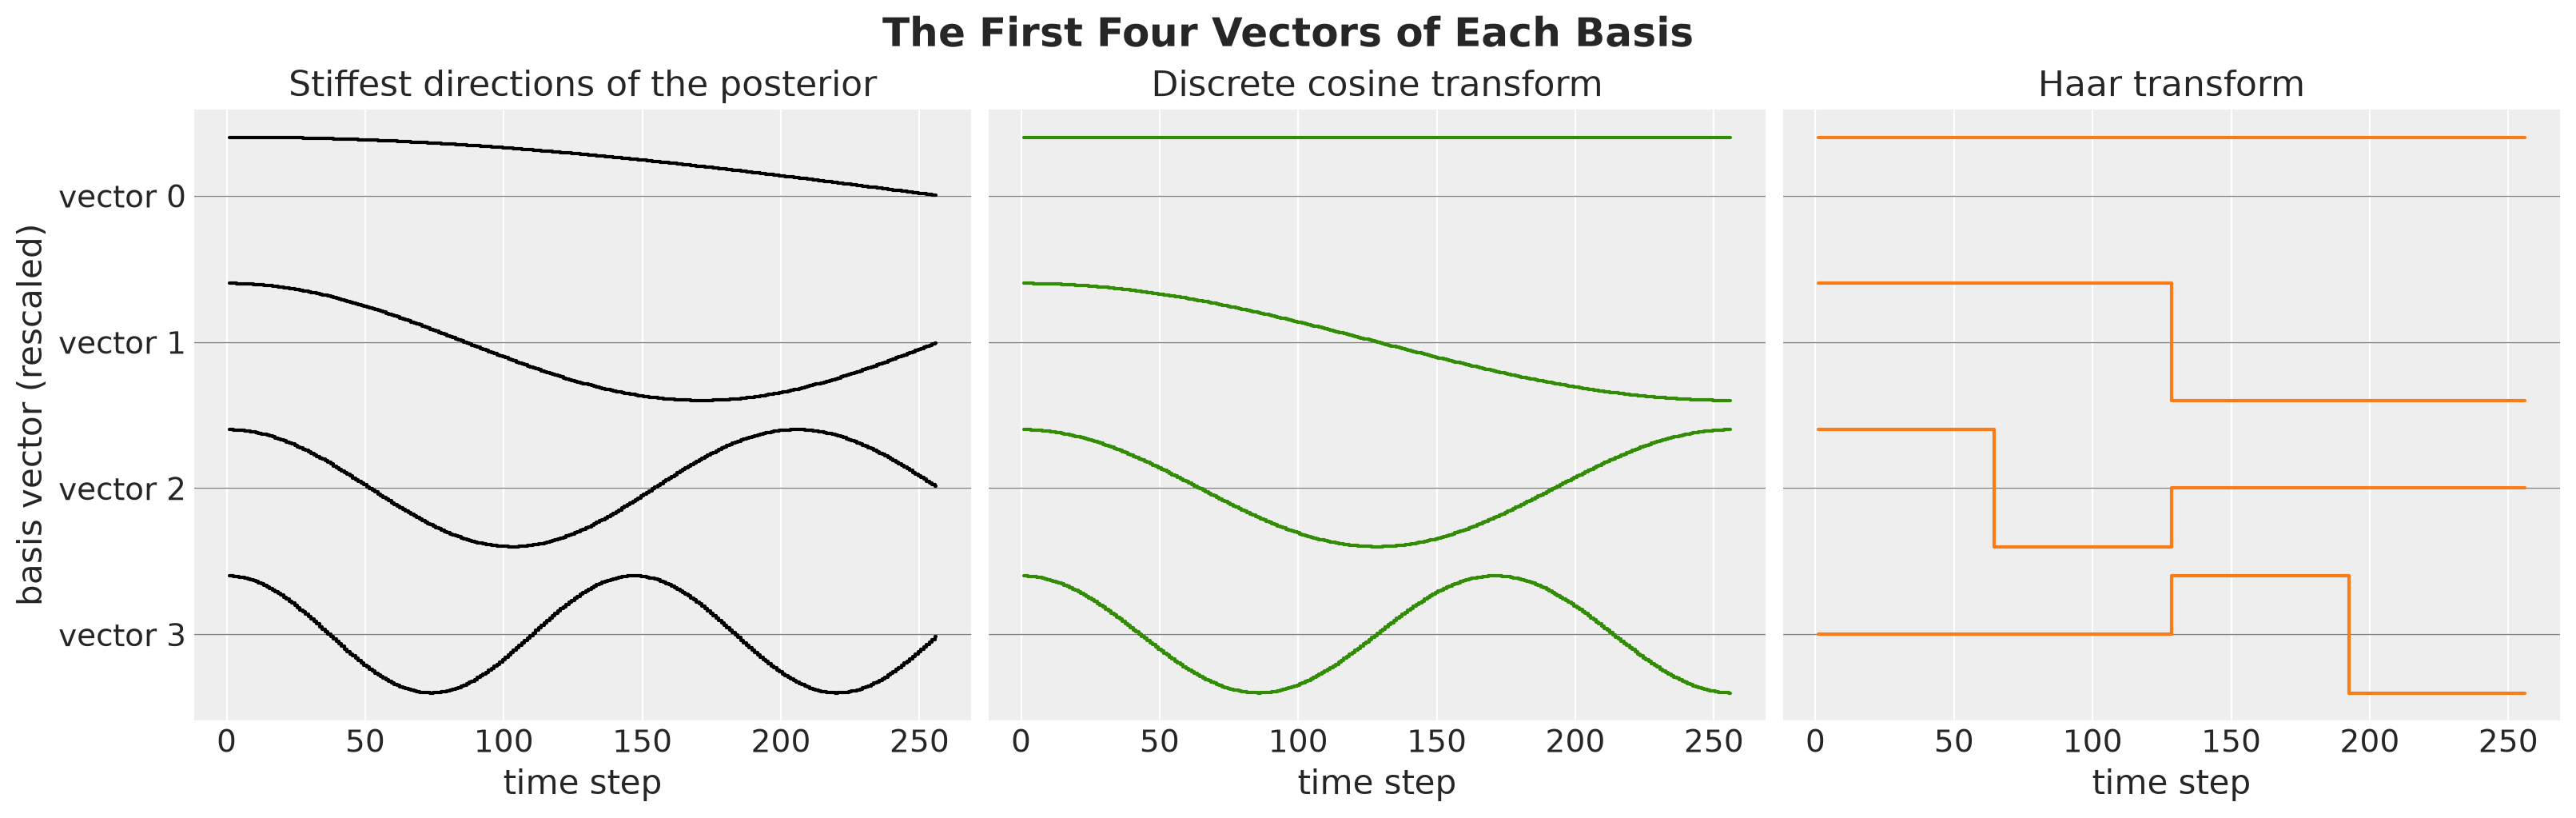

In [9]:
panels = {
    "Stiffest directions of the posterior": (eigenvectors.T, "black"),
    "Discrete cosine transform": (rotations["dct"], COLORS["dct"]),
    "Haar transform": (rotations["haar"], COLORS["haar"]),
}

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 5), sharey=True)
for ax, (title, (rows, color)) in zip(axes, panels.items(), strict=True):
    for i in range(4):
        strip = 0.4 * rows[i] / np.abs(rows[i]).max() - i
        ax.axhline(-i, color="gray", linewidth=0.5)
        ax.plot(toy_time, strip, color=color, drawstyle="steps-mid")
    ax.set(xlabel="time step", title=title, yticks=[0, -1, -2, -3])
    ax.set_yticklabels([f"vector {i}" for i in range(4)])
axes[0].set(ylabel="basis vector (rescaled)")
fig.suptitle("The First Four Vectors of Each Basis", fontsize=18, fontweight="bold");

Each strip is one basis vector as a function of time, and the thin gray line is zero. The left panel is the target, and the other two are the fixed bases.

- **The DCT rows resemble the true axes.** They are cosines of increasing frequency, like the eigenvectors $v_k$. They are not the same: the eigenvectors have half-integer frequencies and go to zero at the right end, while the DCT rows have integer frequencies.
- **The Haar rows are a blocky version of the same idea.** Vector $0$ is the average, vector $1$ compares the two halves, and vectors $2$ and $3$ compare the quarters inside each half.
- **Both bases sort the coordinates from coarse to fine.** The first coordinates are the smooth, stiff directions and the last ones are the oscillating, loose directions.

**Remark (exact bases):** The eigenvectors $v_k$ are the rows of another member of the family, the DCT of type VIII. The DCT of type II is exact for a different parameterization. If we sample the levels $\ell_t$ instead of the increments and give the first level a flat prior, the posterior precision is $\sigma^{-2} I$ plus $\sigma_\delta^{-2}$ times a second-difference matrix with free ends. The DCT of type II diagonalizes this matrix ([Strang, 1999](https://epubs.siam.org/doi/10.1137/S0036144598336745)). For the increments the match is approximate, and the next two sections measure how good it is.

## Mean-Field Gap

Now we quantify what a mean-field guide loses in each basis. A mean-field Gaussian guide for $z$ is a product of independent Normal distributions,

$$
q(z) = \prod_{i = 1}^{T} \text{Normal}(z_i \mid m_i, s_i),
$$

with one location $m_i$ and one scale $s_i$ per coordinate. This is the family that `AutoNormal` fits. SVI maximizes the evidence lower bound (ELBO), which is the log evidence minus the Kullback-Leibler divergence of the guide relative to the posterior:

$$
\text{ELBO}(q) = \log \text{P}(y) - \text{KL}\left(q \,\|\, \text{P}(z \mid y)\right) .
$$

The log evidence does not depend on the basis. Therefore the smallest divergence that a mean-field guide can reach decides its best ELBO. We call that divergence the mean-field gap, and we measure it in nats, the unit of the natural logarithm.

For a Gaussian posterior with precision $\Lambda_U$ we can minimize in closed form. The optimal locations are the entries of the posterior mean and the optimal scales are $s_i^2 = 1 / (\Lambda_U)_{ii}$. Let $\tilde{\Lambda}_U$ be the precision $\Lambda_U$ rescaled to have ones on the diagonal, which we call the normalized precision. The gap is

$$
\text{gap}(U) = \frac{1}{2} \left( \sum_{i = 1}^{T} \log (\Lambda_U)_{ii} - \log \det \Lambda \right) = - \frac{1}{2} \log \det \tilde{\Lambda}_U .
$$

We make two remarks:

- **The gap is zero only for a diagonal precision.** This is Hadamard's inequality: the determinant of a positive definite matrix is at most the product of its diagonal entries, with equality only for a diagonal matrix.
- **Only the first term depends on the basis.** The determinant of $\Lambda$ is invariant under rotations. A good basis is one where the product of the diagonal entries of $\Lambda_U$ is small, that is, where the off-diagonal entries of the normalized precision are close to zero.

Let's compute the gap for the three coordinate systems. We plot the normalized precision matrices (top row) and a zoom on their first $16$ coordinates (bottom row). White is zero, which means no coupling, and the diagonal is $1$ by construction.

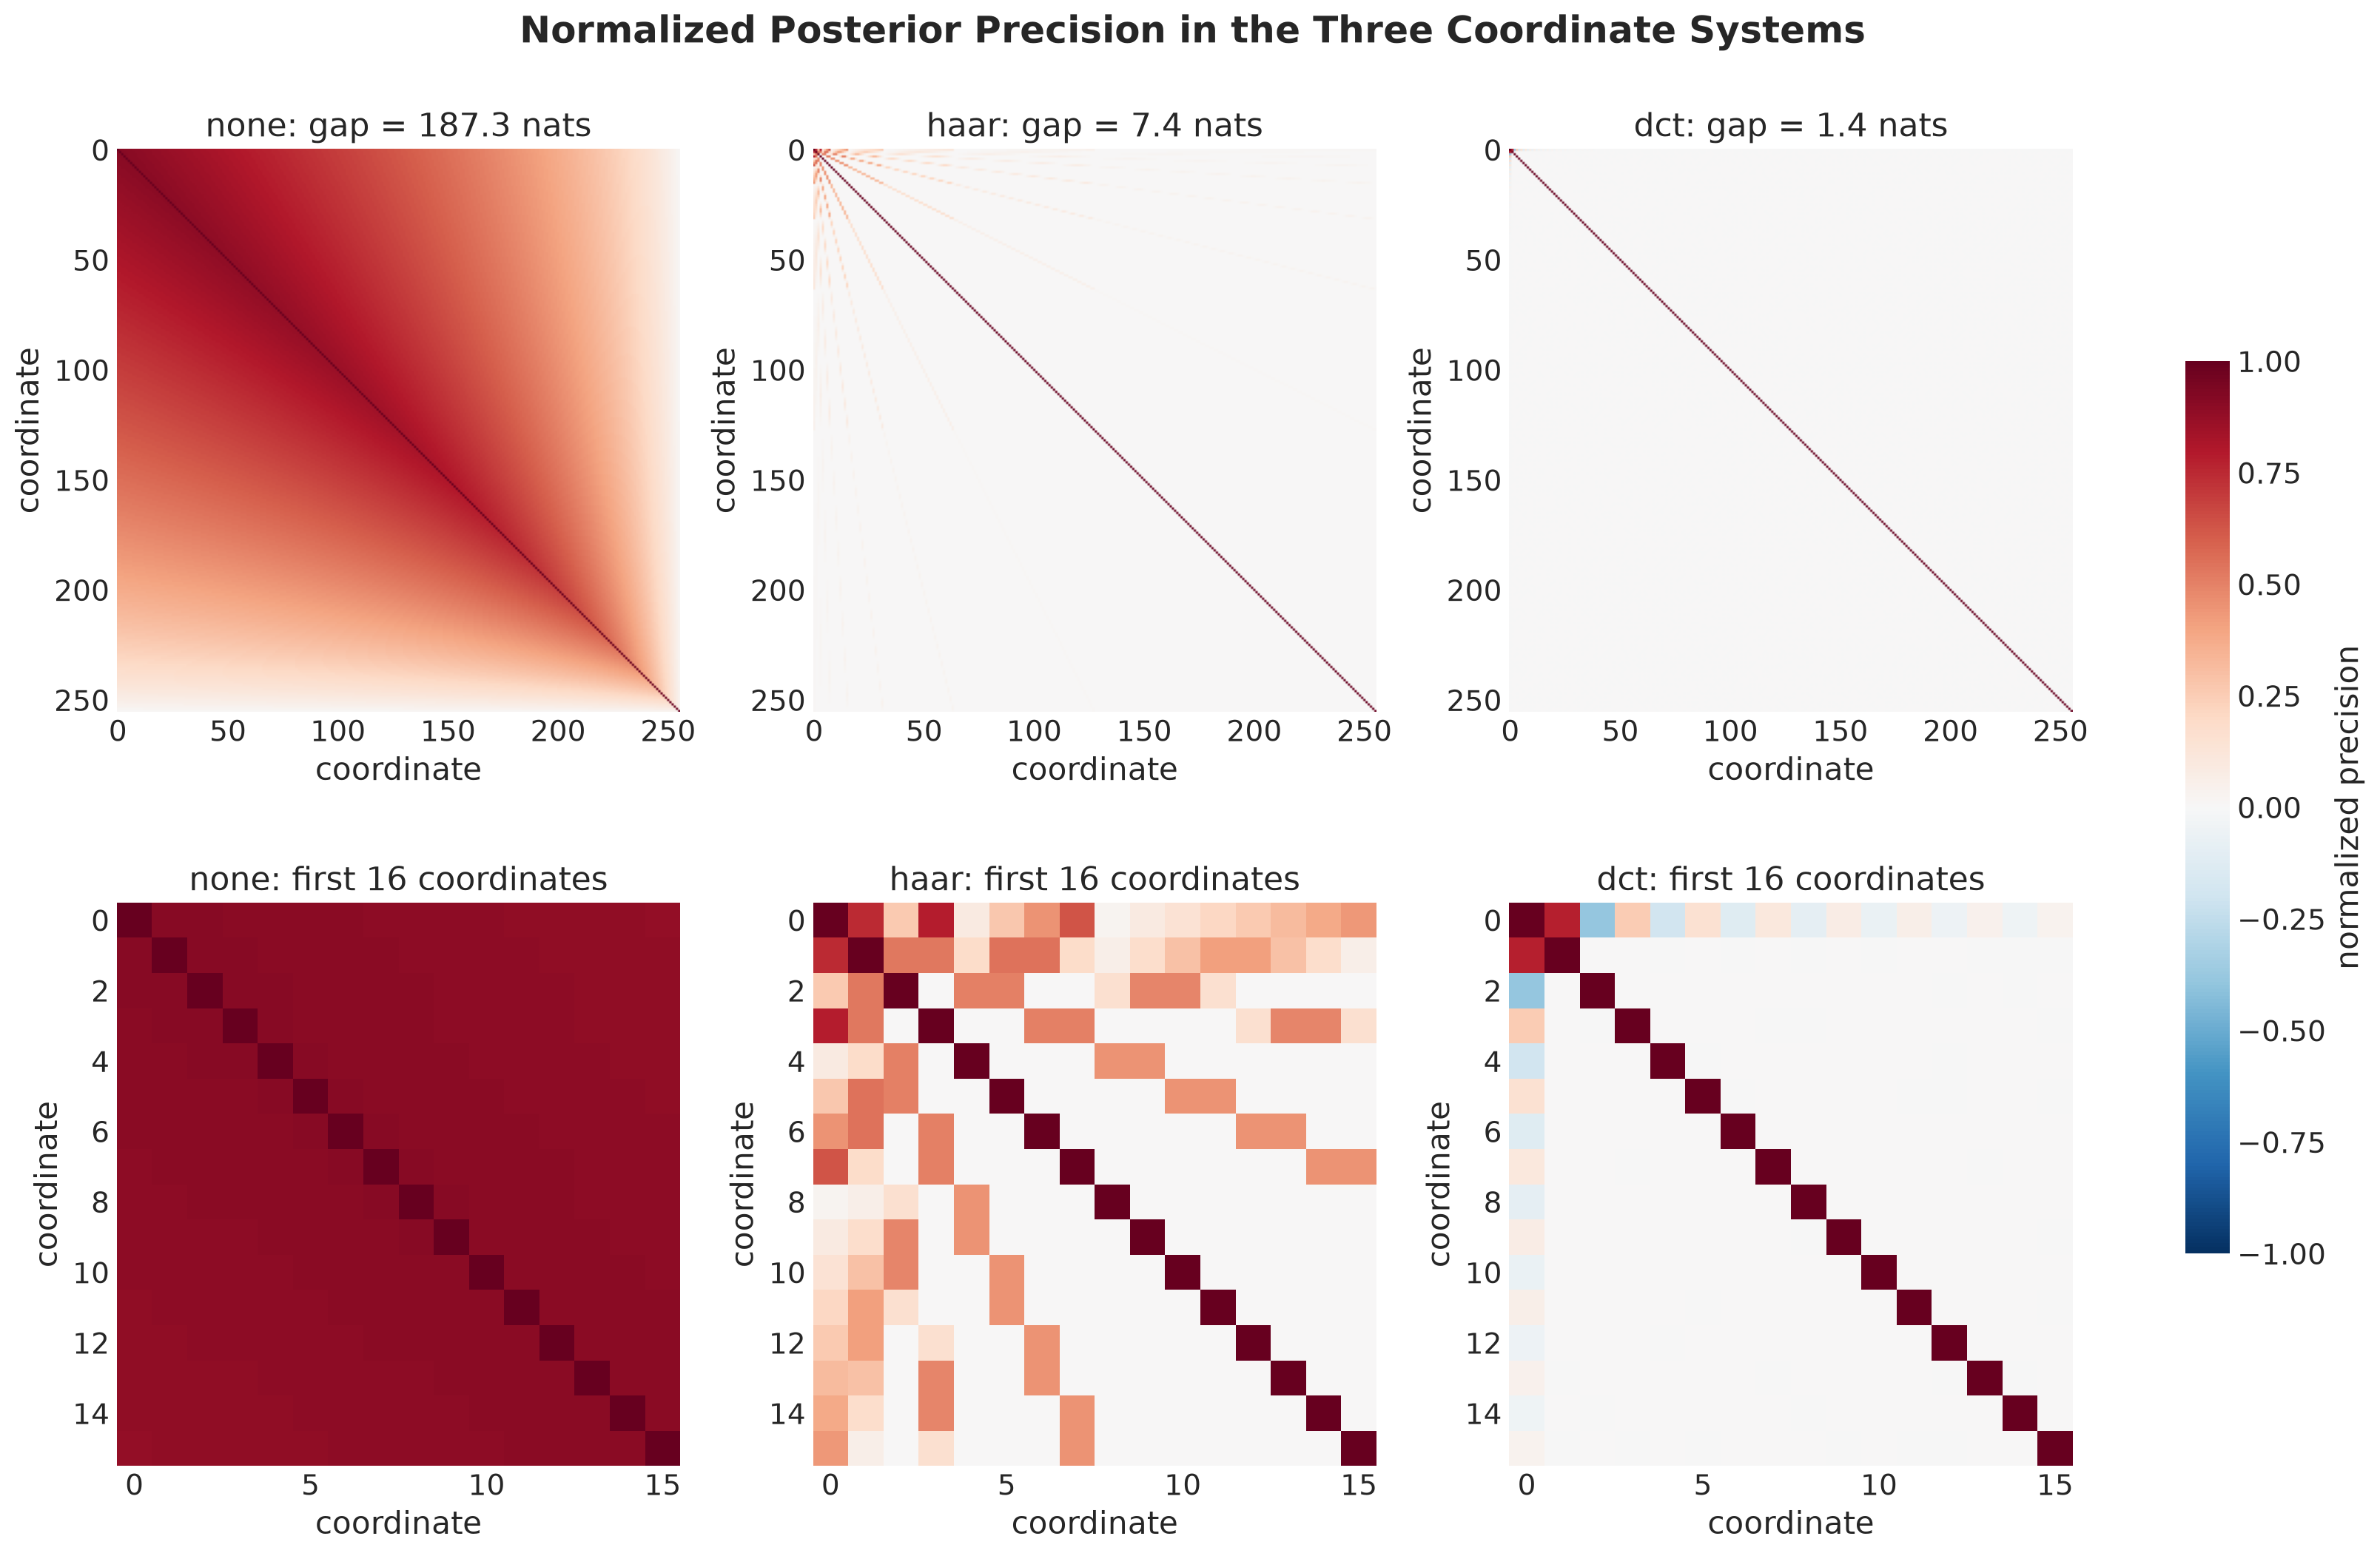

In [10]:
def normalize(matrix: np.ndarray) -> np.ndarray:
    "Rescale a positive definite matrix to have ones on the diagonal."
    scale = np.sqrt(np.diag(matrix))
    return matrix / np.outer(scale, scale)


def mean_field_gap(precision: np.ndarray, rotation: np.ndarray) -> float:
    "KL divergence of the best mean-field Gaussian relative to the posterior, in nats."
    rotated = rotation @ precision @ rotation.T
    return 0.5 * (np.log(np.diag(rotated)).sum() - np.linalg.slogdet(precision)[1])


gaps = {name: mean_field_gap(precision, u) for name, u in rotations.items()}

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10.5))
for column, (name, u) in enumerate(rotations.items()):
    normalized = normalize(u @ precision @ u.T)
    for row, size in enumerate([T_TOY, 16]):
        ax = axes[row, column]
        image = ax.imshow(normalized[:size, :size], cmap="RdBu_r", vmin=-1, vmax=1)
        ax.grid(visible=False)
        ax.set(xlabel="coordinate", ylabel="coordinate")
    axes[0, column].set(title=f"{name}: gap = {gaps[name]:.1f} nats")
    axes[1, column].set(title=f"{name}: first 16 coordinates")
fig.colorbar(image, ax=axes, shrink=0.6, label="normalized precision")
fig.suptitle(
    "Normalized Posterior Precision in the Three Coordinate Systems",
    fontsize=18,
    fontweight="bold",
);

Each column is the same posterior in one coordinate system, and the title gives the mean-field gap.

- **In the original coordinates every pair is coupled.** The matrix is dense, and the gap is $187.3$ nats. A mean-field guide is very far from this posterior.
- **The Haar basis leaves few entries.** Only about $1\%$ of the off-diagonal entries are larger than $0.05$, and the gap drops to $7.4$ nats.
- **The DCT leaves even fewer.** The gap is $1.4$ nats, which is less than $1\%$ of the original gap.
- **The entries that remain are large.** The zoom shows entries up to about $0.8$ among the coarsest coefficients. For the DCT they are all in the first row: the coefficient $z_0$, the average increment, is still coupled to the others. A small gap is a global statement. It does not say that every coordinate is well approximated, and we will see the consequence for the level.

Next, we check that this result is not specific to $\rho = 0.2$. We compute the gap on a grid of scale ratios.

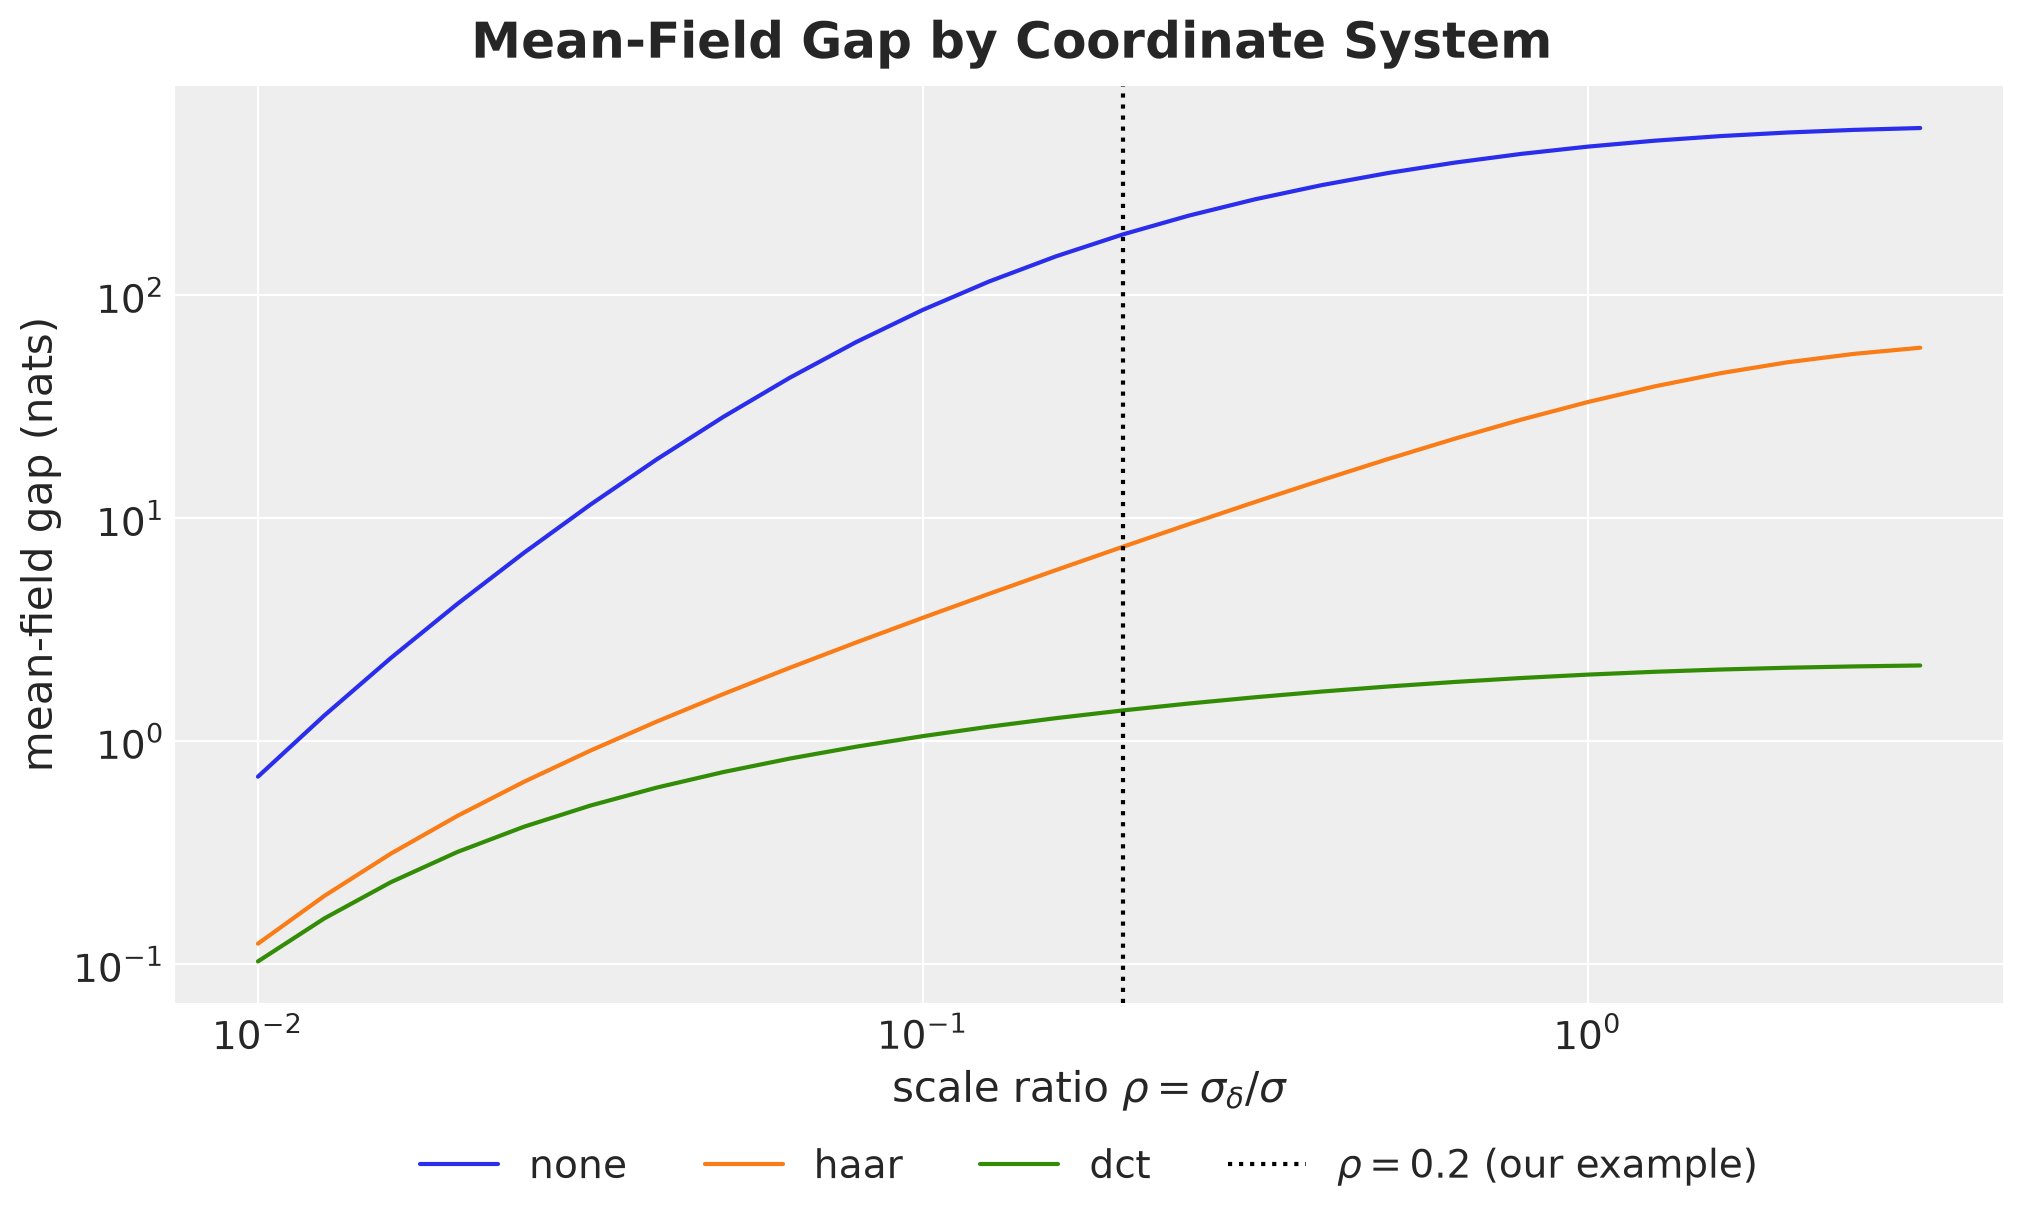

In [11]:
ratio_grid = np.logspace(-2, 0.5, 26)
gap_grid = {
    name: np.array(
        [mean_field_gap(posterior_precision(T_TOY, rho, 1.0), u) for rho in ratio_grid]
    )
    for name, u in rotations.items()
}

fig, ax = plt.subplots()
for name, values in gap_grid.items():
    ax.plot(ratio_grid, values, color=COLORS[name], label=name)
ax.axvline(
    DRIFT_SCALE / SIGMA,
    color="black",
    linestyle=":",
    label="$\\rho = 0.2$ (our example)",
)
ax.set(
    xscale="log",
    yscale="log",
    xlabel="scale ratio $\\rho = \\sigma_\\delta / \\sigma$",
    ylabel="mean-field gap (nats)",
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4)
fig.suptitle("Mean-Field Gap by Coordinate System", fontsize=18, fontweight="bold");

The figure shows the gap of the best mean-field guide as a function of the scale ratio, on logarithmic axes.

- **The ranking is the same everywhere.** The original coordinates are the worst for every $\rho$, and both rotations help.
- **The gain grows with the scale ratio.** For a very small $\rho$ the posterior is close to the prior and every coordinate system is fine. For $\rho \ge 0.1$ the original gap is in the tens or hundreds of nats, while the DCT gap stays below $3$ nats.
- **The DCT has a smaller gap than Haar for this model.** The true axes are cosines, and the DCT rows are cosines too.

### Uncertainty of the Level

What does the gap mean for the quantity we forecast from, the level? The optimal mean-field guide has covariance $U^\top \text{diag}(1 / (\Lambda_U)_{ii})\, U$ for the increments. We push it through the cumulative sum and compare the standard deviation of the level with the exact one.

We can anticipate two features of the result:

- **In the original coordinates the variance accumulates.** The guide treats the increments as independent, with variances $1 / \Lambda_{ii} = 1 / (\sigma_\delta^{-2} + (T + 1 - i)\, \sigma^{-2})$. The variance of the level is their sum, which is approximately $\sigma^2 \log\left(a / (a - t)\right)$ with $a = T + 1/2 + \rho^{-2}$. It keeps growing with $t$, and faster toward the end.
- **With a constant first row the last level depends on one coefficient.** For the DCT, and for the Haar basis when $T$ is a power of two, every row except the first sums to zero. The last level is therefore $\ell_T = \sqrt{T}\, z_0$. The guide gives $z_0$ the variance $1 / (\Lambda_U)_{00}$, and the standard deviation of $\ell_T$ is approximately $\sigma \sqrt{3 / T}$, which is too small.

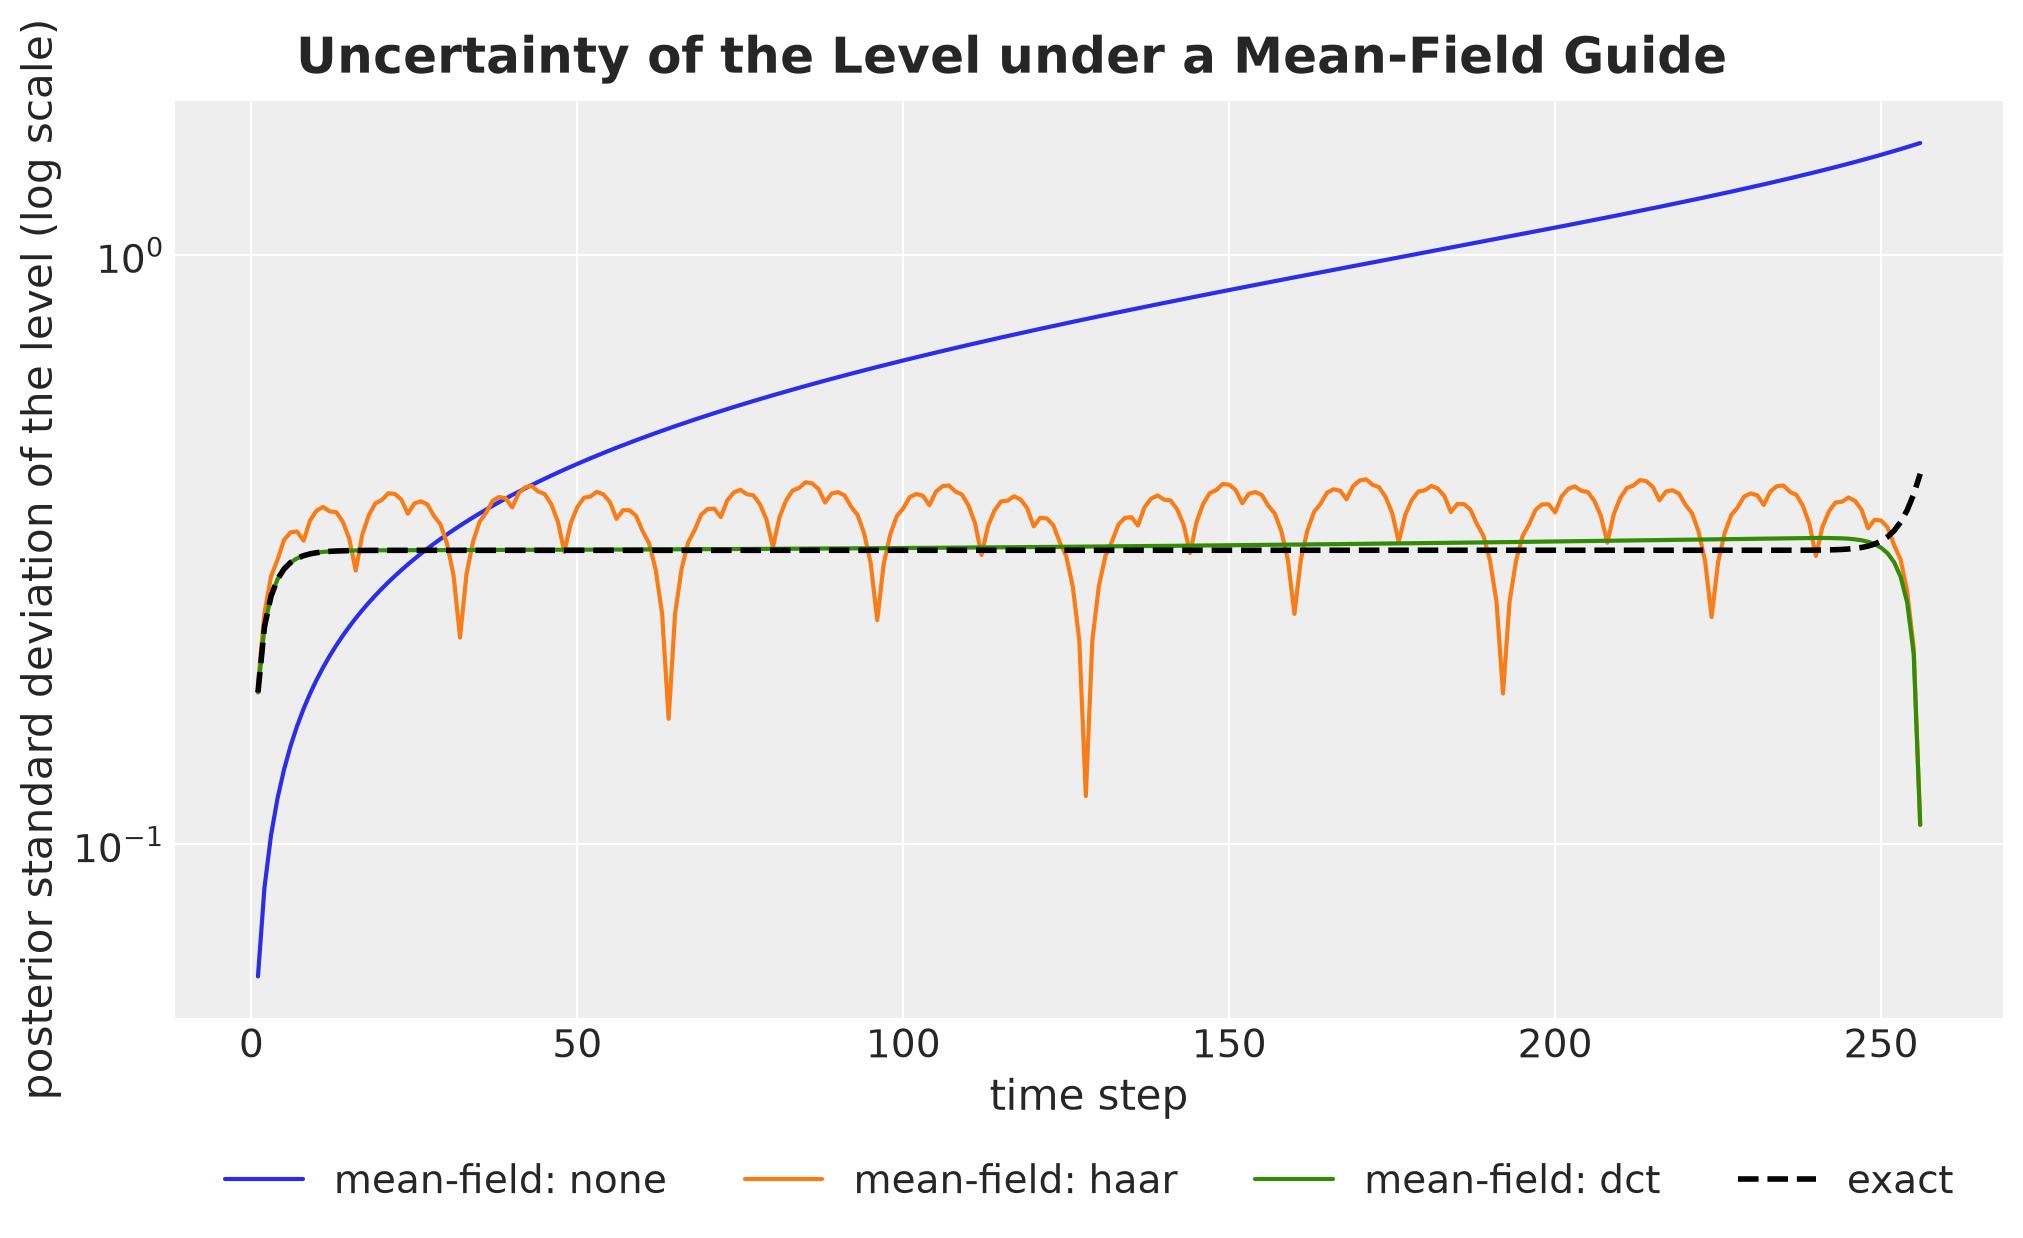

In [12]:
def mean_field_covariance(precision: np.ndarray, rotation: np.ndarray) -> np.ndarray:
    "Covariance of the increments under the best mean-field Gaussian."
    rotated = rotation @ precision @ rotation.T
    return rotation.T @ np.diag(1 / np.diag(rotated)) @ rotation


mean_field_level_sd = {
    name: np.sqrt(
        np.diag(cumsum_matrix @ mean_field_covariance(precision, u) @ cumsum_matrix.T)
    )
    for name, u in rotations.items()
}

# The two approximations of the text.
offset = T_TOY + 0.5 + (SIGMA / DRIFT_SCALE) ** 2
log_formula = SIGMA * np.sqrt(np.log(offset / (offset - toy_time)))
np.testing.assert_allclose(mean_field_level_sd["none"], log_formula, rtol=0.01)
for name in ["haar", "dct"]:
    np.testing.assert_allclose(
        mean_field_level_sd[name][-1], SIGMA * np.sqrt(3 / T_TOY), rtol=0.01
    )

fig, ax = plt.subplots()
for name, values in mean_field_level_sd.items():
    ax.plot(toy_time, values, color=COLORS[name], label=f"mean-field: {name}")
ax.plot(toy_time, level_sd, color="black", linestyle="--", linewidth=2, label="exact")
ax.set(
    yscale="log",
    xlabel="time step",
    ylabel="posterior standard deviation of the level (log scale)",
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4)
fig.suptitle(
    "Uncertainty of the Level under a Mean-Field Guide", fontsize=18, fontweight="bold"
);

The dashed black line is the exact posterior standard deviation of the level. The colored lines are the standard deviations under the best mean-field guide in each coordinate system. The assertions in the cell check the two approximations.

- **In the original coordinates the shape is wrong.** The guide is too narrow in the first tenth of the series and too wide after that, up to $4.5$ times near the end and $3.6$ times at the last time step. It cannot express that the data constrain the level with the same precision at every time step.
- **The DCT guide is within $5\%$ of the exact value, except at the end.** In the last six time steps it is more than $5\%$ too narrow, and at the last one by a factor of $3.9$.
- **The Haar guide is about $15\%$ too wide on average, with dips.** The dips are at the ends of the Haar blocks, where the level depends on a few coarse coefficients. The deepest one is at the last time step, with the same value as the DCT.

The dips and the collapse at the end have the same cause. A mean-field guide gives each coefficient its *conditional* variance, which is too small for the coarse coefficients because they are strongly coupled to each other.

The last time step matters, because a forecast starts from the last level, the forecast origin. At that point the rotated guides are as wrong as the original one, in the opposite direction. The rotation is a large improvement of the fit as a whole and not a complete fix.

### Unknown Scales

With fixed scales, a bad coordinate system gives a wrong uncertainty. When the scales are parameters, the optimizer has a second option: it can change the scales to make the bound tighter. [Turner and Sahani (2011)](https://www.semanticscholar.org/paper/Two-problems-with-variational-expectation-for-Turner-Sahani/aaca093827e826a1118a4d2a93b0e42a09308be7) study this bias of variational methods in time series models.

We can compute this effect exactly for point estimates of the scales. The best ELBO as a function of the scales is the log marginal likelihood minus the gap,

$$
\log \text{P}(y \mid \sigma_\delta, \sigma) - \text{gap}_U(\sigma_\delta, \sigma) ,
$$

and the gap grows with $\rho$. The gap therefore acts as a penalty on $\sigma_\delta / \sigma$. Let's maximize this function in each coordinate system and compare the result with the maximum of the marginal likelihood alone.

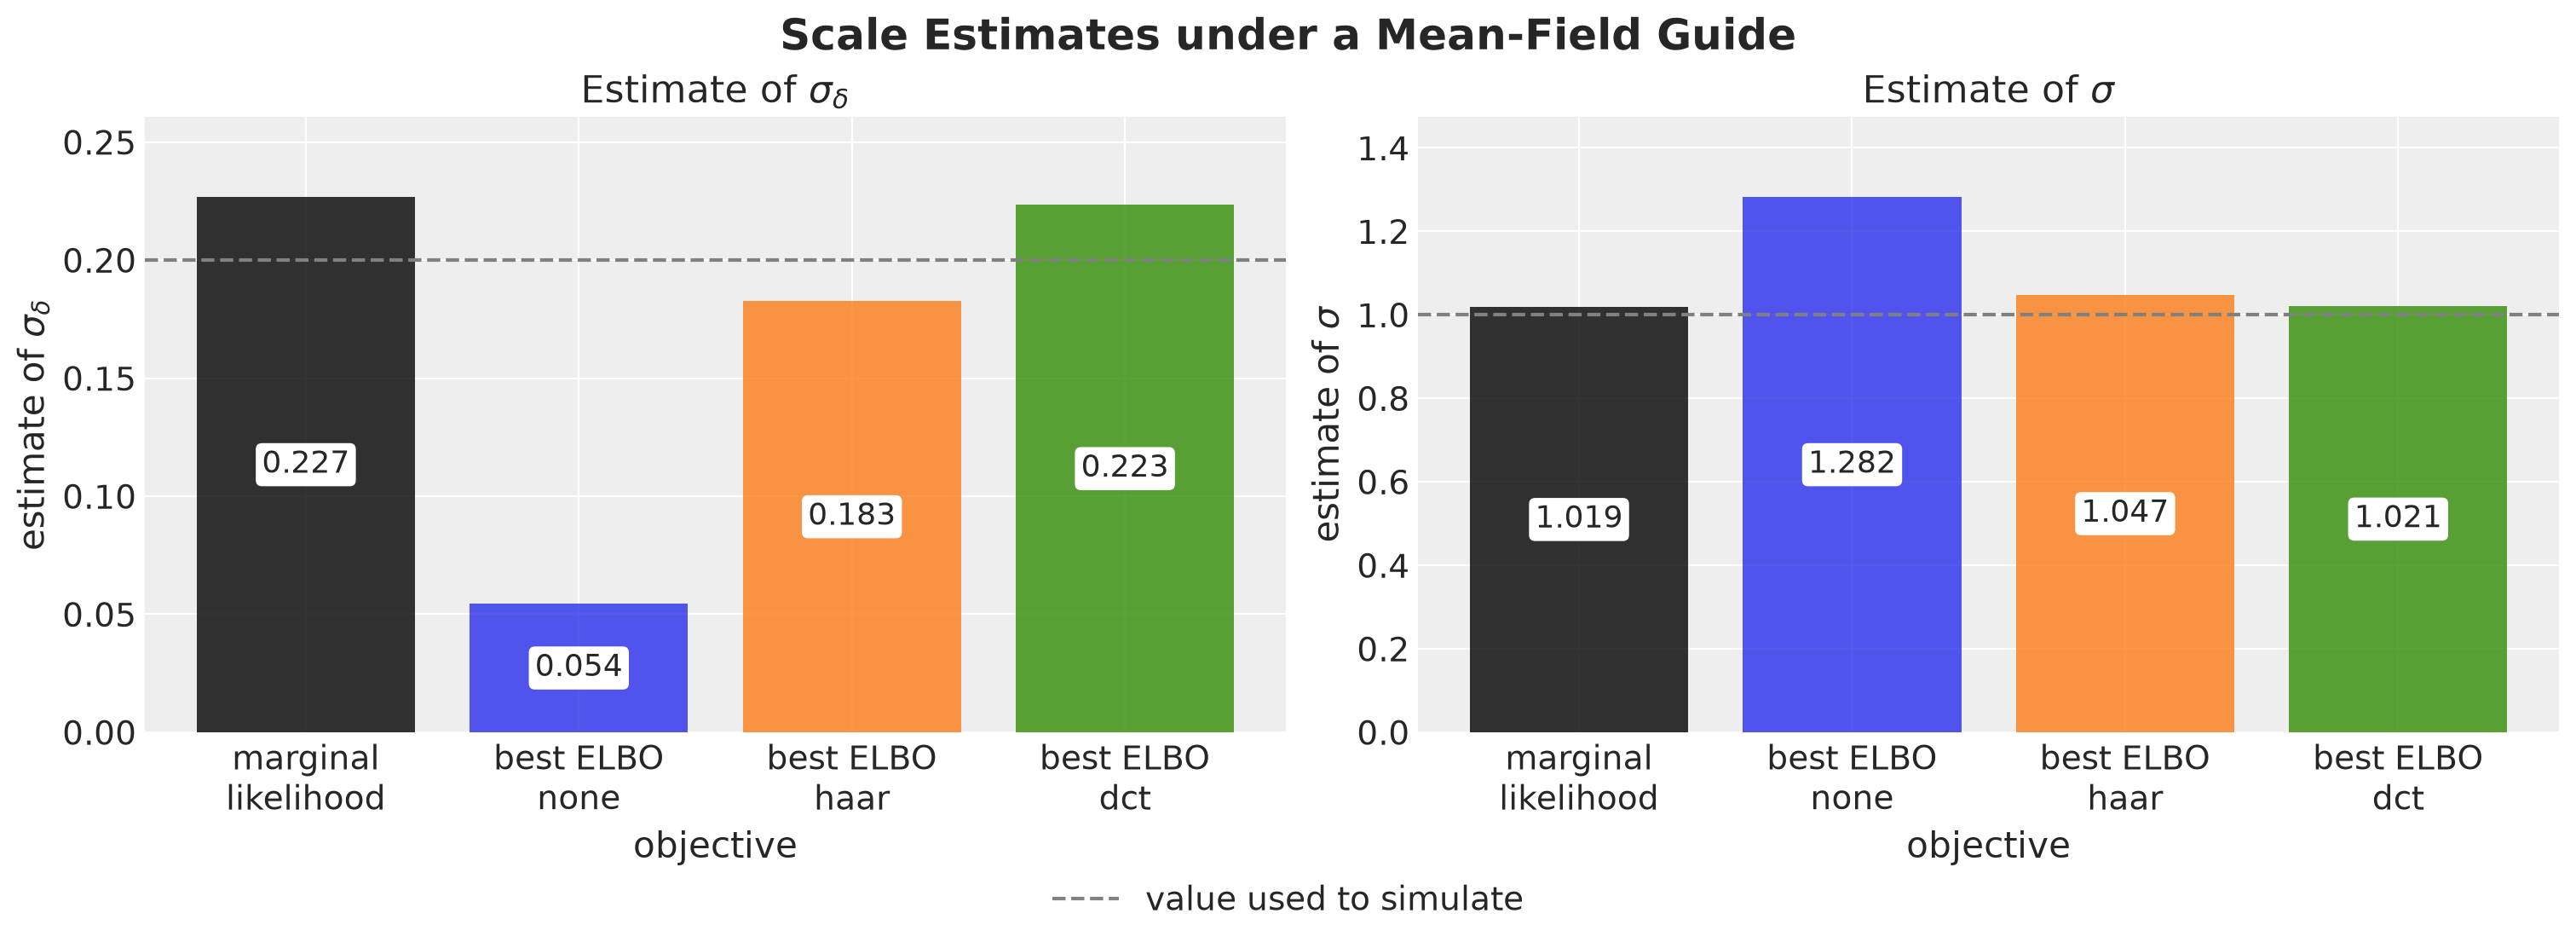

In [13]:
toy_y_values = np.asarray(toy_y, dtype=float)


def log_marginal_likelihood(drift_scale: float, sigma: float) -> float:
    "Log density of the observations, with the increments integrated out."
    y_covariance = drift_scale**2 * cumsum_matrix @ cumsum_matrix.T
    y_covariance += sigma**2 * np.eye(T_TOY)
    quadratic = toy_y_values @ np.linalg.solve(y_covariance, toy_y_values)
    log_det = np.linalg.slogdet(y_covariance)[1]
    return -0.5 * (T_TOY * np.log(2 * np.pi) + log_det + quadratic)


def best_scales(rotation: np.ndarray | None) -> np.ndarray:
    "Scales that maximize the marginal likelihood minus the mean-field gap."

    def objective(log_scales: np.ndarray) -> float:
        drift_scale, sigma = np.exp(log_scales)
        value = log_marginal_likelihood(drift_scale, sigma)
        if rotation is not None:
            value -= mean_field_gap(
                posterior_precision(T_TOY, drift_scale, sigma), rotation
            )
        return -value

    result = minimize(objective, np.log([DRIFT_SCALE, SIGMA]), method="Nelder-Mead")
    return np.exp(result.x)


scale_estimates = {"marginal likelihood": best_scales(None)} | {
    name: best_scales(u) for name, u in rotations.items()
}

objective_labels = ["marginal\nlikelihood"] + [f"best ELBO\n{name}" for name in COLORS]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5.5))
for i, (ax, symbol, truth) in enumerate(
    zip(axes, ["\\sigma_\\delta", "\\sigma"], [DRIFT_SCALE, SIGMA], strict=True)
):
    bars = ax.bar(
        range(len(scale_estimates)),
        [estimate[i] for estimate in scale_estimates.values()],
        color=["black", *COLORS.values()],
        alpha=0.8,
    )
    ax.bar_label(bars, fmt="%.3f", **BAR_LABEL_STYLE)
    ax.axhline(truth, color="gray", linestyle="--")
    ax.set_xticks(range(len(scale_estimates)), labels=objective_labels)
    ax.set(
        xlabel="objective",
        ylabel=f"estimate of ${symbol}$",
        title=f"Estimate of ${symbol}$",
        ylim=(0, 1.15 * max(estimate[i] for estimate in scale_estimates.values())),
    )
fig.legend(
    handles=[
        Line2D([], [], color="gray", linestyle="--", label="value used to simulate")
    ],
    loc="outside lower center",
)
fig.suptitle(
    "Scale Estimates under a Mean-Field Guide", fontsize=18, fontweight="bold"
);

The black bar maximizes the marginal likelihood, which is the answer without any approximation of the posterior. The colored bars maximize the best ELBO of a mean-field guide in each coordinate system. The dashed line is the value we used to simulate the data.

- **In the original coordinates the level is shrunk.** For this data set the estimate of $\sigma_\delta$ is about four times too small, and the estimate of $\sigma$ is about $25\%$ too large. The guide prefers a level that moves less, and it explains the rest as noise.
- **The rotations remove most of the bias.** With the Haar basis $\sigma_\delta$ is about $20\%$ too small, and with the DCT both estimates are within $2\%$ of the reference.

We will see the same pattern in the ridership example.

## Sampler Conditioning

We now turn to NUTS. Hamiltonian Monte Carlo moves along trajectories made of leapfrog steps. For a Gaussian target, the narrowest direction limits the step size and the widest direction sets the length of the trajectory.

The number of leapfrog steps per draw therefore grows with the ratio of the two, which is the square root of the condition number of the covariance. This is a heuristic for Gaussian targets (see [Neal, 2011](https://arxiv.org/abs/1206.1901)), and NUTS adds its own rules on top of it.

NumPyro adapts a diagonal mass matrix during warmup. It estimates the posterior variance of each coordinate and uses it to rescale that coordinate. After an ideal rescaling the sampler works with the posterior *correlation* matrix.

Let $R_U$ be the posterior correlation matrix of $z = U \delta$, and let $\lambda_{\max}(R_U)$ and $\lambda_{\min}(R_U)$ be its largest and smallest eigenvalues. The relevant quantity is therefore the condition number

$$
\kappa(U) = \frac{\lambda_{\max}(R_U)}{\lambda_{\min}(R_U)} .
$$

If $\Lambda_U$ is diagonal then $R_U = I$ and $\kappa = 1$. We also expect the adapted step size to be proportional to $\sqrt{\lambda_{\min}(R_U)}$.

HMC with an identity mass matrix is invariant under rotations, because its kinetic energy is the same in every orthonormal basis. As we noted above, the rotation only helps NUTS through the diagonal adaptation.

**Remark (alternatives):** A dense mass matrix or a full-rank guide removes the dependence on the basis, at the price of $O(T^2)$ parameters. Low-rank guides are in between. The rotation has no parameters and costs $O(T \log T)$ operations or less.

Let's compute $\kappa$ on the same grid of scale ratios.

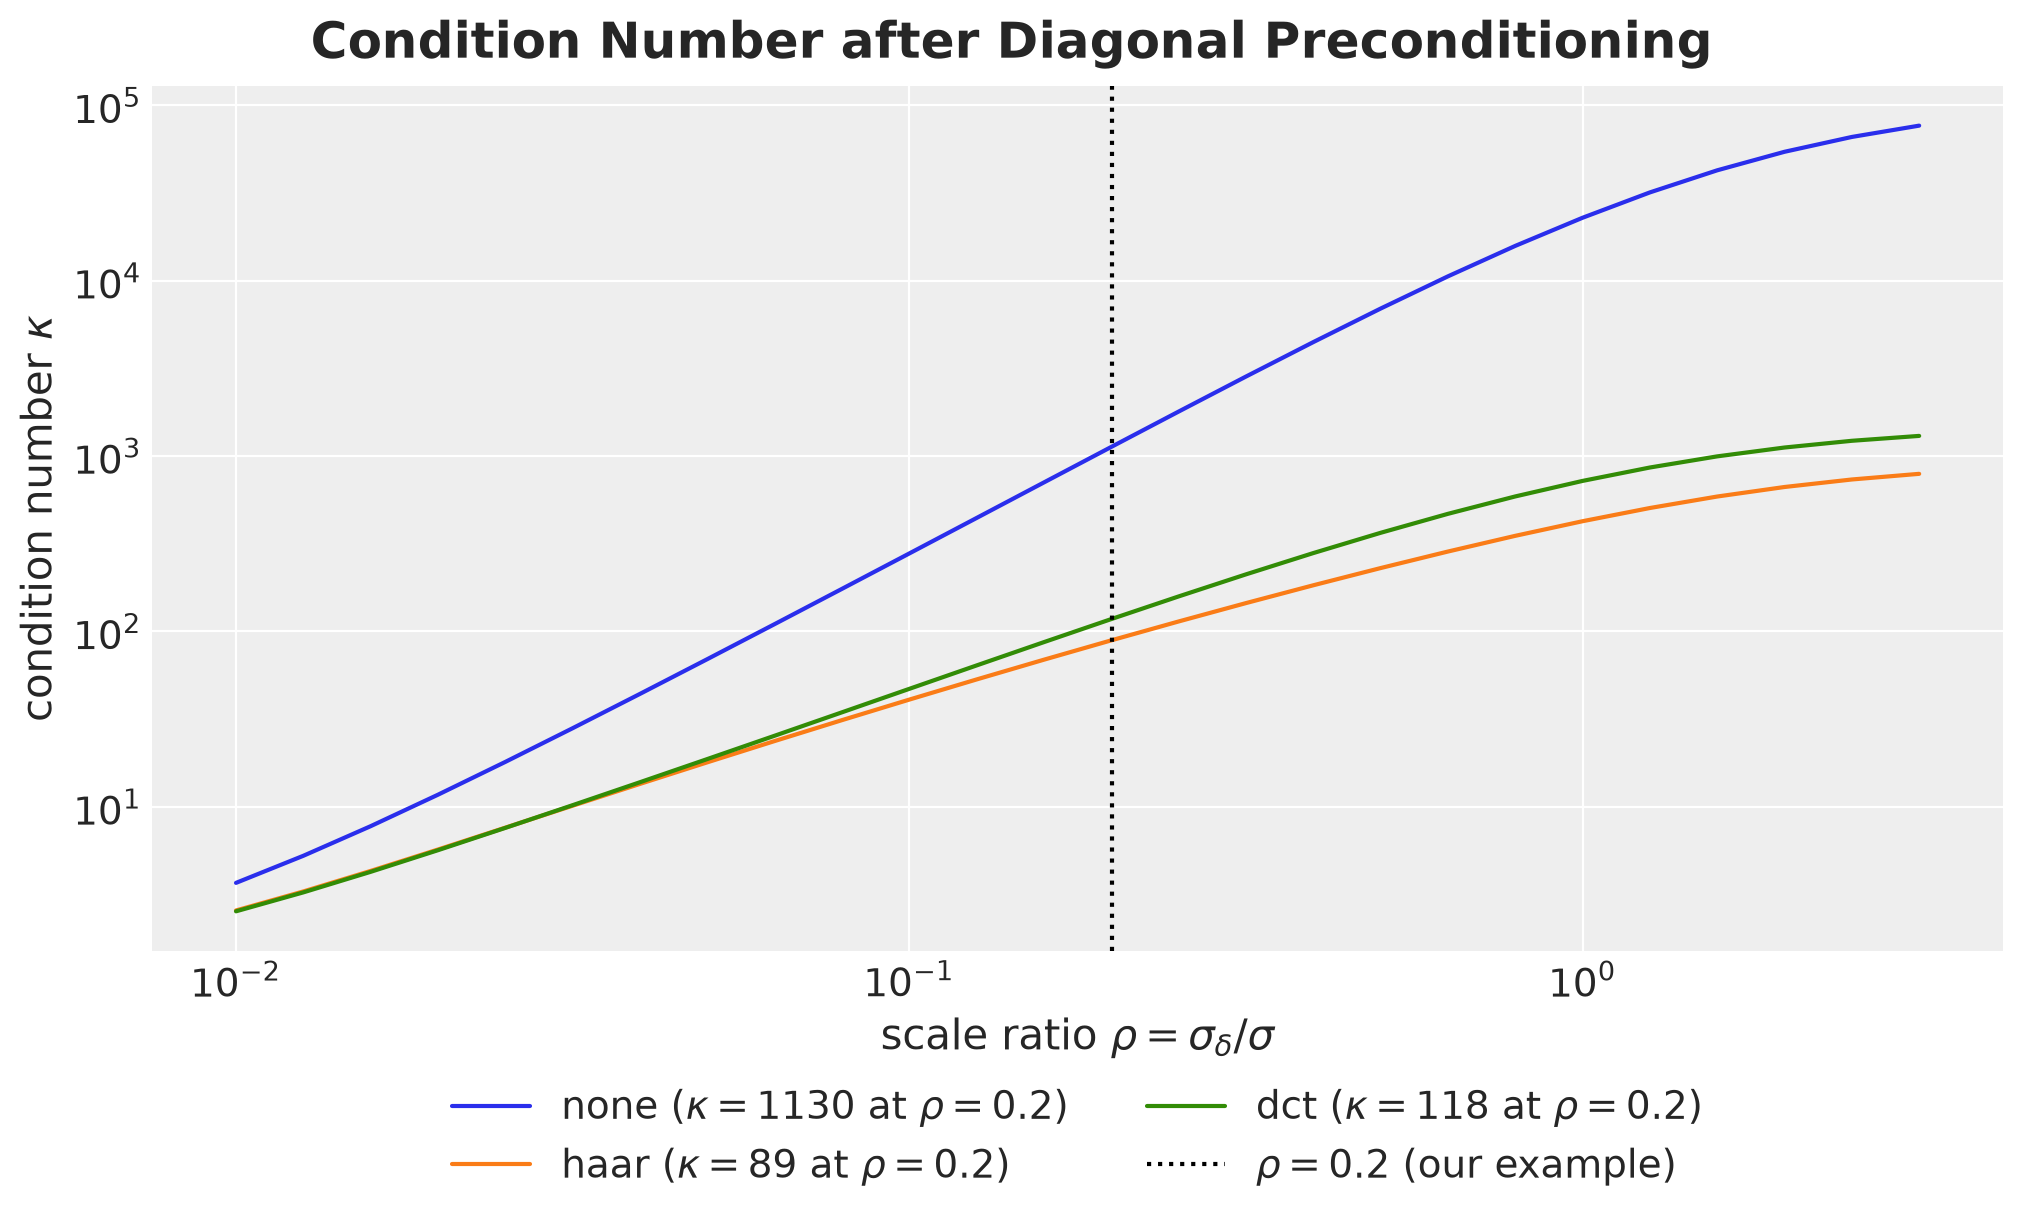

In [14]:
def correlation_eigenvalues(precision: np.ndarray, rotation: np.ndarray) -> np.ndarray:
    "Eigenvalues of the posterior correlation matrix in a coordinate system."
    rotated_covariance = rotation @ np.linalg.inv(precision) @ rotation.T
    return np.linalg.eigvalsh(normalize(rotated_covariance))


def condition_number(precision: np.ndarray, rotation: np.ndarray) -> float:
    "Condition number of the posterior correlation matrix in a coordinate system."
    eigenvalues = correlation_eigenvalues(precision, rotation)
    return eigenvalues[-1] / eigenvalues[0]


kappas = {name: condition_number(precision, u) for name, u in rotations.items()}
kappa_grid = {
    name: np.array(
        [
            condition_number(posterior_precision(T_TOY, rho, 1.0), u)
            for rho in ratio_grid
        ]
    )
    for name, u in rotations.items()
}

fig, ax = plt.subplots()
for name, values in kappa_grid.items():
    ax.plot(
        ratio_grid,
        values,
        color=COLORS[name],
        label=f"{name} ($\\kappa = {kappas[name]:.0f}$ at $\\rho = 0.2$)",
    )
ax.axvline(
    DRIFT_SCALE / SIGMA,
    color="black",
    linestyle=":",
    label="$\\rho = 0.2$ (our example)",
)
ax.set(
    xscale="log",
    yscale="log",
    xlabel="scale ratio $\\rho = \\sigma_\\delta / \\sigma$",
    ylabel="condition number $\\kappa$",
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
fig.suptitle(
    "Condition Number after Diagonal Preconditioning", fontsize=18, fontweight="bold"
);

The figure shows the condition number that remains after an ideal diagonal mass matrix, in each coordinate system. The legend gives the values for our example.

- **The diagonal adaptation does not help in the original coordinates.** For our example $\kappa$ is about $1130$, which is not smaller than the condition number $1057$ of $\Lambda$ itself.
- **The rotations reduce $\kappa$ by a factor of $6$ to $7$ at $\rho = 0.1$, and more for larger $\rho$.** For our example it goes down to about $89$ (Haar) and $118$ (DCT), a factor of $10$ to $13$.
- **The expected gain in leapfrog steps is the square root.** We go from $\sqrt{1130} \approx 34$ to about $10$, so we expect three to four times fewer leapfrog steps per draw.
- **Haar and DCT are close.** Here the Haar basis is slightly better than the DCT, the opposite of the mean-field gap. The two criteria measure different things.
- **The condition number is not $1$.** The coarsest coefficients remain strongly correlated. For the DCT the correlation between $z_0$ and $z_1$ is $-0.95$.

**Remark (the `smooth` parameter):** `DiscreteCosineTransform` has a parameter `smooth` that multiplies each coefficient by a fixed weight. A fixed diagonal rescaling changes neither the best mean-field gap nor $\kappa$, because mean-field guides and diagonal mass matrices absorb it. It only changes the starting point and the path of the optimizer.

## NumPyro Implementation

The implementation has three layers: a transform, a reparameterizer and an effect handler.

### Transforms and Reparameterizers

The first layer is the pair of transforms `HaarTransform` and `DiscreteCosineTransform` from `numpyro.distributions.transforms`. They act along one axis, they are bijective, and their `log_abs_det_jacobian` is zero. We already used them to build the matrices above.

The second layer is the reparameterizer. Both `HaarReparam` and `DiscreteCosineReparam` are thin subclasses of `UnitJacobianReparam`. Here is a sketch of its core:

```python
class UnitJacobianReparam(Reparam):
    def __init__(self, transform, suffix="transformed"):
        self.transform = transform
        self.suffix = suffix

    def __call__(self, name, fn, obs):
        assert obs is None, "only latent sites can be reparameterized"
        fn, expand_shape, event_dim = self._unwrap(fn)
        # 1. Go to the unconstrained space and rotate.
        transform = ComposeTransform([biject_to(fn.support).inv, self.transform])
        # The rotated axis must be an event dimension of the base distribution.
        base_event_dim = max(event_dim, self.transform.domain.event_dim)
        # 2. Sample the new coordinates from the transformed prior.
        x = numpyro.sample(
            f"{name}_{self.suffix}",
            dist.TransformedDistribution(
                self._wrap(fn, expand_shape, base_event_dim), transform
            ),
        )
        # 3. Rotate back. The original site becomes deterministic.
        return None, transform.inv(x)
```

A reparameterizer receives the name and the distribution `fn` of a sample site. It registers a new sample site, here `drift_dct` or `drift_haar`, whose distribution is the original prior transformed by the rotation. Then it returns the value of the original site as a function of the new one.

The third layer is the effect handler `numpyro.handlers.reparam`, which applies a reparameterizer to the sites we name. We do not change the model code. Let's create the three versions of the local level model.

In [15]:
toy_models: dict[str, Model] = {
    "none": local_level_model,
    "haar": handlers.reparam(local_level_model, config={"drift": HaarReparam(dim=-1)}),
    "dct": handlers.reparam(
        local_level_model, config={"drift": DiscreteCosineReparam(dim=-1)}
    ),
}

Let's check that the three versions define the same model: we evaluate the log joint density of the three models at the same point, written in each coordinate system.

In [16]:
log_joint, _ = log_density(
    local_level_model, toy_args, {"y": toy_y}, {"drift": toy_drift}
)

for name, transform in {
    "haar": HaarTransform(dim=-1),
    "dct": DiscreteCosineTransform(dim=-1),
}.items():
    log_joint_rotated, _ = log_density(
        toy_models[name],
        toy_args,
        {"y": toy_y},
        {f"drift_{name}": transform(toy_drift)},
    )
    np.testing.assert_allclose(log_joint_rotated, log_joint, rtol=1e-5)

The three log densities agree. We have three coordinate systems for one model. In the rotated models the only latent site is `drift_haar` or `drift_dct`, and `drift` is a deterministic site.

### The Time Plate

The reparameterizers above need the time axis to be an *event* dimension, as in `dist.Normal(...).expand([t_obs]).to_event(1)`. Forecasting models in `numpyro_forecast` use another convention.

The `innovations` block samples its increments inside `numpyro.plate("time", t_obs, dim=-2)`, which makes time a *batch* dimension. This convention leaves room for other plates, like a plate of series.

The function `time_reparam(model, transform)`, where `transform` is `"haar"` or `"dct"`, connects the two conventions, as Pyro's `Forecaster` does. Here is a condensed version:

```python
TRANSFORMS = {"haar": HaarTransform, "dct": DiscreteCosineTransform}


def time_reparam(model, transform):
    def config(msg):
        # Skip everything that is not a continuous latent sample site.
        if msg["type"] != "sample" or msg["is_observed"]:
            return None
        if msg["fn"].support.is_discrete:
            return None
        # Never target the auxiliary site that _TimeReparam creates.
        if (msg.get("infer") or {}).get(_AUX_INFER_KEY):
            return None
        # Look for an enclosing plate named "time".
        plates = [h for h in _PYRO_STACK if isinstance(h, numpyro.plate)]
        time_plate = next((p for p in plates if p.name == "time"), None)
        if time_plate is None:
            return None
        # Rotate along the axis of the time plate.
        dim = time_plate.dim - msg["fn"].event_dim
        plate_names = frozenset(p.name for p in plates)
        return _TimeReparam(TRANSFORMS[transform](dim=dim), transform, plate_names)

    return numpyro.handlers.reparam(model, config=config)
```

There are two differences from the simple case:

- **The configuration is a function.** Instead of a dictionary of site names, `handlers.reparam` receives a callable. It selects every latent, continuous sample site inside the `time` plate, which are the sites that `innovations` samples. One call reparameterizes all of them, and it leaves the global parameters, the likelihood and the forecast horizon as they are.
- **The auxiliary site ignores the plates.** The coordinates of the new site are coefficients, and they are no longer indexed by time. The class `_TimeReparam` is a `UnitJacobianReparam` that samples its auxiliary site with `infer={"block_plates": ...}` and a marker, so that the configuration never targets it a second time. The distribution of that site is the prior expanded to the full plate shape, with the time axis (and every axis to its right) converted to event dimensions.

**Remark (Pyro's names):** In Pyro `1.9.1` the two names are swapped in [`pyro.contrib.forecast.util`](https://github.com/pyro-ppl/pyro/blob/dev/pyro/contrib/forecast/util.py): `time_reparam="haar"` applies the DCT and `time_reparam="dct"` applies the Haar transform. In `numpyro_forecast` each name does what it says. Take this into account when comparing results across the two libraries.

## Local Level Experiments

We now check the two derivations on the local level model, with a fitted guide and with NUTS.

### Mean-Field Check

We fit an `AutoNormal` guide to each version of the model. The guide is a product of Normal distributions and the posterior is a Gaussian that we know, so we can compute the divergence of the fitted guide in closed form from its locations $m$ and scales $s$:

$$
\text{KL} = \frac{1}{2} \left( \sum_{i} (\Lambda_U)_{ii}\, s_i^2 + (m - U \bar{\delta})^\top \Lambda_U\, (m - U \bar{\delta}) - T - \log \det \Lambda - \sum_{i} \log s_i^2 \right) .
$$

This number cannot be smaller than the gap of the formula, and it is equal to it only if the optimizer finds the optimum. We use a learning rate that decays from $0.02$ to $10^{-4}$, so that the optimizer noise does not hide gaps of a few nats.

In [17]:
def fit_toy_guide(rng_key: Array, model: Model, num_steps: int = 20_000) -> dict:
    "Fit a mean-field guide to the local level model and return its parameters."
    guide = AutoNormal(model)
    optimizer = Adam(exponential_decay(0.02, num_steps, 0.005))
    svi = SVI(model, guide, optimizer, Trace_ELBO(num_particles=4))
    result = svi.run(rng_key, num_steps, *toy_args, y=toy_y, progress_bar=False)
    return result.params


def fitted_gap(params: dict, site: str, rotation: np.ndarray) -> float:
    "KL divergence of a fitted mean-field guide relative to the exact posterior."
    loc = np.asarray(params[f"{site}_auto_loc"], dtype=float)
    scale = np.asarray(params[f"{site}_auto_scale"], dtype=float)
    rotated = rotation @ precision @ rotation.T
    shift = loc - rotation @ drift_mean
    return 0.5 * (
        (np.diag(rotated) * scale**2).sum()
        + shift @ rotated @ shift
        - T_TOY
        - np.linalg.slogdet(precision)[1]
        - 2 * np.log(scale).sum()
    )


toy_sites = {"none": "drift", "haar": "drift_haar", "dct": "drift_dct"}

rng_key, rng_subkey = random.split(rng_key)
fitted_gaps = {
    name: fitted_gap(fit_toy_guide(rng_subkey, model), toy_sites[name], rotations[name])
    for name, model in toy_models.items()
}

We compare the gap of the fitted guides with the gap from the formula.

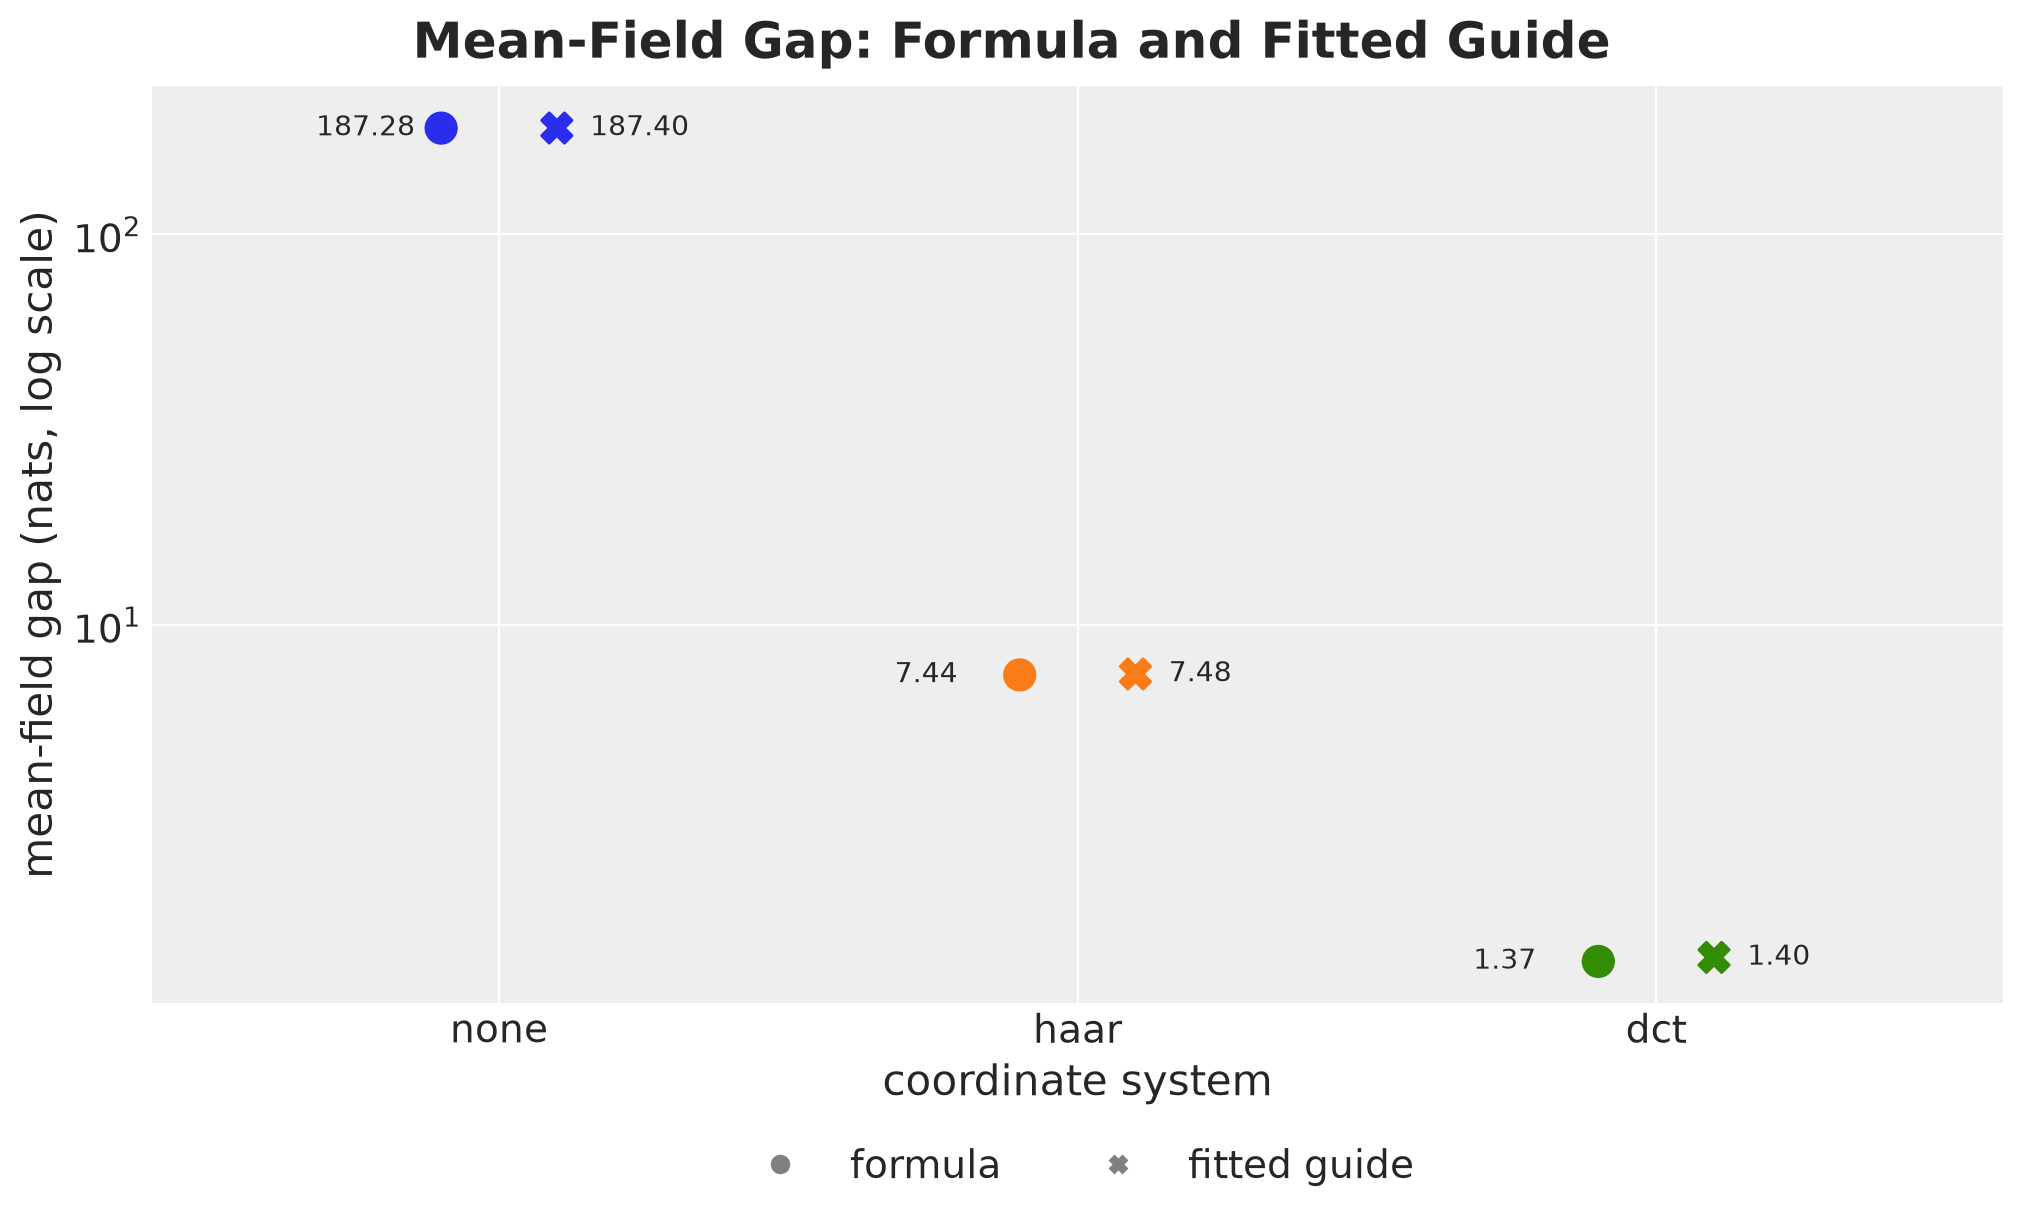

In [18]:
positions = np.arange(len(COLORS))

fig, ax = plt.subplots()
ax.scatter(
    positions - 0.1,
    [gaps[name] for name in COLORS],
    marker="o",
    s=120,
    c=list(COLORS.values()),
)
ax.scatter(
    positions + 0.1,
    [fitted_gaps[name] for name in COLORS],
    marker="X",
    s=120,
    c=list(COLORS.values()),
)
for position, name in zip(positions, COLORS, strict=True):
    ax.annotate(
        f"{gaps[name]:.2f}",
        (position - 0.1, gaps[name]),
        xytext=(-45, 0),
        textcoords="offset points",
        va="center",
    )
    ax.annotate(
        f"{fitted_gaps[name]:.2f}",
        (position + 0.1, fitted_gaps[name]),
        xytext=(12, 0),
        textcoords="offset points",
        va="center",
    )
ax.set(
    yscale="log",
    xticks=positions,
    xticklabels=list(COLORS),
    xlim=(-0.6, 2.6),
    xlabel="coordinate system",
    ylabel="mean-field gap (nats, log scale)",
)
ax.legend(
    handles=[
        Line2D([], [], color="gray", marker="o", linestyle="", label="formula"),
        Line2D([], [], color="gray", marker="X", linestyle="", label="fitted guide"),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
)
fig.suptitle(
    "Mean-Field Gap: Formula and Fitted Guide", fontsize=18, fontweight="bold"
);

For each coordinate system, the circle is the gap from the formula and the cross is the divergence of the fitted guide.

- **The fitted guides reach the predicted gap.** The two values agree in the three coordinate systems, and the fitted value is never below the formula.
- **The rotation improves the ELBO by about $180$ nats in this example.** The model, the guide family and the optimizer are the same in the three fits.

### Sampler Check

Now we check the conditioning argument. We run NUTS on the three versions of the model, with $4$ chains, $1000$ warmup steps and $1000$ draws per chain. We repeat each run with three random keys, and we record the number of leapfrog steps of every draw.

We also measure the time of one leapfrog step. A run has a fixed cost (compilation and post-processing) that hides it, so we time one chain for two different numbers of draws and take the slope. This is a single measurement per coordinate system, and it depends on the machine.

In [19]:
class NutsRun(NamedTuple):
    "Results of one NUTS run."

    idata: DataTree
    samples: dict[str, Array]
    step_size: float
    seconds: float


def run_nuts(
    rng_keys: list[Array], kernel: NUTS, num_warmup: int, *args, **kwargs
) -> list[NutsRun]:
    "Run NUTS once per random key and collect the results of every run."
    mcmc = MCMC(
        kernel,
        num_warmup=num_warmup,
        num_samples=1_000,
        num_chains=4,
        progress_bar=False,
    )
    runs = []
    for key in rng_keys:
        start = perf_counter()
        mcmc.run(key, *args, extra_fields=("num_steps",), **kwargs)
        samples = mcmc.get_samples()
        jax.block_until_ready(samples)
        seconds = perf_counter() - start
        runs.append(
            NutsRun(
                idata=az.from_numpyro(mcmc),
                samples=samples,
                step_size=float(mcmc.last_state.adapt_state.step_size.mean()),
                seconds=seconds,
            )
        )
    return runs


def leapfrog_per_draw(run: NutsRun) -> float:
    "Average number of leapfrog steps per draw, after warmup."
    return float(run.idata["sample_stats"]["n_steps"].mean())


def ess_per_1000_steps(run: NutsRun, var_name: str) -> np.ndarray:
    "Bulk ESS of every coordinate of a variable per 1000 leapfrog steps after warmup."
    ess = az.ess(run.idata, var_names=[var_name], method="bulk")[var_name]
    total_steps = float(run.idata["sample_stats"]["n_steps"].sum())
    return 1_000 * np.asarray(ess).ravel() / total_steps


def leapfrog_microseconds(kernel: NUTS, num_warmup: int, *args, **kwargs) -> float:
    "Time of one leapfrog step of a single chain, without the fixed cost of a run."
    state = None
    seconds, steps = [], []
    # We time the same chain for two lengths. The slope is the time per leapfrog step.
    for num_samples in [500, 2_000]:
        mcmc = MCMC(
            kernel, num_warmup=num_warmup, num_samples=num_samples, progress_bar=False
        )
        if state is None:
            mcmc.warmup(random.PRNGKey(0), *args, **kwargs)
            state = mcmc.post_warmup_state
        for _ in range(2):  # the first pass compiles and the second one is timed
            mcmc.post_warmup_state = state
            start = perf_counter()
            mcmc.run(state.rng_key, *args, extra_fields=("num_steps",), **kwargs)
            jax.block_until_ready(mcmc.get_samples())
            elapsed = perf_counter() - start
        seconds.append(elapsed)
        steps.append(int(mcmc.get_extra_fields()["num_steps"].sum()))
    return 1e6 * (seconds[1] - seconds[0]) / (steps[1] - steps[0])


def per_second(ess_per_1000: np.ndarray, step_cost: float) -> np.ndarray:
    "Convert an ESS per 1000 leapfrog steps to an ESS per second of leapfrog steps."
    return 1e3 * ess_per_1000 / step_cost


rng_key, *toy_nuts_keys = random.split(rng_key, 4)
toy_runs = {
    name: run_nuts(toy_nuts_keys, NUTS(model), 1_000, *toy_args, y=toy_y)
    for name, model in toy_models.items()
}
toy_step_cost = {
    name: leapfrog_microseconds(NUTS(model), 1_000, *toy_args, y=toy_y)
    for name, model in toy_models.items()
}

We first look at the cost of a draw. We compare three quantities:

- **Step size.** The adapted step size relative to the original coordinates, next to the prediction $\sqrt{\lambda_{\min}(R_U)}$.
- **Leapfrog steps.** The average number of leapfrog steps per draw.
- **Time per leapfrog step.** A leapfrog step needs one gradient of the log density, and the rotation is part of that gradient.

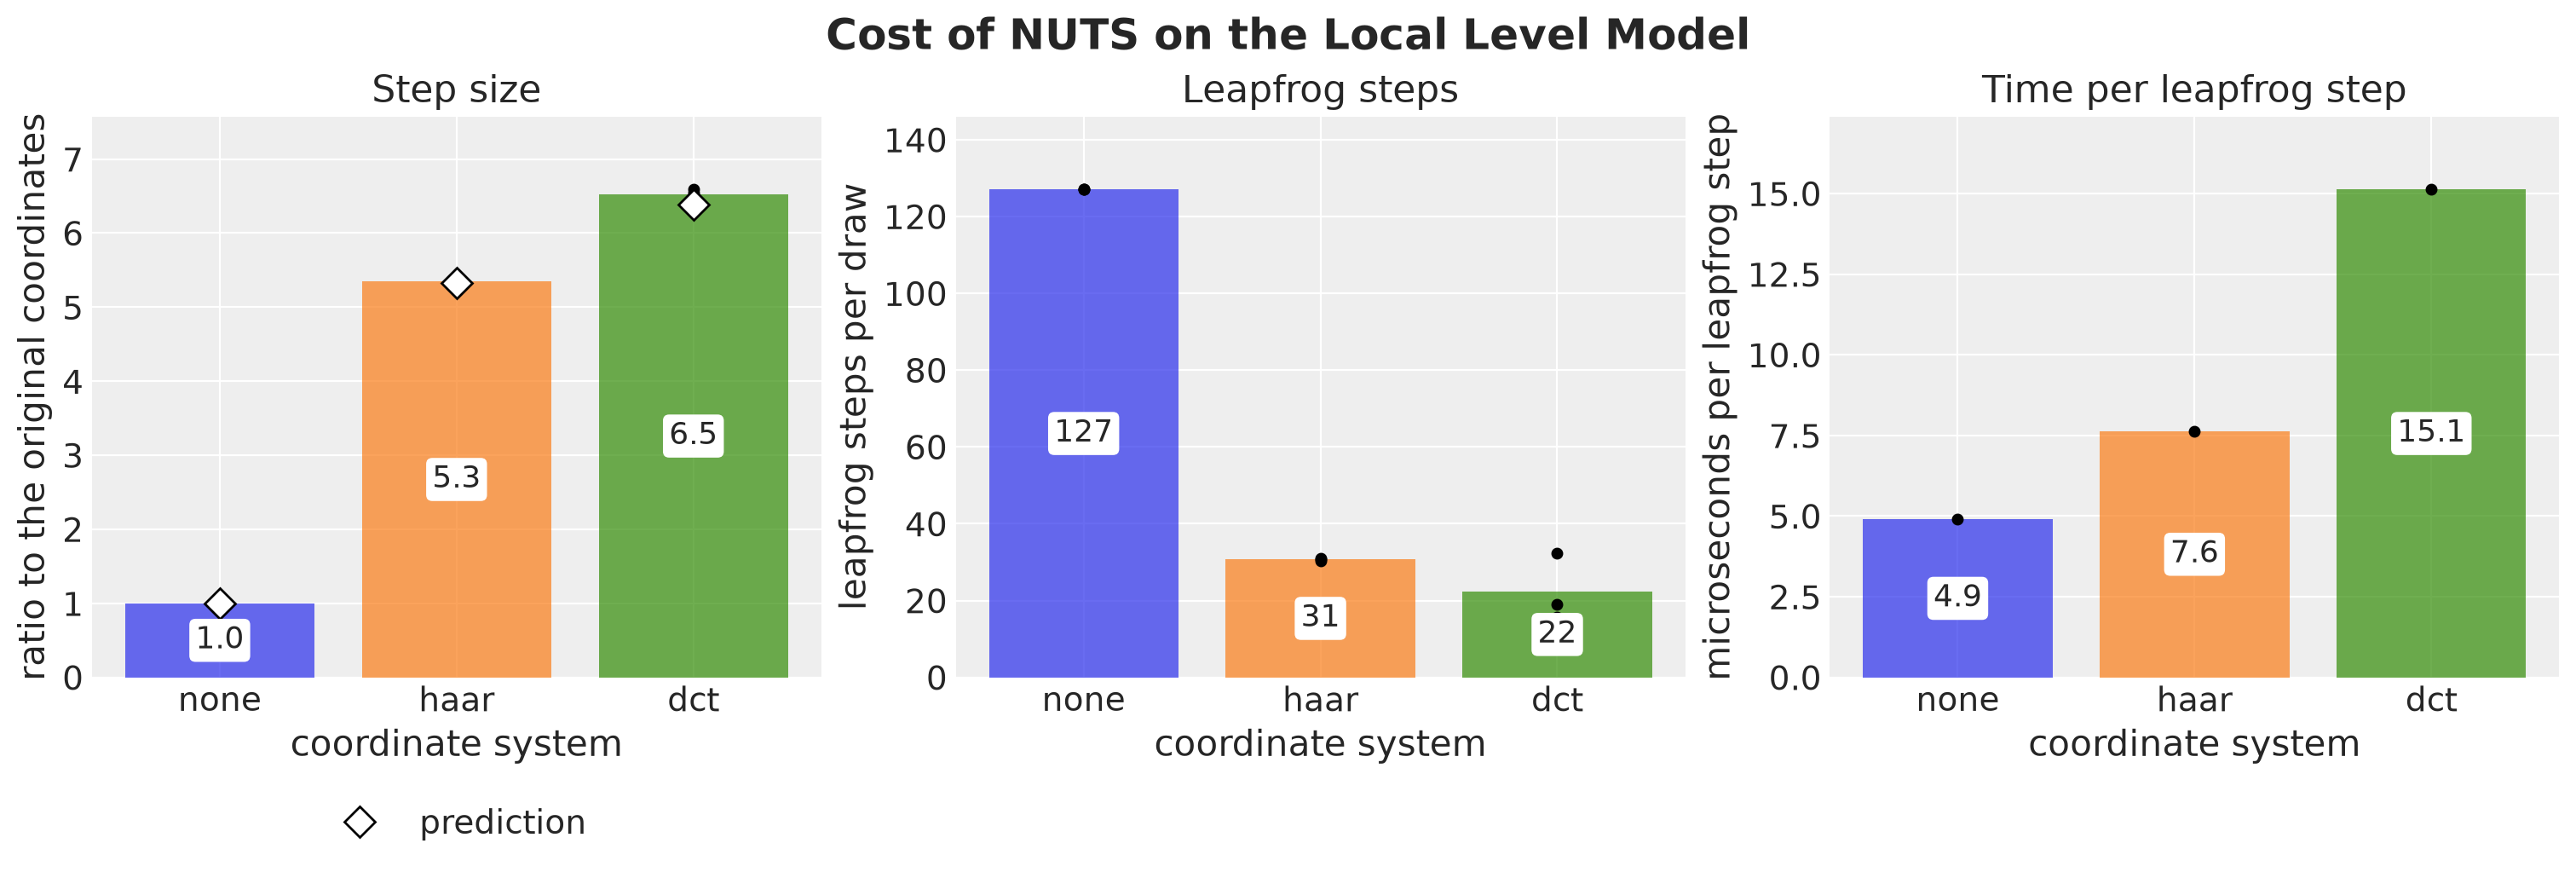

In [20]:
def plot_runs(
    ax: plt.Axes,
    values: dict[str, list[float]],
    fmt: str,
    title: str,
    ylabel: str,
    colors: dict[str, str] = COLORS,
    xlabel: str = "coordinate system",
) -> None:
    "One bar per group with the mean over runs (labeled), and one black point per run."
    means = [float(np.mean(runs)) for runs in values.values()]
    bars = ax.bar(
        list(values), means, color=[colors[name] for name in values], alpha=0.7
    )
    ax.bar_label(bars, labels=[format(mean, fmt) for mean in means], **BAR_LABEL_STYLE)
    for position, runs in enumerate(values.values()):
        ax.plot(np.full(len(runs), position), runs, "o", color="black", markersize=4)
    top = max(max(runs) for runs in values.values())
    ax.set(xlabel=xlabel, ylabel=ylabel, title=title, ylim=(0, 1.15 * top))


step_size_theory = {
    name: np.sqrt(correlation_eigenvalues(precision, u)[0])
    for name, u in rotations.items()
}
reference_step_size = np.mean([run.step_size for run in toy_runs["none"]])

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
plot_runs(
    axes[0],
    {
        name: [run.step_size / reference_step_size for run in runs]
        for name, runs in toy_runs.items()
    },
    fmt=".1f",
    title="Step size",
    ylabel="ratio to the original coordinates",
)
axes[0].plot(
    list(COLORS),
    [step_size_theory[name] / step_size_theory["none"] for name in COLORS],
    "D",
    color="white",
    markeredgecolor="black",
    markersize=9,
    label="prediction",
)
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18))
plot_runs(
    axes[1],
    {name: [leapfrog_per_draw(run) for run in runs] for name, runs in toy_runs.items()},
    fmt=".0f",
    title="Leapfrog steps",
    ylabel="leapfrog steps per draw",
)
plot_runs(
    axes[2],
    {name: [cost] for name, cost in toy_step_cost.items()},
    fmt=".1f",
    title="Time per leapfrog step",
    ylabel="microseconds per leapfrog step",
)
fig.suptitle("Cost of NUTS on the Local Level Model", fontsize=18, fontweight="bold");

In this figure and in the next ones, each bar is the mean over the runs, the number inside is that mean, and each black point is one run. The white diamonds in the first panel are the prediction.

- **The step size follows the prediction.** It grows by a factor of $5.3$ (Haar) and $6.5$ (DCT). The prediction is $5.3$ and $6.4$.
- **The rotated runs take about four times fewer leapfrog steps.** NUTS doubles the length of a trajectory until it turns back, so the counts per draw are of the form $2^j - 1$. The average count goes from $127$ to about $31$ (Haar) and to between $16$ and $32$ (DCT), depending on the run. The ratio of the $\sqrt{\kappa}$ values is between $3$ and $3.6$, and a measurement in factors of two cannot distinguish it from $4$.
- **A leapfrog step takes longer in the rotated coordinates.** The gradient of this model is little more than a cumulative sum, so the transform is a large part of it. A step takes about $1.6$ times longer with the Haar transform and about $3$ times longer with the DCT.

A draw needs fewer steps and each step costs more. The net effect depends on how informative the draws are.

We compute the bulk effective sample size (ESS) of the level per $1000$ leapfrog steps, for the median coordinate and for the worst one. For the worst coordinate we also convert it to an ESS per second, with the time per leapfrog step of the last panel. This conversion counts the leapfrog steps after warmup and leaves out the overhead of running four chains in parallel.

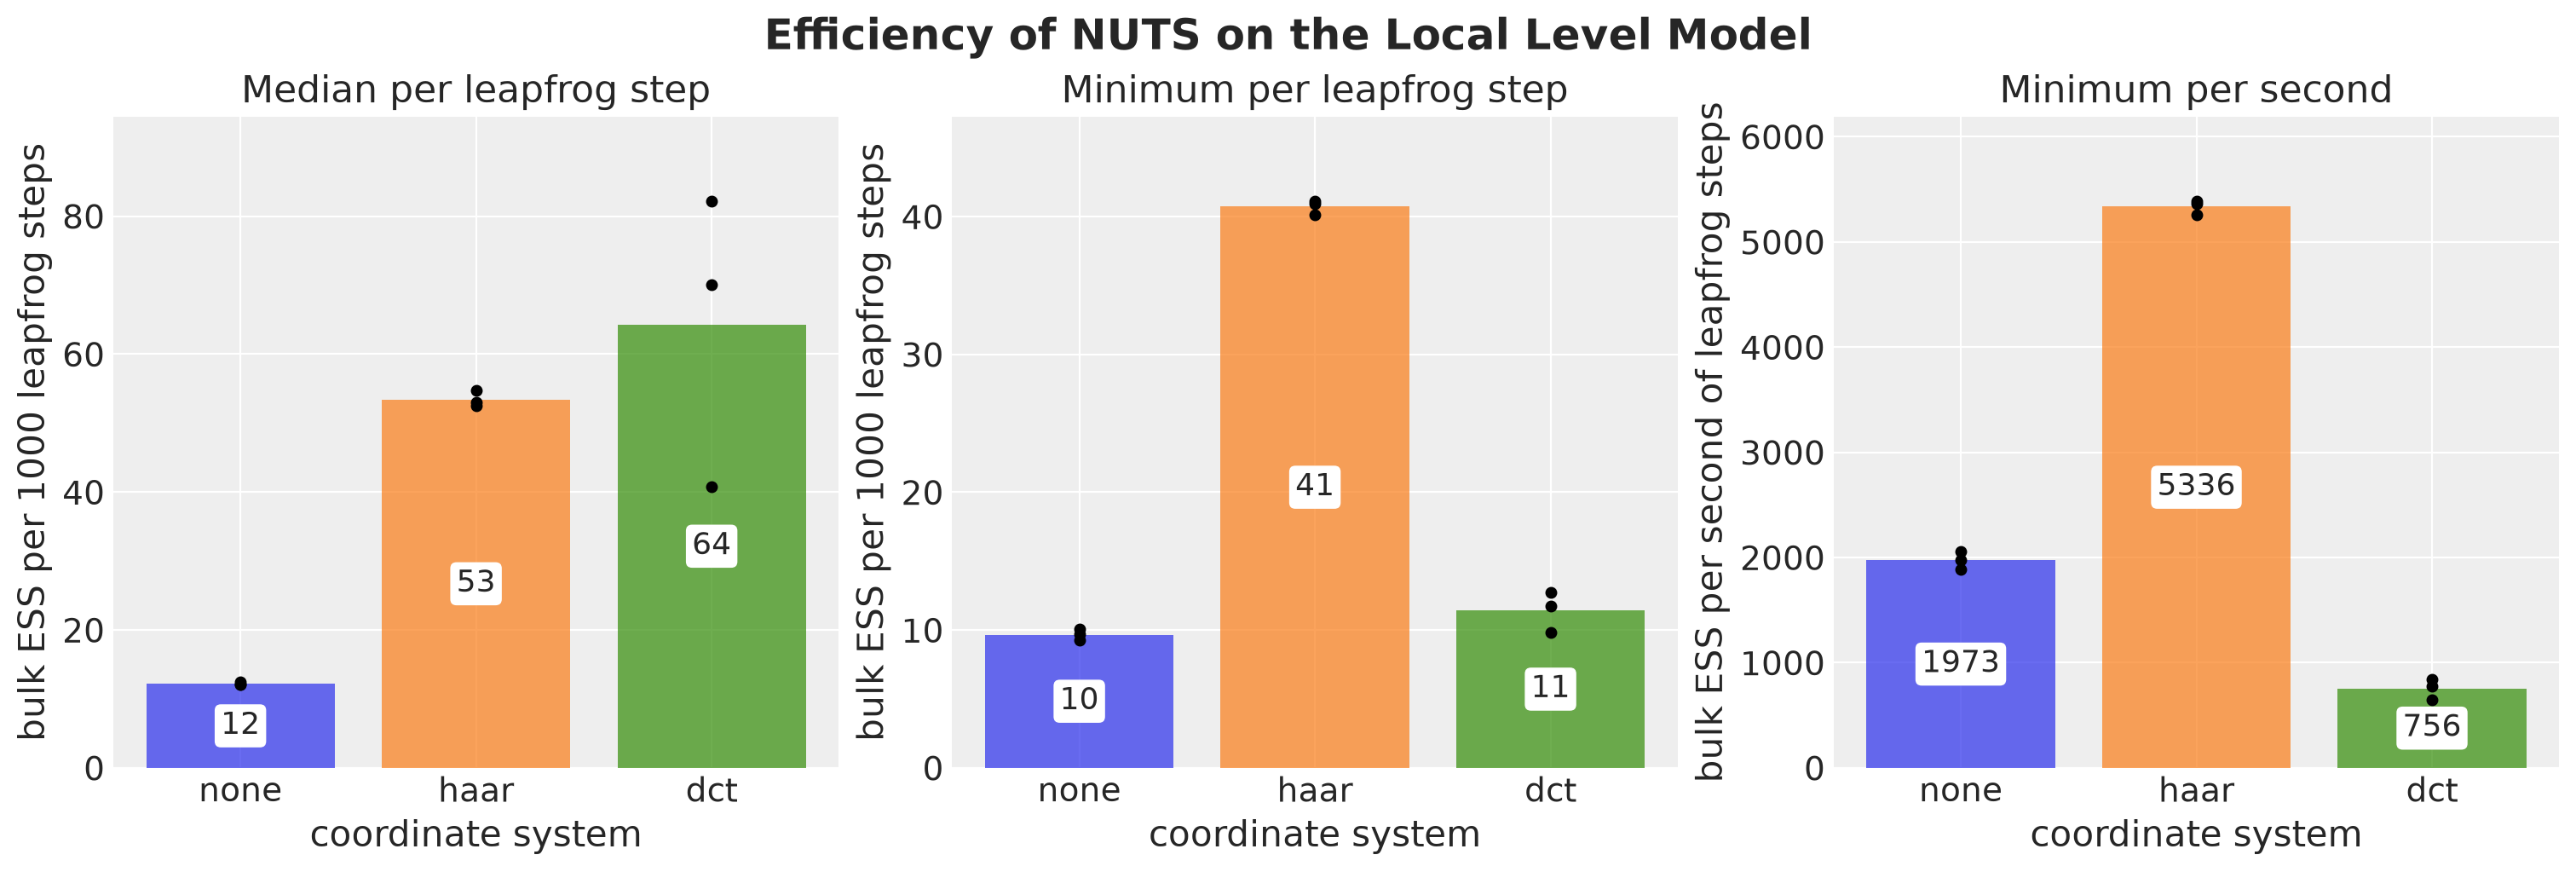

In [21]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
for ax, statistic, label in zip(
    axes[:2], [np.median, np.min], ["Median", "Minimum"], strict=True
):
    plot_runs(
        ax,
        {
            name: [float(statistic(ess_per_1000_steps(run, "level"))) for run in runs]
            for name, runs in toy_runs.items()
        },
        fmt=".0f",
        title=f"{label} per leapfrog step",
        ylabel="bulk ESS per 1000 leapfrog steps",
    )
plot_runs(
    axes[2],
    {
        name: [
            float(
                per_second(ess_per_1000_steps(run, "level").min(), toy_step_cost[name])
            )
            for run in runs
        ]
        for name, runs in toy_runs.items()
    },
    fmt=".0f",
    title="Minimum per second",
    ylabel="bulk ESS per second of leapfrog steps",
)
fig.suptitle(
    "Efficiency of NUTS on the Local Level Model", fontsize=18, fontweight="bold"
);

The first two panels count leapfrog steps after warmup, and the third panel counts the seconds that those steps take.

- **Per leapfrog step, the Haar run is about four times more efficient.** This holds for the median coordinate and for the worst one, in the three runs.
- **Per leapfrog step, the DCT run gains on the median coordinate only.** Its median efficiency is about five times the original one, with a large variation between runs. Its minimum efficiency is not better than in the original coordinates.
- **Per second, the Haar run is about $2.7$ times more efficient.** The cost of the transform takes a part of the gain and leaves a clear improvement.
- **Per second, the DCT run is worse on the worst coordinate.** Its minimum ESS per second is about $2.6$ times lower than in the original coordinates.

Next, we look for the worst coordinates. We use `az.plot_convergence_dist` to look at the distribution of the bulk ESS and of $\hat{R}$ over the $256$ coordinates of `level` in the first run.

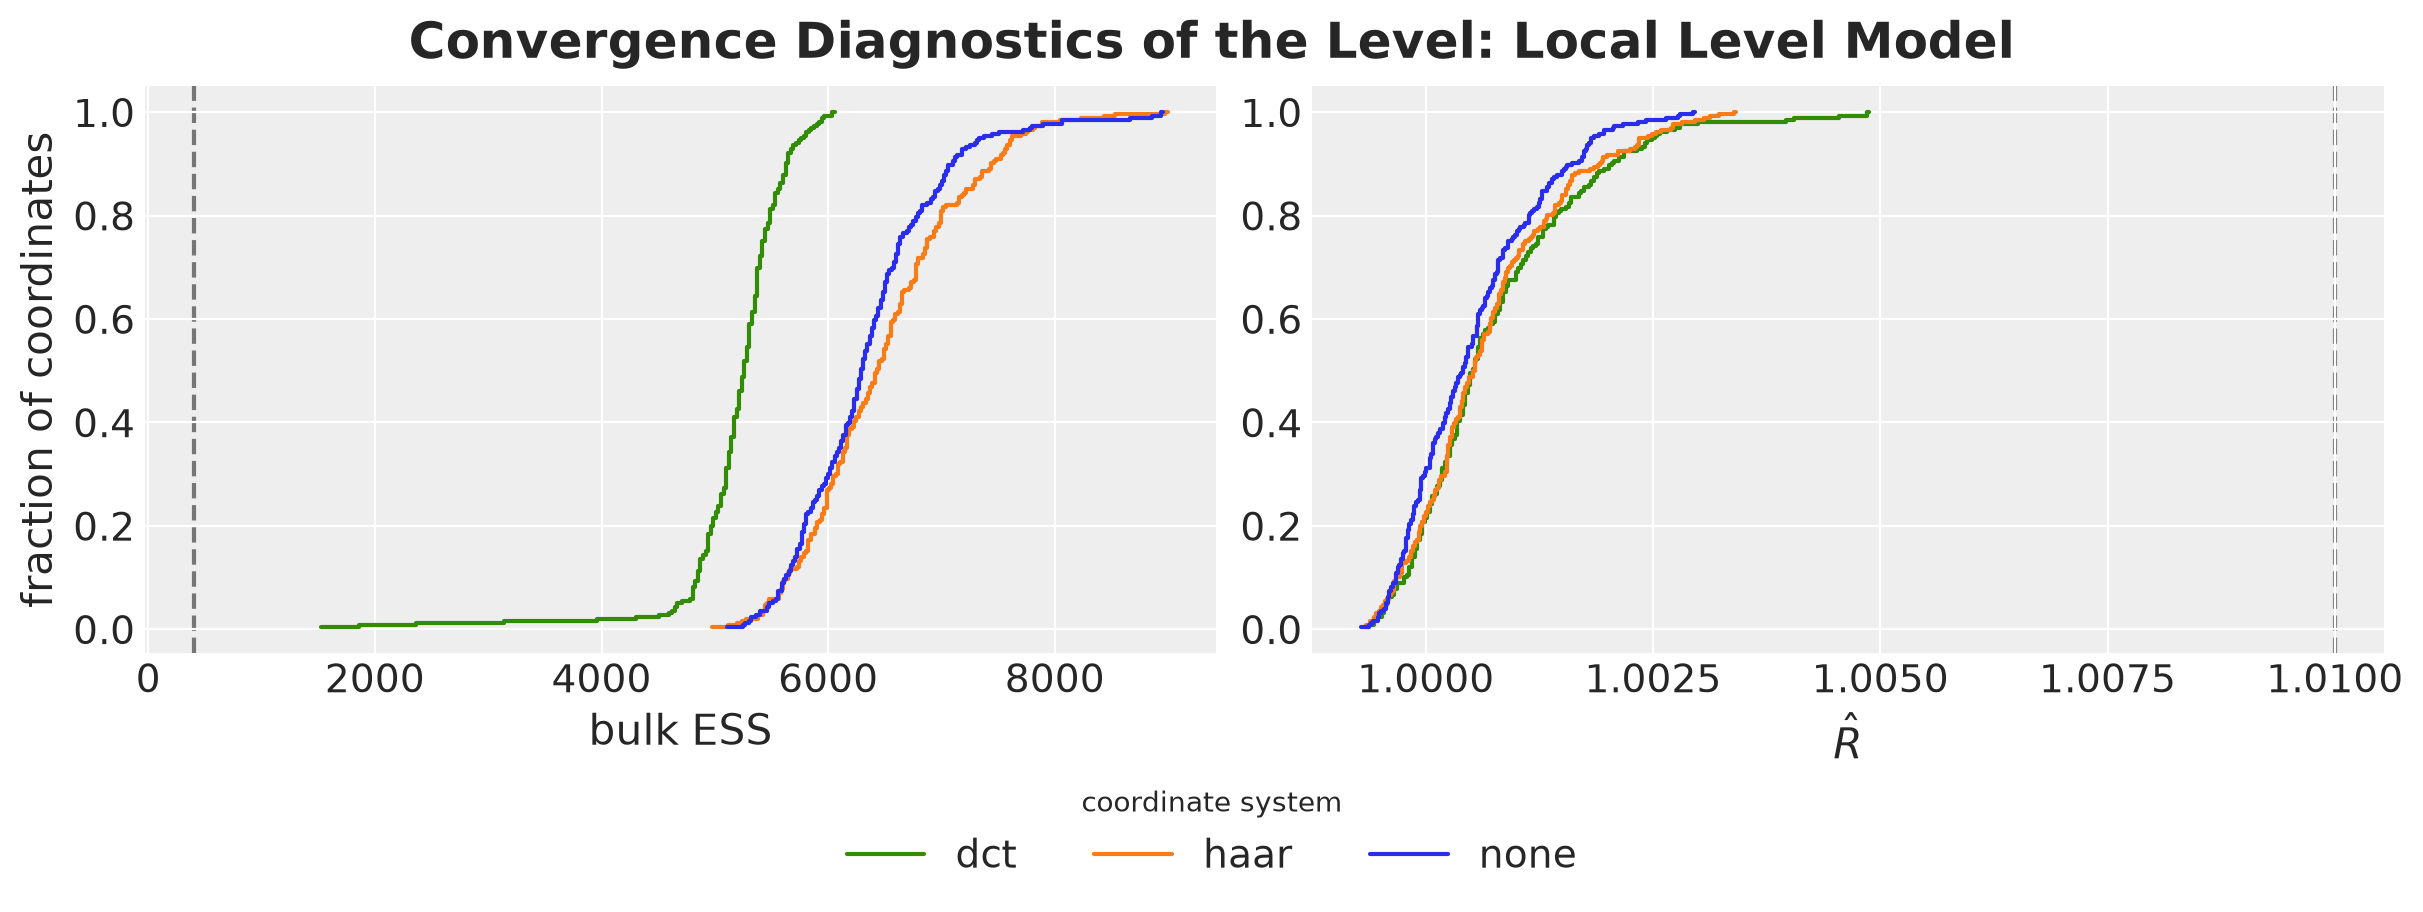

In [22]:
def label_panels(pc, title: str, xlabels: dict[str, str] | None = None) -> plt.Figure:
    "Add a figure title to an ArviZ plot and move the panel titles to the x axis."
    fig = pc.viz["figure"].item()
    for ax in fig.axes:
        name = ax.get_title()
        if name:
            ax.set(xlabel=(xlabels or {}).get(name, name), title="")
            ax.locator_params(axis="x", nbins=5)
    fig.suptitle(title, fontsize=18, fontweight="bold")
    return fig


diagnostic_labels = {"ess_bulk": "bulk ESS", "rhat_rank": "$\\hat{R}$"}
# `plot_convergence_dist` sorts the models by name, so we sort the colors too.
sorted_colors = [COLORS[name] for name in sorted(COLORS)]

pc = az.plot_convergence_dist(
    {name: runs[0].idata for name, runs in toy_runs.items()},
    var_names=["level"],
    diagnostics=list(diagnostic_labels),
    color=sorted_colors,
    figure_kwargs={"figsize": (12, 4.5)},
)
pc.add_legend("model", title="coordinate system", loc="outside lower center", ncols=3)
fig = label_panels(
    pc, "Convergence Diagnostics of the Level: Local Level Model", diagnostic_labels
)
fig.axes[0].set(ylabel="fraction of coordinates");

Each curve is the empirical cumulative distribution of one diagnostic over the coordinates of `level`. The dashed vertical lines are the usual thresholds, $400$ for the ESS and $1.01$ for $\hat{R}$. For the ESS a curve further to the right is better, and for $\hat{R}$ a curve further to the left is better.

- **The diagnostics show no convergence problem.** The $\hat{R}$ values are below $1.01$ and the ESS values are above $400$ in the three coordinate systems.
- **The ESS per draw is of the same order.** The median bulk ESS is about $6300$ in the original coordinates, $6400$ with Haar and $5300$ with the DCT. It can be larger than the number of draws ($4000$), because consecutive NUTS draws are often negatively correlated.
- **The DCT run has a tail of coordinates with a low ESS.** The five coordinates with the lowest ESS, down to about $1500$, are the last five levels. They depend on the strongly coupled coarse coefficients.

The step sizes and the leapfrog counts agree with the conditioning argument. The efficiency adds two caveats. The last levels, which the mean-field guide gets wrong, are also the slowest coordinates for the sampler in the DCT basis. Also, a saving in leapfrog steps is a saving in time only as far as the transform is cheap relative to the rest of the gradient.

## Ridership Forecasting Model

Now we move to real data and to a model where nothing is exact. We use the example of the Pyro tutorial [Forecasting I: univariate, heavy tailed](https://pyro.ai/examples/forecasting_i.html), in the `numpyro_forecast` version of the [univariate forecasting example](https://juanitorduz.github.io/numpyro_forecast/docs/examples/forecasting_univariate.html).

### Data

The data are the total weekly ridership of the BART train system, on the log scale. We hold out the last $52$ weeks as a test set. The seasonal features are a Fourier basis with $26$ harmonics of the yearly period.

We load the data, split it, and plot it.

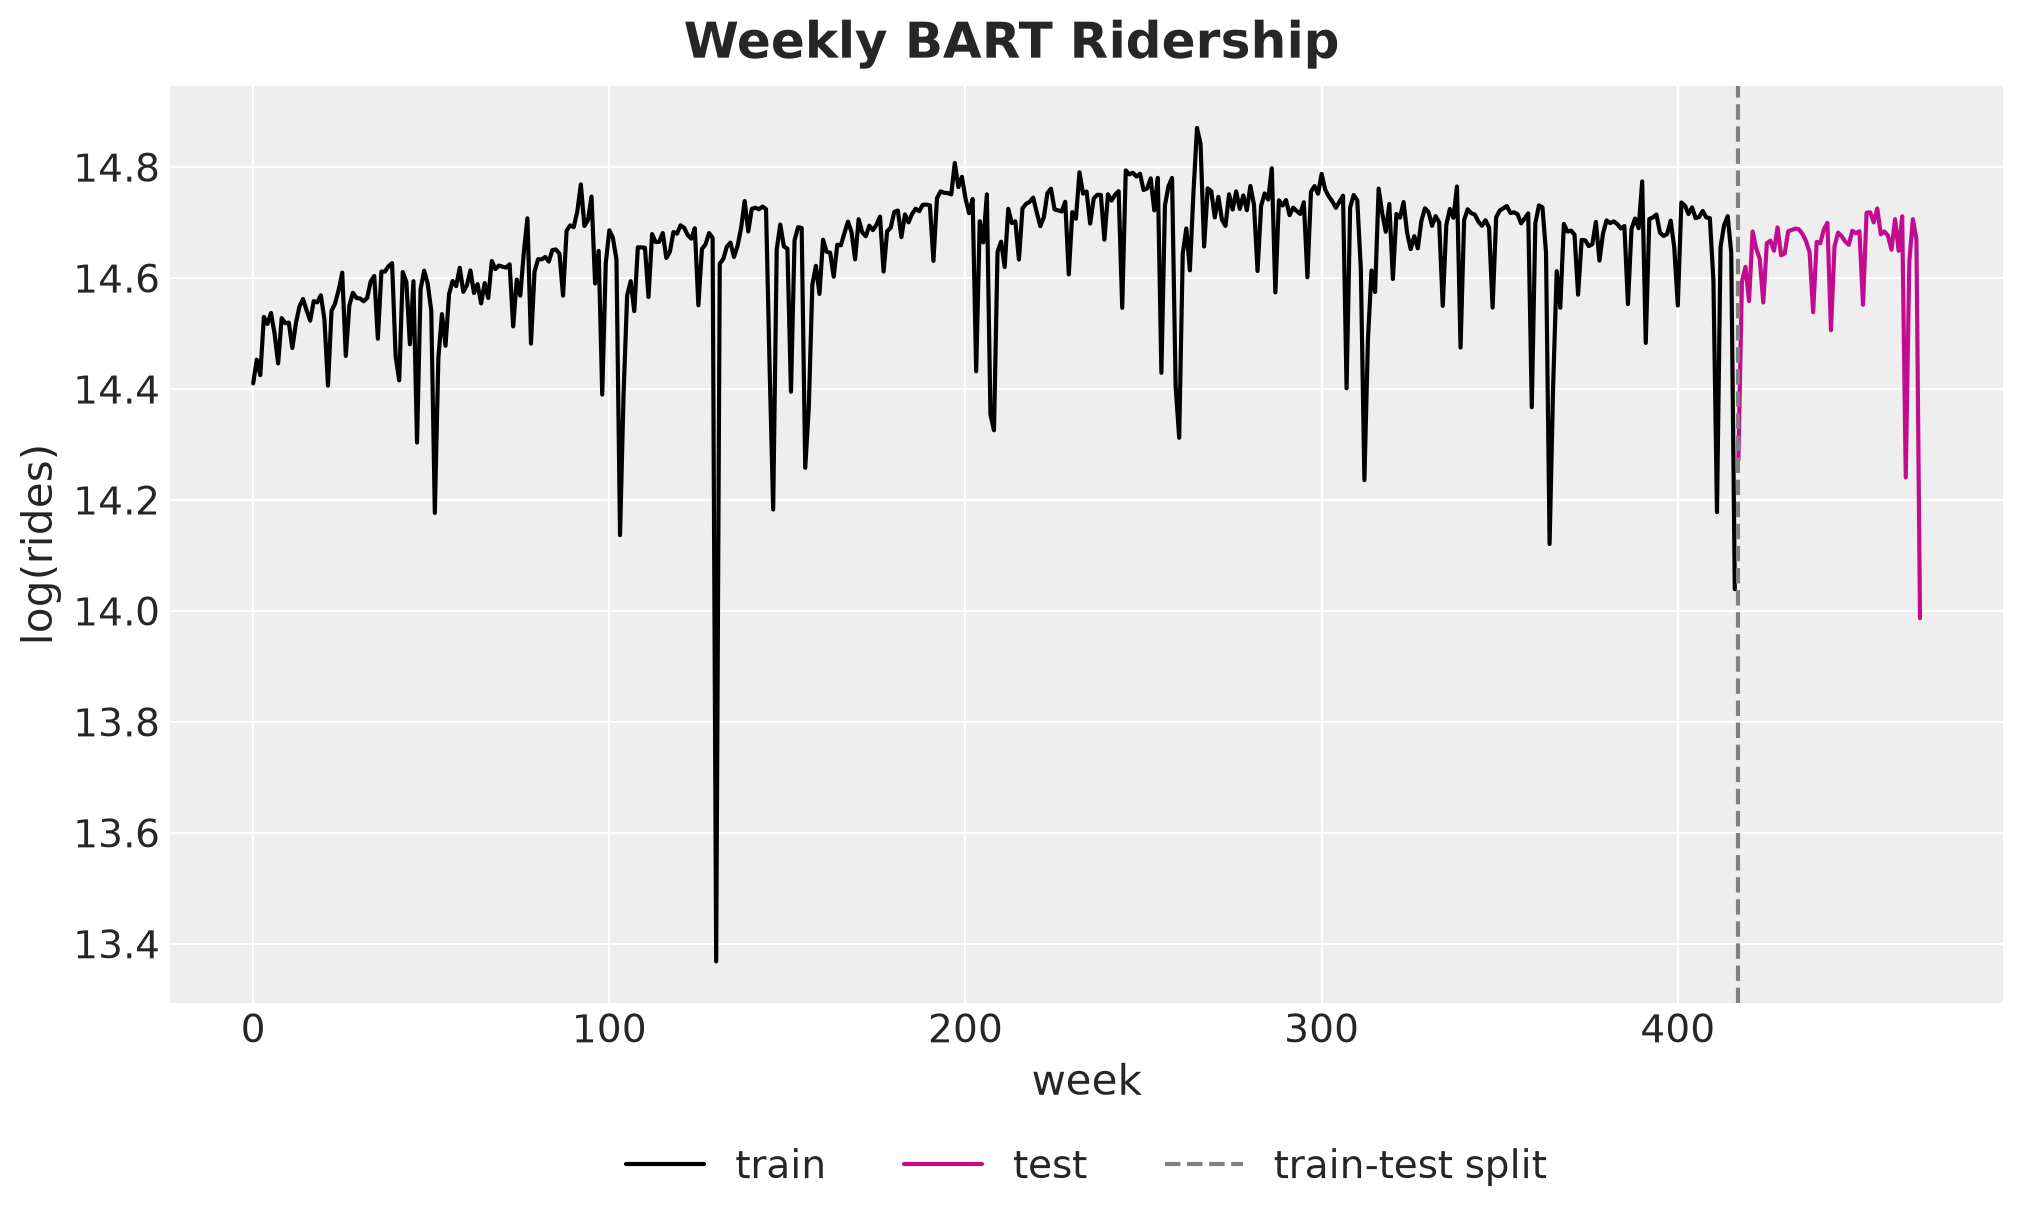

In [23]:
data = load_bart_weekly()
duration = data.shape[0]
t_train = duration - 52

y_train = data[:t_train]
y_test = data[t_train:]

covariates = fourier_features(duration, period=365.25 / 7, num_terms=26)
covariates_train = covariates[:t_train]

weeks = np.arange(duration)
weeks_train = weeks[:t_train]
weeks_test = weeks[t_train:]

fig, ax = plt.subplots()
ax.plot(weeks_train, y_train[:, 0], color="black", label="train")
ax.plot(weeks_test, y_test[:, 0], color="C3", label="test")
ax.axvline(t_train, color="gray", linestyle="--", label="train-test split")
ax.set(xlabel="week", ylabel="log(rides)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
fig.suptitle("Weekly BART Ridership", fontsize=18, fontweight="bold");

The series has $417$ training weeks and $52$ test weeks.

- **The level moves slowly.** There is a trend that changes over the years, which is what the random-walk level has to capture.
- **There is a yearly pattern with sharp drops.** The drops are holiday weeks. This is the reason for a heavy-tailed likelihood.

### Model Specification

The model is a local level with a seasonal regression and Student-T noise. Let $x_t$ be the vector of Fourier features of week $t$, $w$ the regression weights, $b$ a global intercept, and $\nu$ the degrees of freedom.

Let $\mu_t$ be the location of the observation $y_t$. The model is

\begin{align*}
\mu_t & = b + \ell_t + w^\top x_t, \\
\ell_t & = \sum_{s \le t} \delta_s, \\
\delta_t & \sim \text{Normal}(0, \sigma_\delta), \\
y_t & \sim \text{StudentT}(\nu, \mu_t, \sigma).
\end{align*}

This is the local level model of the first part with three complications: the scales $\sigma_\delta$ and $\sigma$ are unknown, the likelihood is not Gaussian, and there are an intercept and a regression.

We keep the priors of the Pyro tutorial. The model follows the `numpyro_forecast` convention: it takes `(covariates, data)`, derives the forecast horizon with `Horizon.from_data`, samples the increments with `innovations`, and hands the prediction to `predict`. We also register the level as a deterministic site, to compare it across fits.

We sample the increments in the non-centered parameterization, $\delta_t = \sigma_\delta\, \varepsilon_t$ with $\varepsilon_t \sim \text{Normal}(0, 1)$, through `LocScaleReparam(centered=0.0)`. This reduces the strong dependence between a scale and the variables it scales, which is known as the funnel ([Gorinova, Moore and Hoffman, 2020](https://arxiv.org/abs/1906.03028)). It is a different problem from the one we study here.

**Remark (the `centered` site):** The documentation example samples the amount of centering as an extra site `centered`. That site does not change the model, so its exact posterior is its prior, and NUTS does not mix on it: it has an $\hat{R}$ of $1.82$ in the [comparison of inference methods](https://juanitorduz.github.io/numpyro_forecast/docs/examples/inference_methods_comparison.html). We fix the value, so that the NUTS diagnostics below are about the time axis only.

Here is the model.

In [24]:
def ridership_model(
    covariates: Float[Array, "duration features"],
    data: Float[Array, "t_obs 1"] | None = None,
) -> None:
    "Local level with a Fourier regression and Student-T observations."
    h = Horizon.from_data(covariates, data)
    num_features = covariates.shape[-1]

    bias = numpyro.sample("bias", dist.Normal(0.0, 10.0))
    weight = numpyro.sample(
        "weight", dist.Normal(0.0, 0.1).expand([num_features]).to_event(1)
    )
    drift_scale = numpyro.sample("drift_scale", dist.LogNormal(-20.0, 5.0))
    nu = numpyro.sample("nu", dist.Gamma(10.0, 2.0))
    sigma = numpyro.sample("sigma", dist.LogNormal(-5.0, 5.0))

    drift = innovations(
        h,
        "drift",
        dist.Normal(0.0, drift_scale),
        reparam=LocScaleReparam(centered=0.0),
    )
    level = numpyro.deterministic("level", jnp.cumsum(drift, axis=-2))
    regression = (weight * covariates).sum(axis=-1, keepdims=True)

    predict(h, dist.StudentT(df=nu, loc=0.0, scale=sigma), bias + level + regression)

Each rotated version of the model is one call to `time_reparam`. We create each wrapped model once and reuse it for fitting and forecasting.

In [25]:
models: dict[str, Model] = {
    "none": ridership_model,
    "haar": time_reparam(ridership_model, "haar"),
    "dct": time_reparam(ridership_model, "dct"),
}

Let's render the DCT version to see which sites it has.

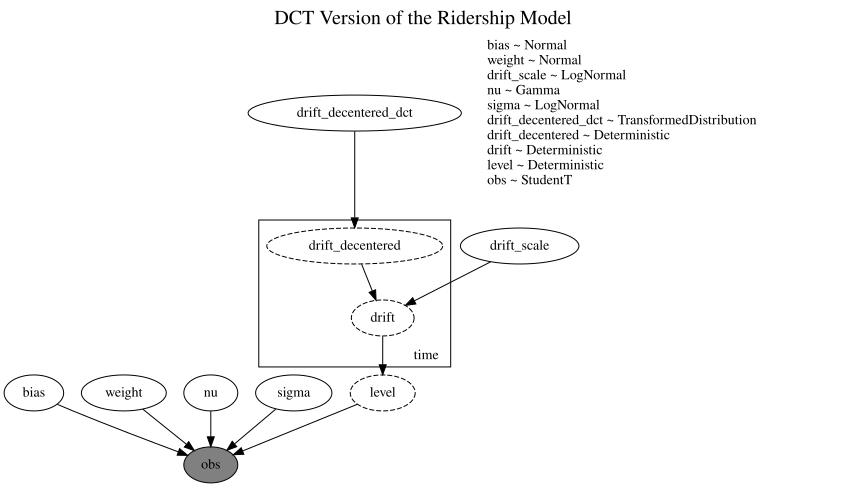

In [26]:
graph = numpyro.render_model(
    models["dct"],
    model_args=(covariates_train, y_train),
    render_distributions=True,
)
graph.attr(label="DCT Version of the Ridership Model", labelloc="t", fontsize="20")
graph

The graph shows the sites of the reparameterized model. Solid ellipses are latent sites, dashed ellipses are deterministic sites, the gray ellipse is the observed site, and the box is the `time` plate.

- **The new latent site is `drift_decentered_dct`.** It is outside the `time` plate, because its $417$ coordinates are DCT coefficients and not time steps.
- **The sites inside the plate are deterministic.** The model computes both `drift_decentered` (the standardized increments $\varepsilon_t$) and `drift` from the new site.
- **The other sites are the same as in the model code.** The global parameters, the level and the likelihood do not change.

## Variational Inference

We fit an `AutoNormal` guide to each version of the model, with the optimizer and the number of steps of the documentation example: `Adam` with a step size of $0.005$ for $50000$ steps. The result of one fit depends on the random key, so we repeat every fit with five random keys, the same five for the three coordinate systems.

We also initialize the location of `bias` at the mean of the training data. The data are close to $14.6$ on the log scale, and the default initialization draws every location uniformly in $(-2, 2)$. We study the default initialization in the next subsection.

In [27]:
NUM_STEPS = 50_000


class Fit(NamedTuple):
    "Result of one SVI fit."

    guide: AutoNormal
    params: dict[str, Array]
    losses: np.ndarray
    seconds: float


def fit_guide(rng_key: Array, model: Model, init_loc_fn: Callable) -> Fit:
    "Fit a mean-field guide to a version of the ridership model."
    guide = AutoNormal(model, init_loc_fn=init_loc_fn)
    svi = SVI(model, guide, Adam(step_size=0.005), Trace_ELBO())
    start = perf_counter()
    result = svi.run(rng_key, NUM_STEPS, covariates_train, y_train, progress_bar=False)
    losses = np.asarray(result.losses)
    return Fit(guide, result.params, losses, perf_counter() - start)


def final_loss(fit: Fit) -> float:
    "Average ELBO loss over the last 1000 steps."
    return float(fit.losses[-1_000:].mean())


init_bias = init_to_value(values={"bias": y_train.mean()})

rng_key, *svi_keys = random.split(rng_key, 6)
svi_fits = {
    name: [fit_guide(key, model, init_bias) for key in svi_keys]
    for name, model in models.items()
}

We plot the ELBO loss (the negative ELBO, in nats, so lower is better) of the first fit in each coordinate system. The curves are rolling means over $200$ steps.

The left panel shows the first $10000$ steps, with the final loss of the original fit as a dotted line. The middle panel shows the last $20000$ steps, and the arrow is the difference between the final losses of the original and the DCT fits. The legend gives the average loss over the last $1000$ steps.

The right panel shows the time of a fit. The first fit of each model includes the compilation, so we show the other four.

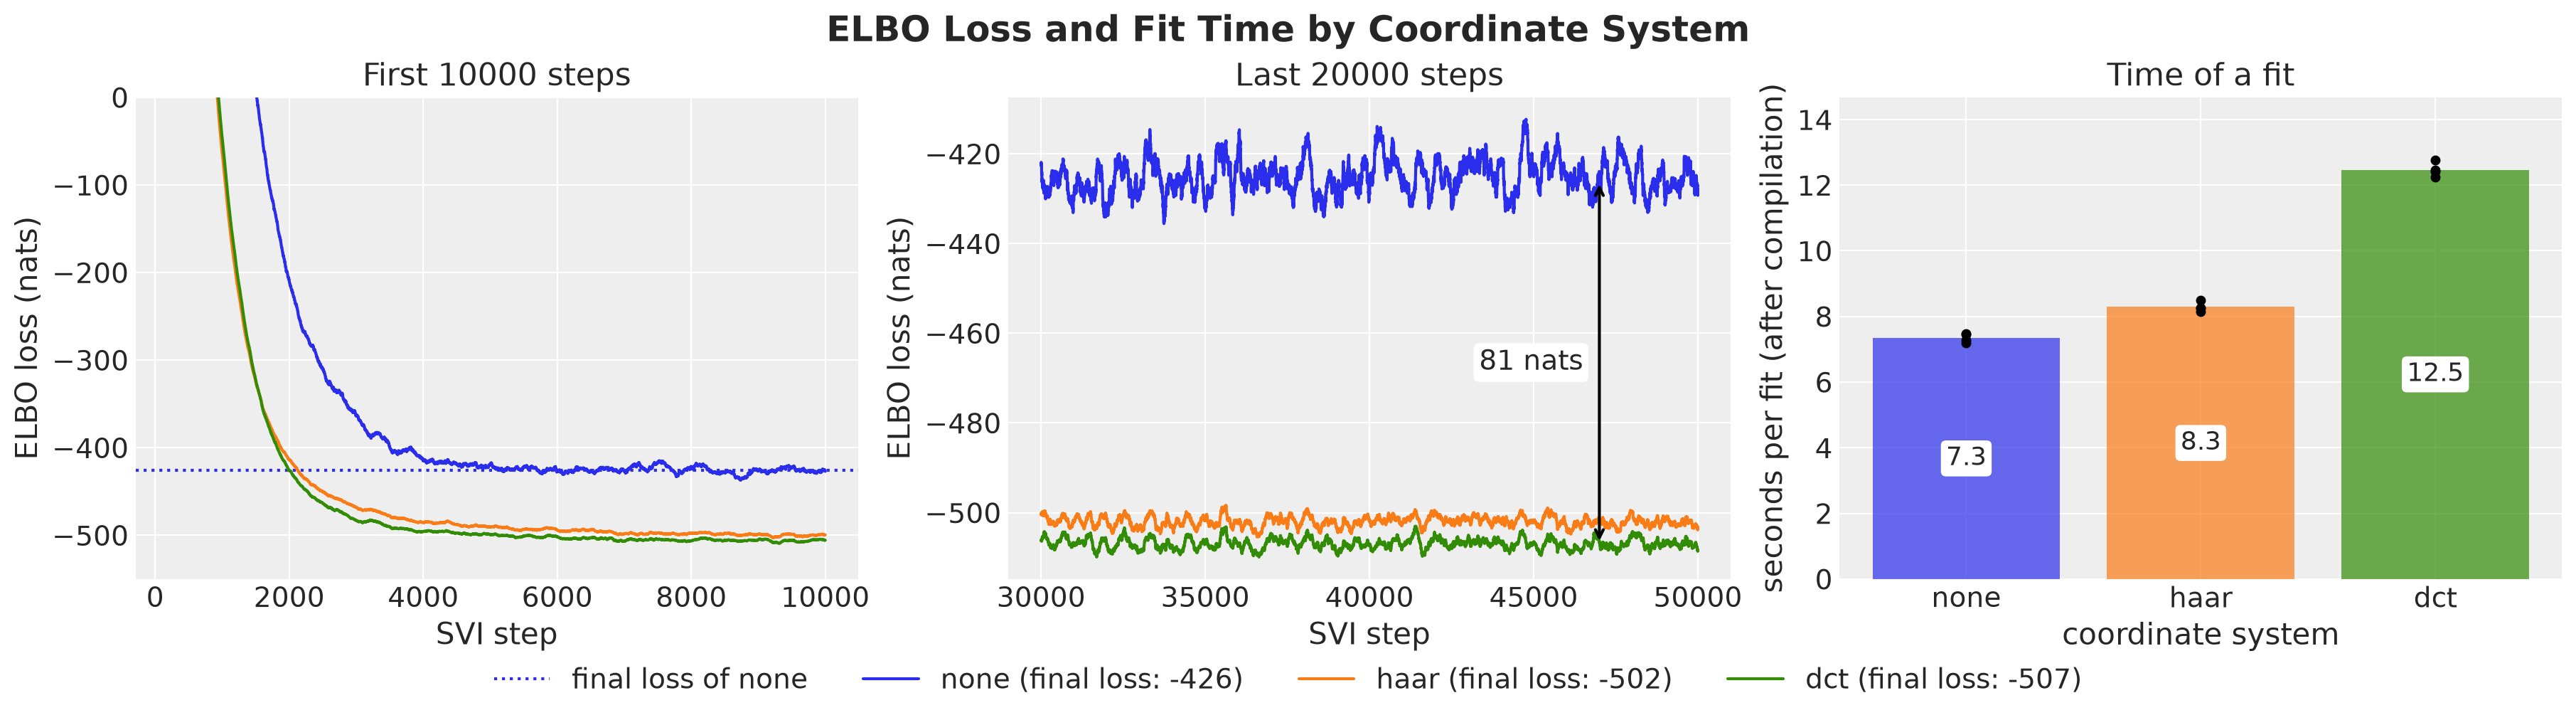

In [28]:
def rolling_mean(values: np.ndarray, window: int = 200) -> np.ndarray:
    "Rolling mean, aligned with the right end of each window."
    return np.convolve(values, np.ones(window) / window, mode="valid")


window = 200
steps = np.arange(window - 1, NUM_STEPS)
early = steps < 10_000
late = steps >= NUM_STEPS - 20_000

none_final_loss = final_loss(svi_fits["none"][0])
dct_final_loss = final_loss(svi_fits["dct"][0])
arrow_step = NUM_STEPS - 3_000

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
axes[0].axhline(
    none_final_loss, color=COLORS["none"], linestyle=":", label="final loss of none"
)
for name, fits in svi_fits.items():
    smooth = rolling_mean(fits[0].losses, window)
    axes[0].plot(
        steps[early],
        smooth[early],
        color=COLORS[name],
        label=f"{name} (final loss: {final_loss(fits[0]):.0f})",
    )
    axes[1].plot(steps[late], smooth[late], color=COLORS[name])
axes[0].set(
    xlabel="SVI step",
    ylabel="ELBO loss (nats)",
    title="First 10000 steps",
    ylim=(-550, 0),
)
axes[1].set(xlabel="SVI step", ylabel="ELBO loss (nats)", title="Last 20000 steps")
axes[1].annotate(
    "",
    xy=(arrow_step, dct_final_loss),
    xytext=(arrow_step, none_final_loss),
    arrowprops={"arrowstyle": "<->", "color": "black", "linewidth": 1.5},
)
axes[1].text(
    arrow_step - 500,
    (none_final_loss + dct_final_loss) / 2,
    f"{none_final_loss - dct_final_loss:.0f} nats",
    ha="right",
    va="center",
    fontsize=14,
    bbox=BAR_LABEL_STYLE["bbox"],
)
plot_runs(
    axes[2],
    {name: [fit.seconds for fit in fits[1:]] for name, fits in svi_fits.items()},
    fmt=".1f",
    title="Time of a fit",
    ylabel="seconds per fit (after compilation)",
)
fig.legend(loc="outside lower center", ncol=4)
fig.suptitle(
    "ELBO Loss and Fit Time by Coordinate System", fontsize=18, fontweight="bold"
);

The three curves are the same guide family fitted to the same model, in three coordinate systems.

- **The rotated fits reach a much better ELBO.** The final loss is about $-426$ in the original coordinates, $-502$ with the Haar transform and $-507$ with the DCT. The gain is about $75$ nats with Haar and $80$ nats with the DCT.
- **They are ahead during the whole run.** The rotated fits cross the dotted line after about $2000$ steps. The original fit needs about $5000$ steps to reach its own final loss.
- **A step costs more in the rotated coordinates.** A fit takes about $7$ seconds in the original coordinates, $8$ with the Haar transform and $12$ with the DCT. The rotated fits need less than half the steps to reach the final loss of the original fit, so they are also ahead in time.
- **The DCT is slightly ahead of Haar.** The difference is about $5$ nats, the same order as in the local level model.
- **The loss is less noisy in the rotated coordinates.** In the last $20000$ steps the smoothed loss of the original fit varies about three times more than the rotated ones.

The log evidence is the same for the three models, so a better ELBO means a guide that is closer to the posterior 🚀. We look at what this means for the parameters and for the forecasts in the last section.

### Initialization

What happens with the default initialization? We repeat all the fits with `init_to_uniform`, the default of `AutoNormal`, and the same random keys.

In [29]:
default_fits = {
    name: [fit_guide(key, model, init_to_uniform) for key in svi_keys]
    for name, model in models.items()
}

We plot the complete loss curves of the first fit (left), and the final loss of all the fits for the two initializations (right).

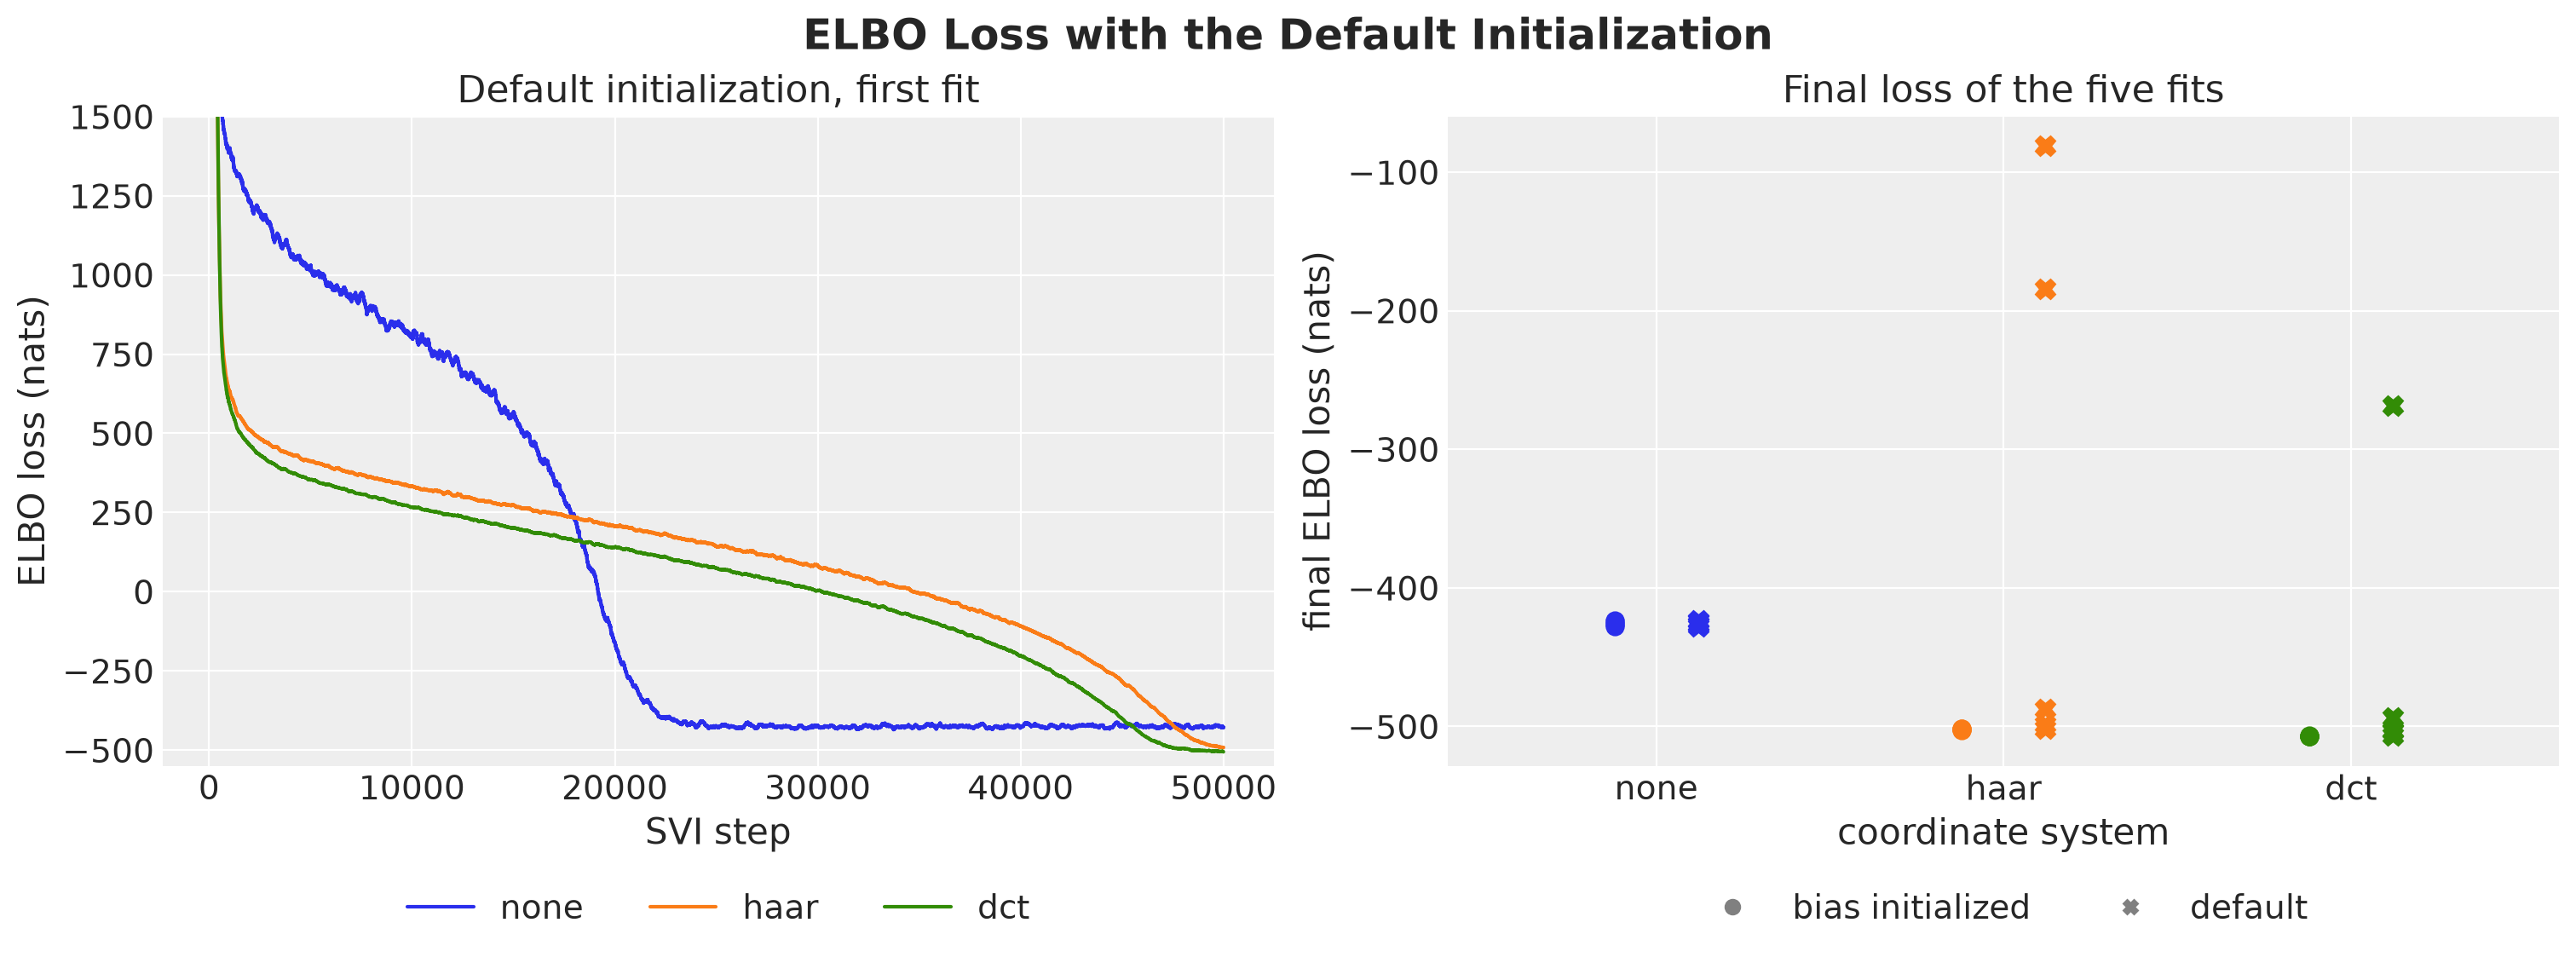

In [30]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5.5))
for position, name in enumerate(COLORS):
    axes[0].plot(
        steps,
        rolling_mean(default_fits[name][0].losses, window),
        color=COLORS[name],
        label=name,
    )
    axes[1].plot(
        np.full(len(svi_keys), position - 0.12),
        [final_loss(fit) for fit in svi_fits[name]],
        "o",
        color=COLORS[name],
        markersize=7,
    )
    axes[1].plot(
        np.full(len(svi_keys), position + 0.12),
        [final_loss(fit) for fit in default_fits[name]],
        "X",
        color=COLORS[name],
        markersize=8,
    )
axes[0].set(
    xlabel="SVI step",
    ylabel="ELBO loss (nats)",
    title="Default initialization, first fit",
    ylim=(-550, 1_500),
)
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
axes[1].set(
    xticks=np.arange(len(COLORS)),
    xticklabels=list(COLORS),
    xlim=(-0.6, 2.6),
    xlabel="coordinate system",
    ylabel="final ELBO loss (nats)",
    title="Final loss of the five fits",
)
axes[1].legend(
    handles=[
        Line2D(
            [], [], color="gray", marker="o", linestyle="", label="bias initialized"
        ),
        Line2D([], [], color="gray", marker="X", linestyle="", label="default"),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
)
fig.suptitle(
    "ELBO Loss with the Default Initialization", fontsize=18, fontweight="bold"
);

The left panel shows the three loss curves of the first fit with the default initialization. In the right panel each marker is the final loss of one fit: circles for the fits with `bias` initialized and crosses for the default initialization.

- **With `bias` initialized the result does not depend on the random key.** The five circles of each coordinate system are within $4$ nats of each other.
- **With the default initialization every fit needs many more steps.** In the original coordinates the five fits reach the same loss as before. The first one needs about $23500$ steps to come within $5$ nats of its final loss, instead of $4500$ with `bias` initialized.
- **The rotated fits are slower, and some do not finish.** In the first fit the DCT needs about $48500$ steps to come within $5$ nats of the loss with `bias` initialized, and the Haar fit ends $15$ nats above it. Two of the five Haar fits and one of the five DCT fits end more than $200$ nats above it.

The slow phase comes from the intercept: the only difference between the two sets of fits is the starting value of `bias`. We do not have an explanation for why the rotated coordinates are slower to recover from it.

The rotation changes the optimization problem, and a setup tuned for the original coordinates does not always transfer. With this optimizer, a good starting value for the intercept appears to be necessary in the rotated coordinates.

## NUTS Sampling

Next, we run NUTS on the three versions of the model, with $4$ chains and $1000$ draws per chain. The model is harder than the local level model, so we use $2000$ warmup steps, as the [comparison of inference methods](https://juanitorduz.github.io/numpyro_forecast/docs/examples/inference_methods_comparison.html) does. We use the same initialization of `bias`, and we repeat each run with three random keys. We measure the time per leapfrog step as in the local level model.

In [31]:
rng_key, *nuts_keys = random.split(rng_key, 4)
nuts_runs = {
    name: run_nuts(
        nuts_keys,
        NUTS(model, init_strategy=init_bias),
        2_000,
        covariates_train,
        y_train,
    )
    for name, model in models.items()
}
step_cost = {
    name: leapfrog_microseconds(
        NUTS(model, init_strategy=init_bias), 2_000, covariates_train, y_train
    )
    for name, model in models.items()
}

We look at the cost of the runs: the adapted step size, the number of leapfrog steps per draw, the time per leapfrog step, and the wall time of a complete run. The first run of each model includes the compilation, so we only show the wall time of the other two.

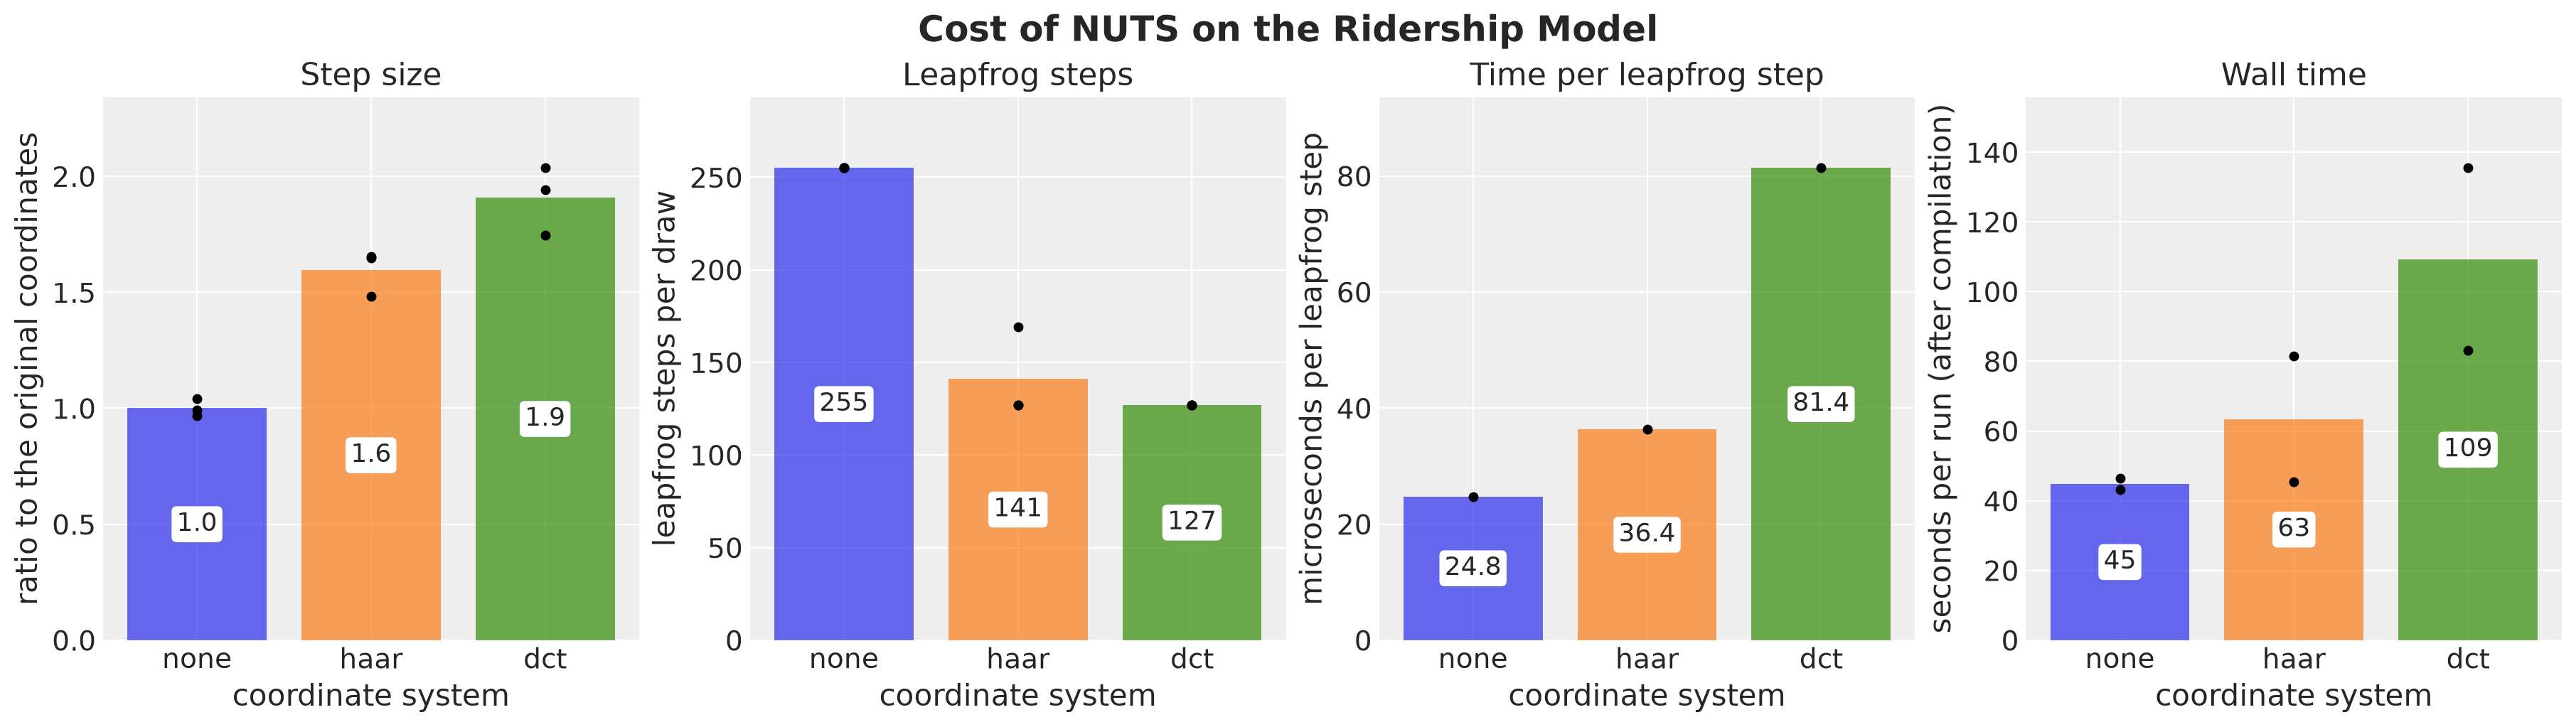

In [32]:
nuts_reference_step_size = np.mean([run.step_size for run in nuts_runs["none"]])

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(18, 5))
plot_runs(
    axes[0],
    {
        name: [run.step_size / nuts_reference_step_size for run in runs]
        for name, runs in nuts_runs.items()
    },
    fmt=".1f",
    title="Step size",
    ylabel="ratio to the original coordinates",
)
plot_runs(
    axes[1],
    {
        name: [leapfrog_per_draw(run) for run in runs]
        for name, runs in nuts_runs.items()
    },
    fmt=".0f",
    title="Leapfrog steps",
    ylabel="leapfrog steps per draw",
)
plot_runs(
    axes[2],
    {name: [cost] for name, cost in step_cost.items()},
    fmt=".1f",
    title="Time per leapfrog step",
    ylabel="microseconds per leapfrog step",
)
plot_runs(
    axes[3],
    {name: [run.seconds for run in runs[1:]] for name, runs in nuts_runs.items()},
    fmt=".0f",
    title="Wall time",
    ylabel="seconds per run (after compilation)",
)
fig.suptitle("Cost of NUTS on the Ridership Model", fontsize=18, fontweight="bold");

The figure has the same layout as for the local level model, with the wall time added.

- **The step size is larger in the rotated coordinates.** It grows by a factor of $1.6$ (Haar) and $1.9$ (DCT), much less than in the local level model.
- **The rotated runs take about half the leapfrog steps.** The original model needs $255$ steps per draw in every run, which is a full tree of depth $8$ ($2^8 - 1$ steps). The DCT model needs $127$ in every run, one level less, and the Haar model needs $127$ in two runs and $169$ in one.
- **A leapfrog step takes longer in the rotated coordinates.** About $1.5$ times longer with the Haar transform and $3.3$ times longer with the DCT. This model is small, so the transform is a large part of each gradient.
- **The wall time does not improve.** The original runs take about $45$ seconds. The Haar runs take the same time or more, and the DCT runs take about twice as long or more. These timings include the warmup and the parallel chains, and they vary between runs.

**Remark (series length):** The DCT uses a fast Fourier transform, and its cost depends on the factorization of the length of the series. Here $T = 417 = 3 \times 139$, and $139$ is a prime number. In a side experiment that we do not show, a gradient of the DCT version of the local level model takes about twice as long for $T = 417$ as for $T = 512$.

The reduction in steps is smaller than in the local level model. A likely reason is that the conditioning of this posterior does not come from the time axis alone: there are also the scales, the heavy tails and the regression.

Next, we check convergence. We plot the distribution of the bulk ESS and of $\hat{R}$ over the $417$ coordinates of `level` in the first run.

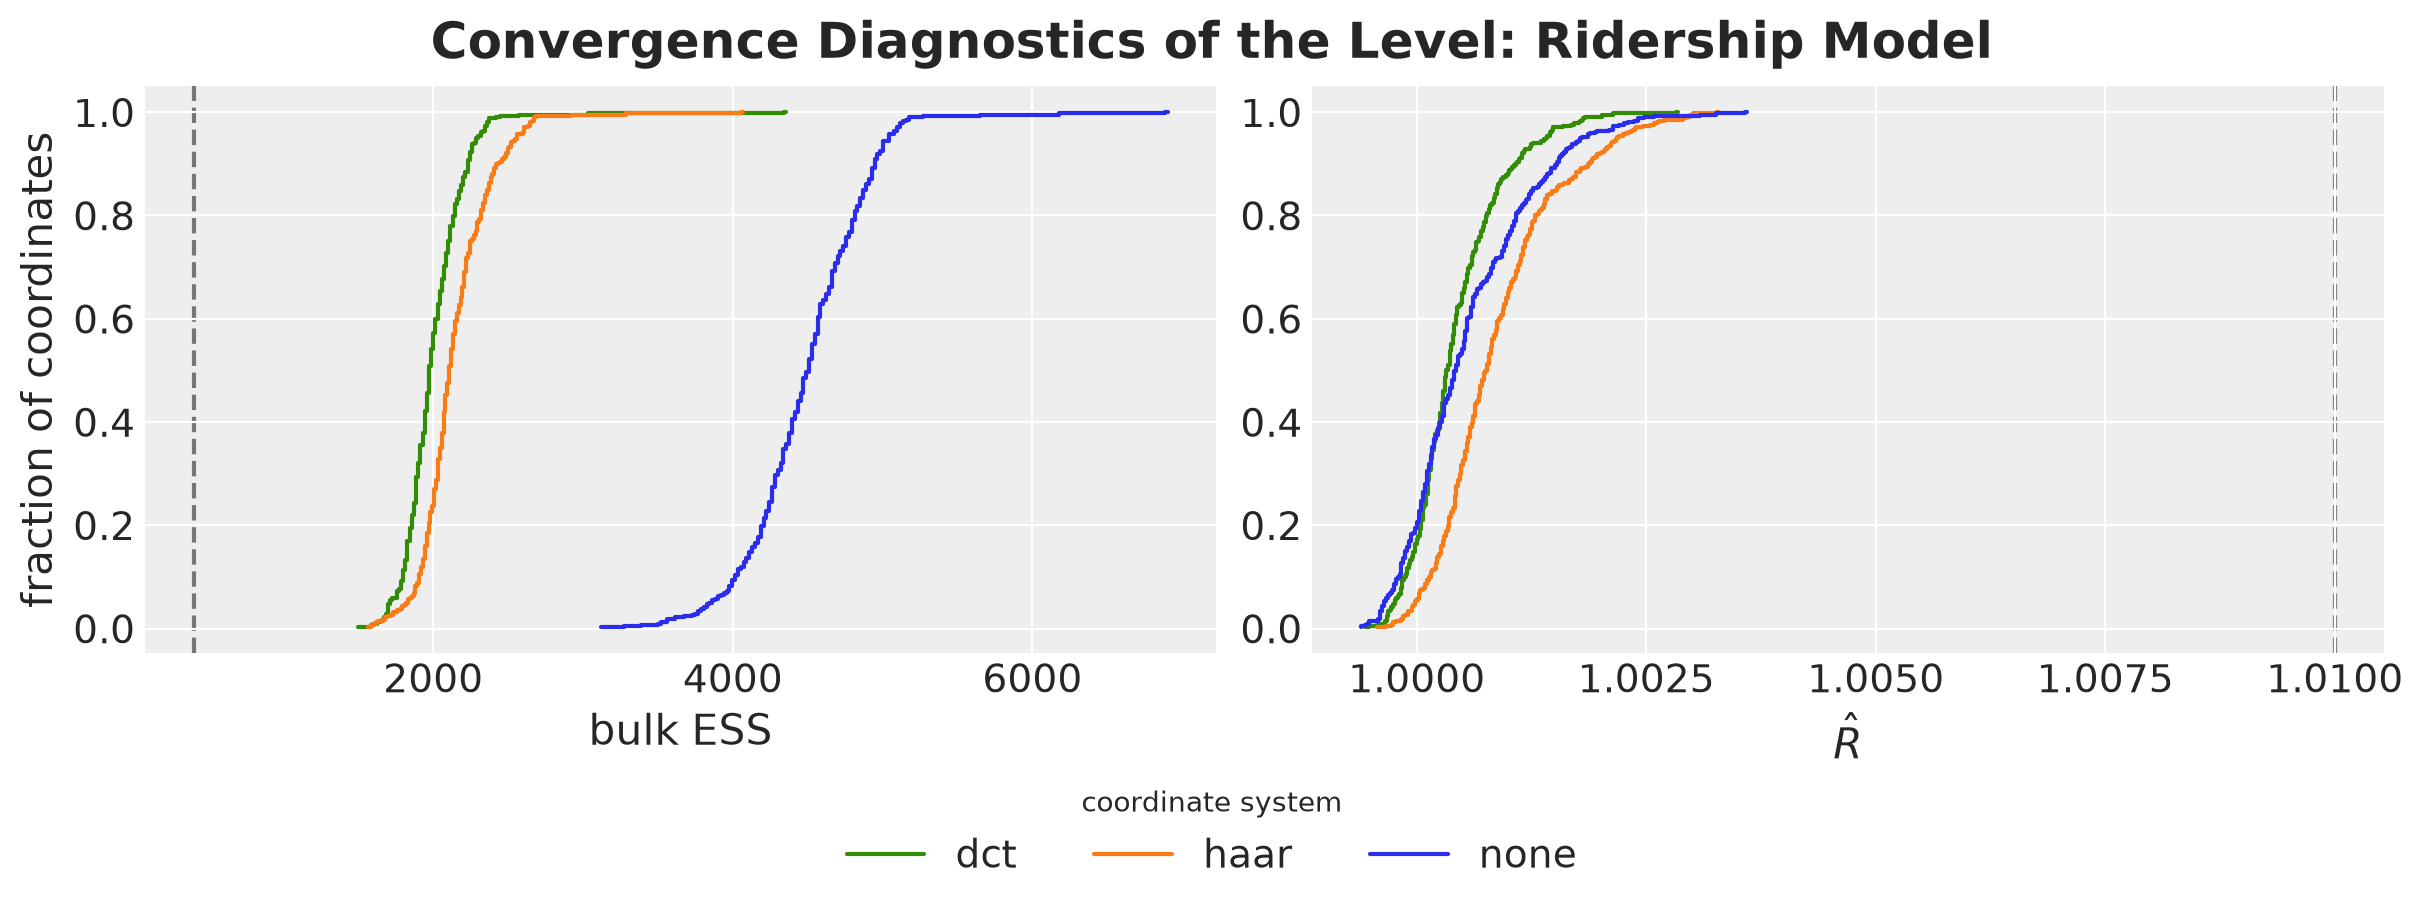

In [33]:
pc = az.plot_convergence_dist(
    {name: runs[0].idata for name, runs in nuts_runs.items()},
    var_names=["level"],
    diagnostics=list(diagnostic_labels),
    color=sorted_colors,
    figure_kwargs={"figsize": (12, 4.5)},
)
pc.add_legend("model", title="coordinate system", loc="outside lower center", ncols=3)
fig = label_panels(
    pc, "Convergence Diagnostics of the Level: Ridership Model", diagnostic_labels
)
fig.axes[0].set(ylabel="fraction of coordinates");

Each curve is the empirical cumulative distribution of one diagnostic over the coordinates of `level`, as in the local level model.

- **The diagnostics show no convergence problem.** The $\hat{R}$ values are below $1.01$ and the ESS values are above the threshold of $400$. Over the nine runs and all the parameters, the largest $\hat{R}$ is $1.012$, in one DCT run, and there are no divergences.
- **The ESS per draw is lower in the rotated runs.** The original model already samples well in the non-centered parameterization, with a median bulk ESS of about $4500$. The rotated runs have about $2000$.

The rotated runs use half the leapfrog steps and get about half the effective draws. The fair comparison is the ESS per unit of work. We compute the smallest bulk ESS of each parameter per $1000$ leapfrog steps, and we convert it to an ESS per second with the time per leapfrog step. As before, this conversion leaves out the warmup and the parallel overhead, which the wall times of the previous figure include.

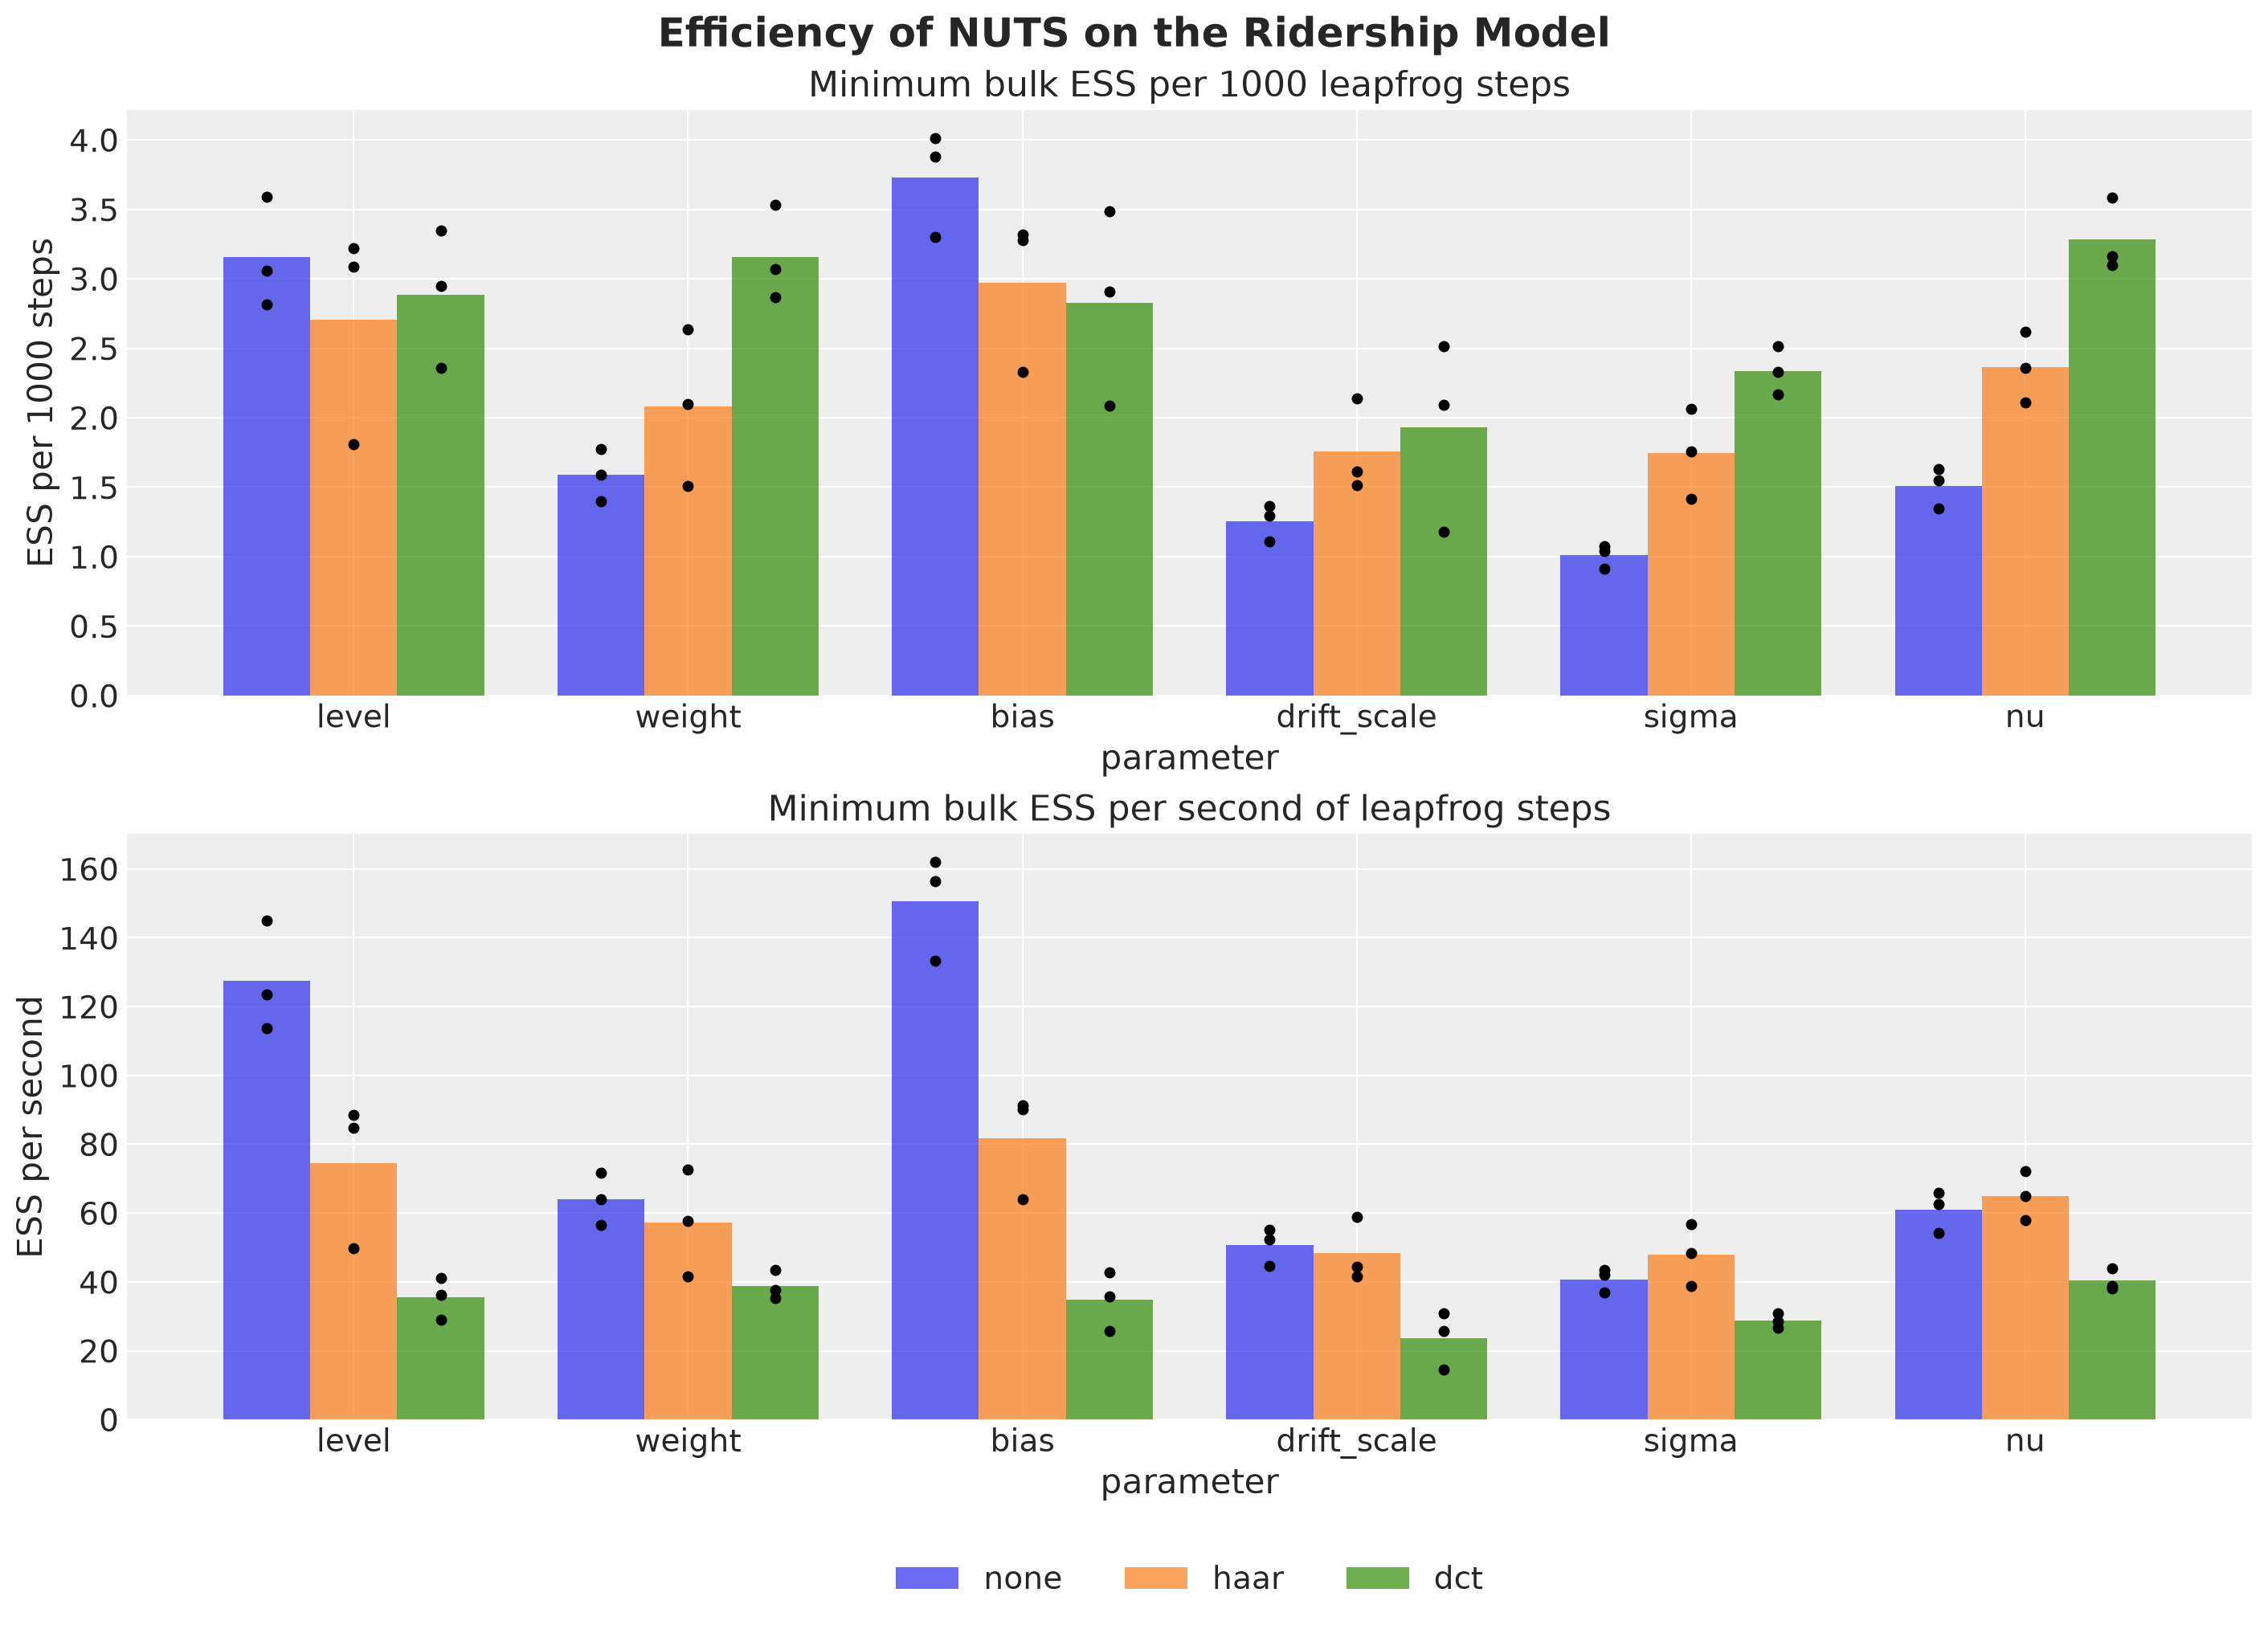

In [34]:
parameter_names = ["level", "weight", "bias", "drift_scale", "sigma", "nu"]
efficiency = {
    name: np.array(
        [
            [ess_per_1000_steps(run, parameter).min() for parameter in parameter_names]
            for run in runs
        ]
    )
    for name, runs in nuts_runs.items()
}

efficiency_per_second = {
    name: per_second(values, step_cost[name]) for name, values in efficiency.items()
}

width = 0.26
parameter_positions = np.arange(len(parameter_names))
efficiency_panels = {
    "Minimum bulk ESS per 1000 leapfrog steps": efficiency,
    "Minimum bulk ESS per second of leapfrog steps": efficiency_per_second,
}
efficiency_labels = ["ESS per 1000 steps", "ESS per second"]

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True)
for ax, (title, panel), label in zip(
    axes, efficiency_panels.items(), efficiency_labels, strict=True
):
    for i, (name, values) in enumerate(panel.items()):
        offset = (i - 1) * width
        ax.bar(
            parameter_positions + offset,
            values.mean(axis=0),
            width=width,
            color=COLORS[name],
            alpha=0.7,
            label=name,
        )
        for run_values in values:
            ax.plot(
                parameter_positions + offset,
                run_values,
                "o",
                color="black",
                markersize=4,
            )
    ax.tick_params(labelbottom=True)
    ax.set(
        xticks=parameter_positions,
        xticklabels=parameter_names,
        xlabel="parameter",
        ylabel=label,
        title=title,
    )
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3)
fig.suptitle(
    "Efficiency of NUTS on the Ridership Model", fontsize=18, fontweight="bold"
);

Each group is one parameter. Each bar is the smallest bulk ESS over the coordinates of that parameter, per $1000$ leapfrog steps after warmup (top) and per second of those steps (bottom), averaged over the three runs.

- **Per leapfrog step, the rotation helps the scales and the weights.** With the DCT, the efficiency of `weight`, `drift_scale`, `sigma` and `nu` is between $1.5$ and $2.3$ times the efficiency in the original coordinates. With the Haar transform it is between $1.3$ and $1.7$ times.
- **Per leapfrog step, there is no gain for the level and the intercept.** The efficiency of `level` is about $10\%$ lower in the rotated runs, and the efficiency of `bias` about $20\%$ lower.
- **Per second, most of the gain is gone.** With the Haar transform, `sigma` and `nu` are up to $20\%$ more efficient than in the original coordinates, `weight` and `drift_scale` up to $10\%$ less, and `level` and `bias` about half as efficient. With the DCT every parameter is between $1.4$ and $4.3$ times less efficient. The wall times are less favorable to the rotated runs still.
- **The per-second numbers are approximate.** The time per leapfrog step is a single measurement, and it changed by about $10\%$ between two executions of this notebook.

On this model the rotation does not make NUTS faster overall. NUTS already samples well in the original coordinates, and the cost of the transform is larger than the saving in leapfrog steps.

We also check that the runs agree, since they sample the same posterior. We use `az.plot_dist` to compare the marginal posteriors of three scalar parameters in the first run.

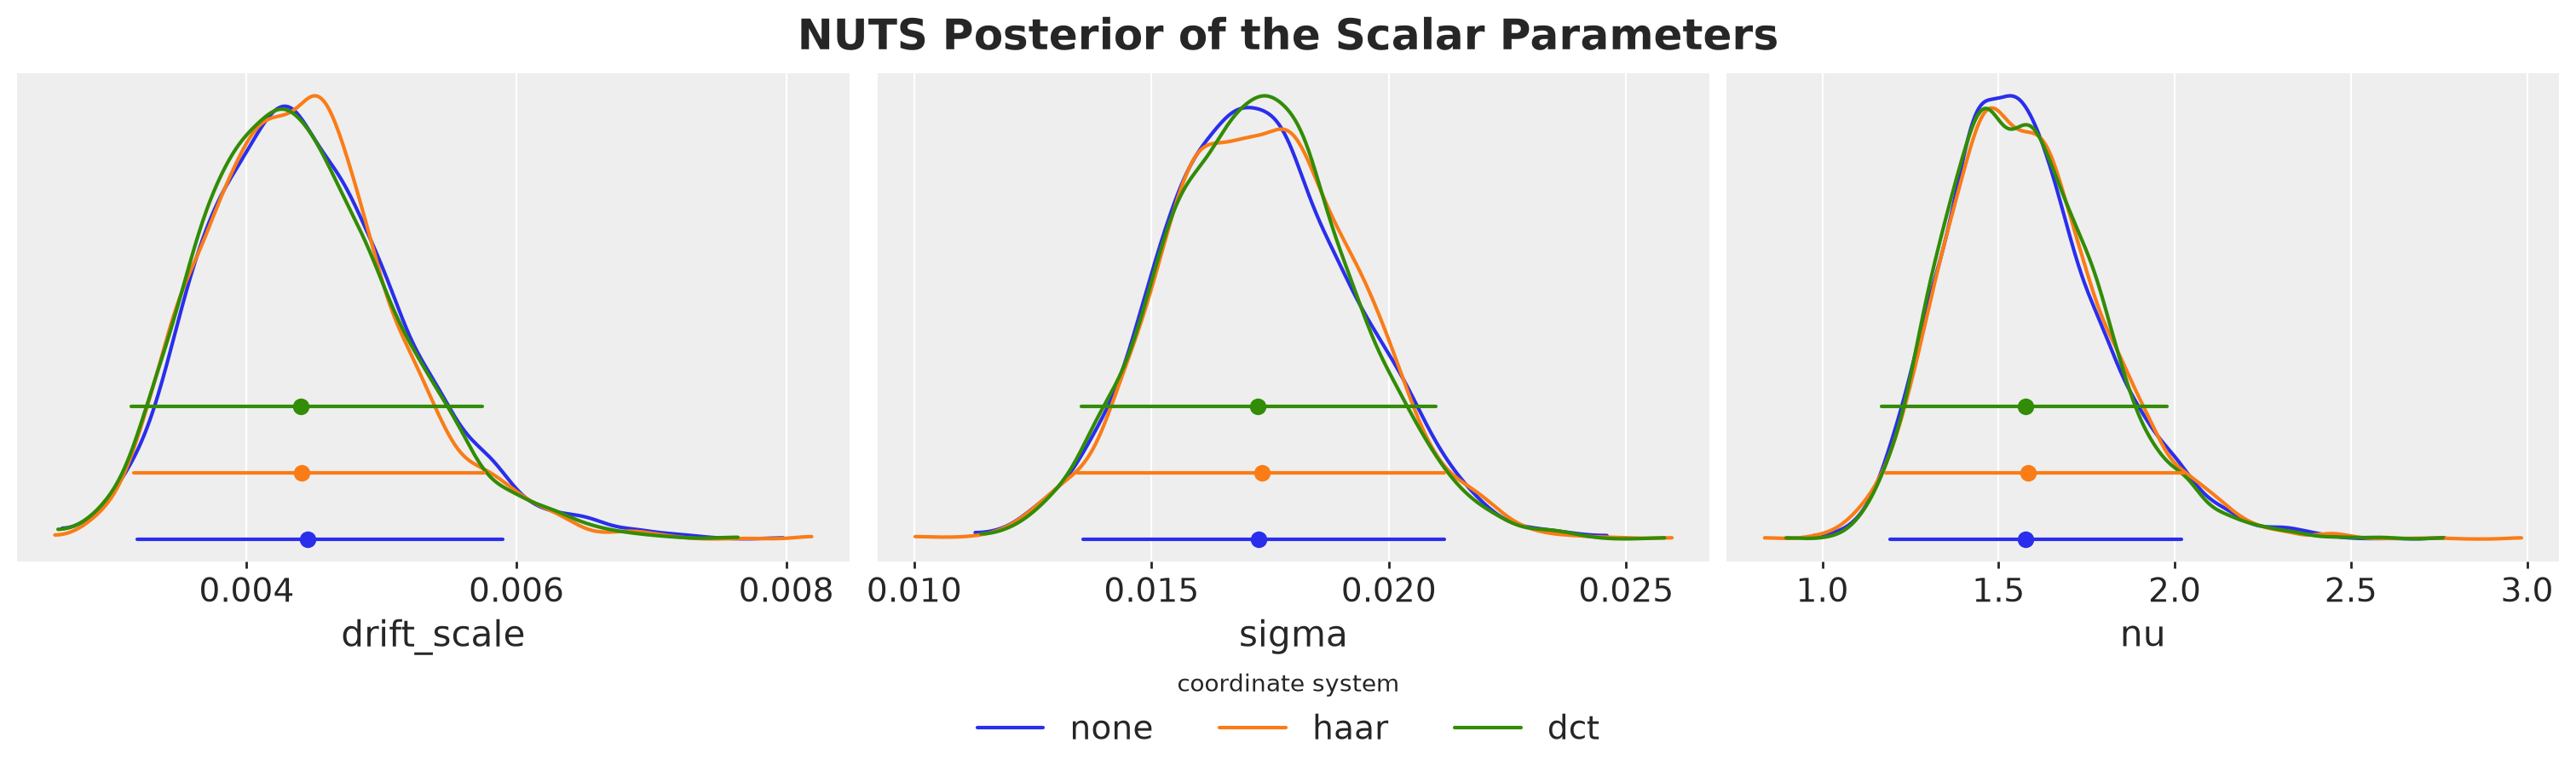

In [35]:
scalar_names = ["drift_scale", "sigma", "nu"]


def scalar_tree(samples: dict[str, Array]) -> DataTree:
    "Pack the draws of the scalar parameters as a single chain."
    return az.from_dict(
        {"posterior": {key: np.asarray(samples[key])[None] for key in scalar_names}}
    )


pc = az.plot_dist(
    {name: scalar_tree(runs[0].samples) for name, runs in nuts_runs.items()},
    var_names=scalar_names,
    visuals={"point_estimate_text": False},
    color=list(COLORS.values()),
    figure_kwargs={"figsize": (15, 4.5)},
)
pc.add_legend("model", title="coordinate system", loc="outside lower center", ncols=3)
label_panels(pc, "NUTS Posterior of the Scalar Parameters");

Each panel overlays the posterior density of one parameter in the three coordinate systems. The points and the lines below the densities are the means and the $94\%$ highest density intervals (HDI).

- **The three posteriors agree.** The densities overlap for the three parameters, as they must for a change of coordinates with unit Jacobian.
- **The likelihood is heavy-tailed.** The degrees of freedom `nu` are around $1.6$, far from a Gaussian likelihood.

**Remark (secondary mode):** The Student-T likelihood makes this posterior multimodal. In a larger sweep of random keys that we do not show here, one chain out of $60$ stayed in a secondary mode for the whole run, with different regression weights and an $\hat{R}$ of about $1.5$. Check $\hat{R}$ on every run.

## Posterior and Forecast Comparison

We now use NUTS as the reference to judge the variational fits. We draw $4000$ samples from each fitted guide with `draw_posterior`. The reference is the first NUTS run in the original coordinates.

In [36]:
rng_key, rng_subkey = random.split(rng_key)
svi_posteriors = {
    name: [draw_posterior(rng_subkey, fit.guide, fit.params, 4_000) for fit in fits]
    for name, fits in svi_fits.items()
}
nuts_reference = nuts_runs["none"][0].samples

FIT_COLORS = {"NUTS": "black"} | {
    f"SVI: {name}": color for name, color in COLORS.items()
}

scalar_idatas = {"NUTS": scalar_tree(nuts_reference)} | {
    f"SVI: {name}": scalar_tree(posteriors[0])
    for name, posteriors in svi_posteriors.items()
}

First, we compare the marginal posteriors of the scalar parameters for the first fit. The variational posteriors of `drift_scale` are very narrow, so we plot cumulative distributions, which stay readable when the widths differ.

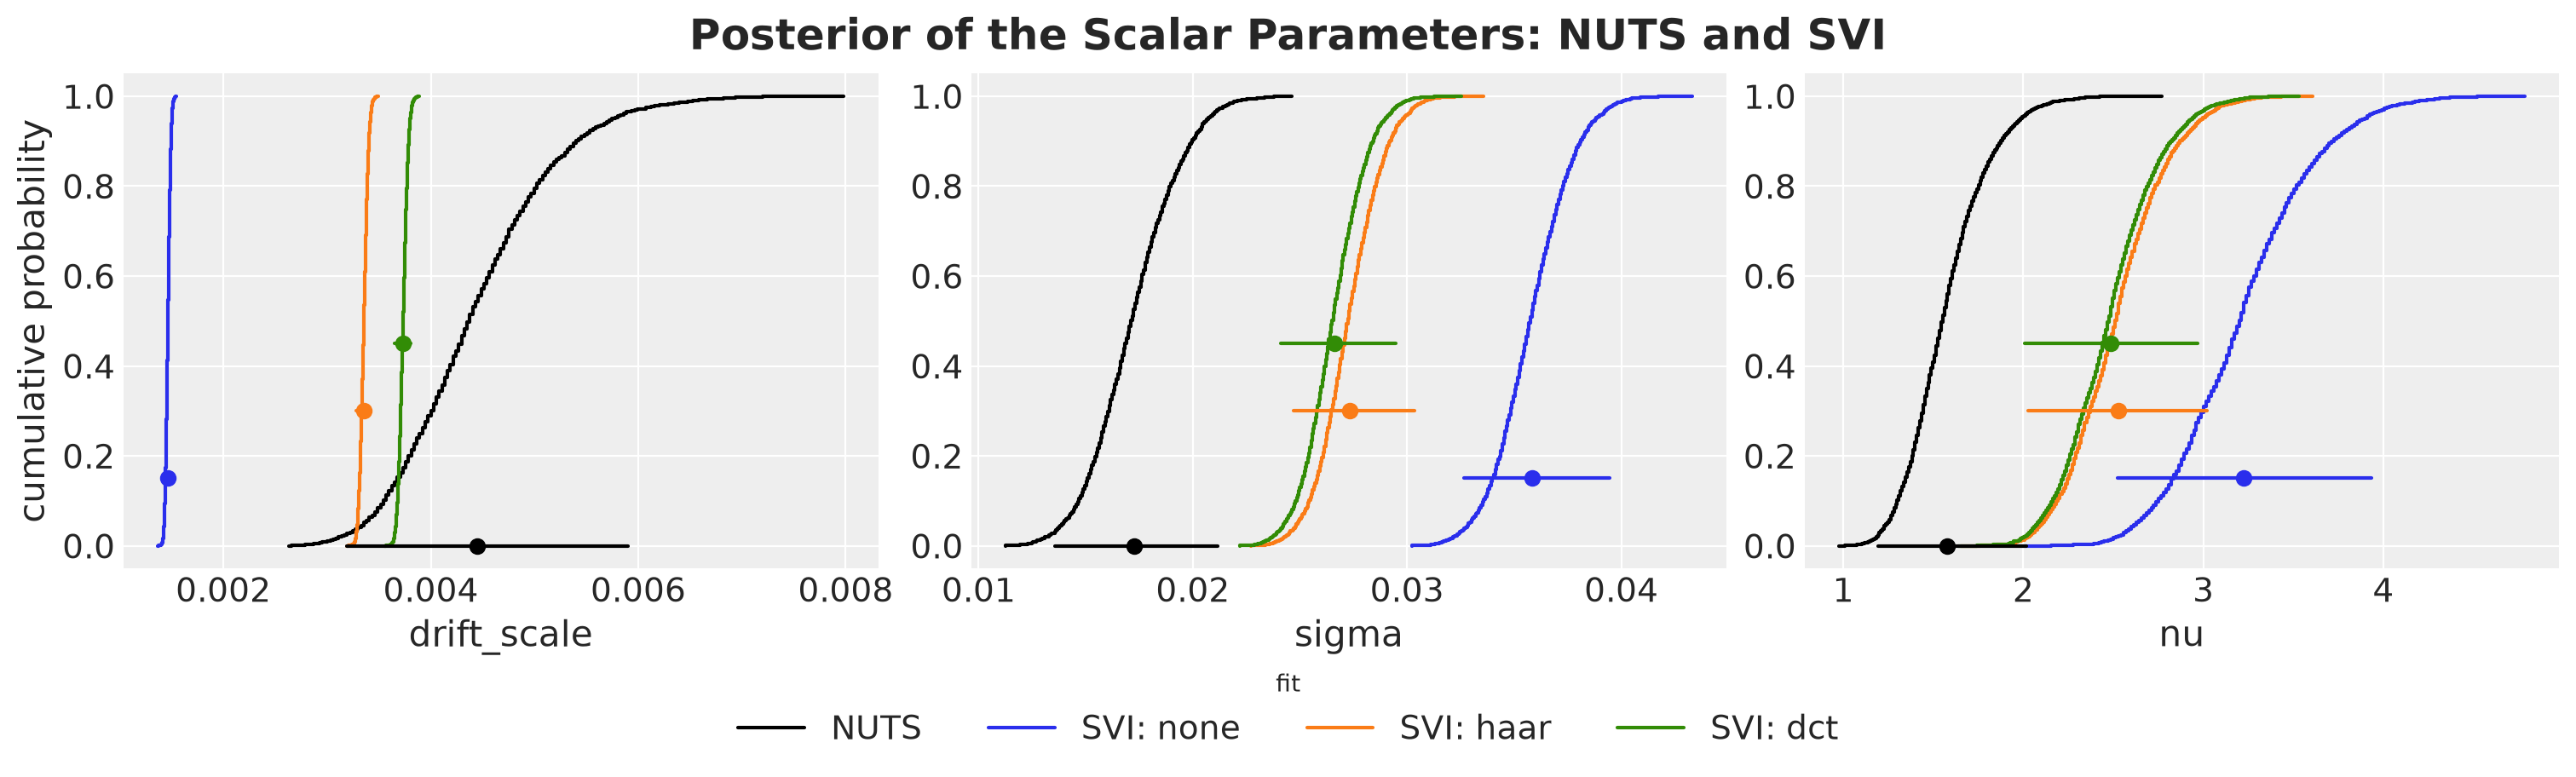

In [37]:
pc = az.plot_dist(
    scalar_idatas,
    var_names=scalar_names,
    kind="ecdf",
    visuals={"point_estimate_text": False},
    color=list(FIT_COLORS.values()),
    figure_kwargs={"figsize": (15, 4.5)},
)
pc.add_legend("model", title="fit", loc="outside lower center", ncols=4)
fig = label_panels(pc, "Posterior of the Scalar Parameters: NUTS and SVI")
fig.axes[0].set(ylabel="cumulative probability");

Each curve is the empirical cumulative distribution of the draws of one fit. A steep curve is a narrow posterior.

The points and the lines are the means and the $94\%$ HDIs. The black curve is the NUTS reference.

- **In the original coordinates the fit shrinks the level.** The scale of the increments `drift_scale` is three times smaller than the NUTS mean, and the noise scale `sigma` is about twice as large. This is the pattern of the local level model with unknown scales.
- **The rotated fits are much closer to NUTS.** Their estimates of `drift_scale` are inside the NUTS interval, and `sigma` and `nu` move about halfway toward the reference.
- **A difference remains.** The values of `sigma` and `nu` are still above the reference, and the variational posterior of `drift_scale` is about $20$ times narrower than the NUTS one. A mean-field guide also ignores the dependence between the global parameters and the latent path, and the rotation does not help there.

Next, we compare the posterior of the level, which is the quantity that the forecast extends. We plot its posterior mean and its posterior standard deviation by week.

Can the Gaussian computation of the local level model explain the standard deviations of the fitted guides? The ridership model has an intercept $b$, which enters the mean only through the sum $b + \ell_t$. We add it to the Gaussian model, with its prior $\text{Normal}(0, 10)$, and we leave out the seasonal regression.

For each fit we compute the level standard deviation under the best mean-field guide, at the scales of that fit and in its coordinate system. In the original coordinates the intercept does not change the result, which is the formula $\sigma^2 \log\left(a / (a - t)\right)$ for the variance.

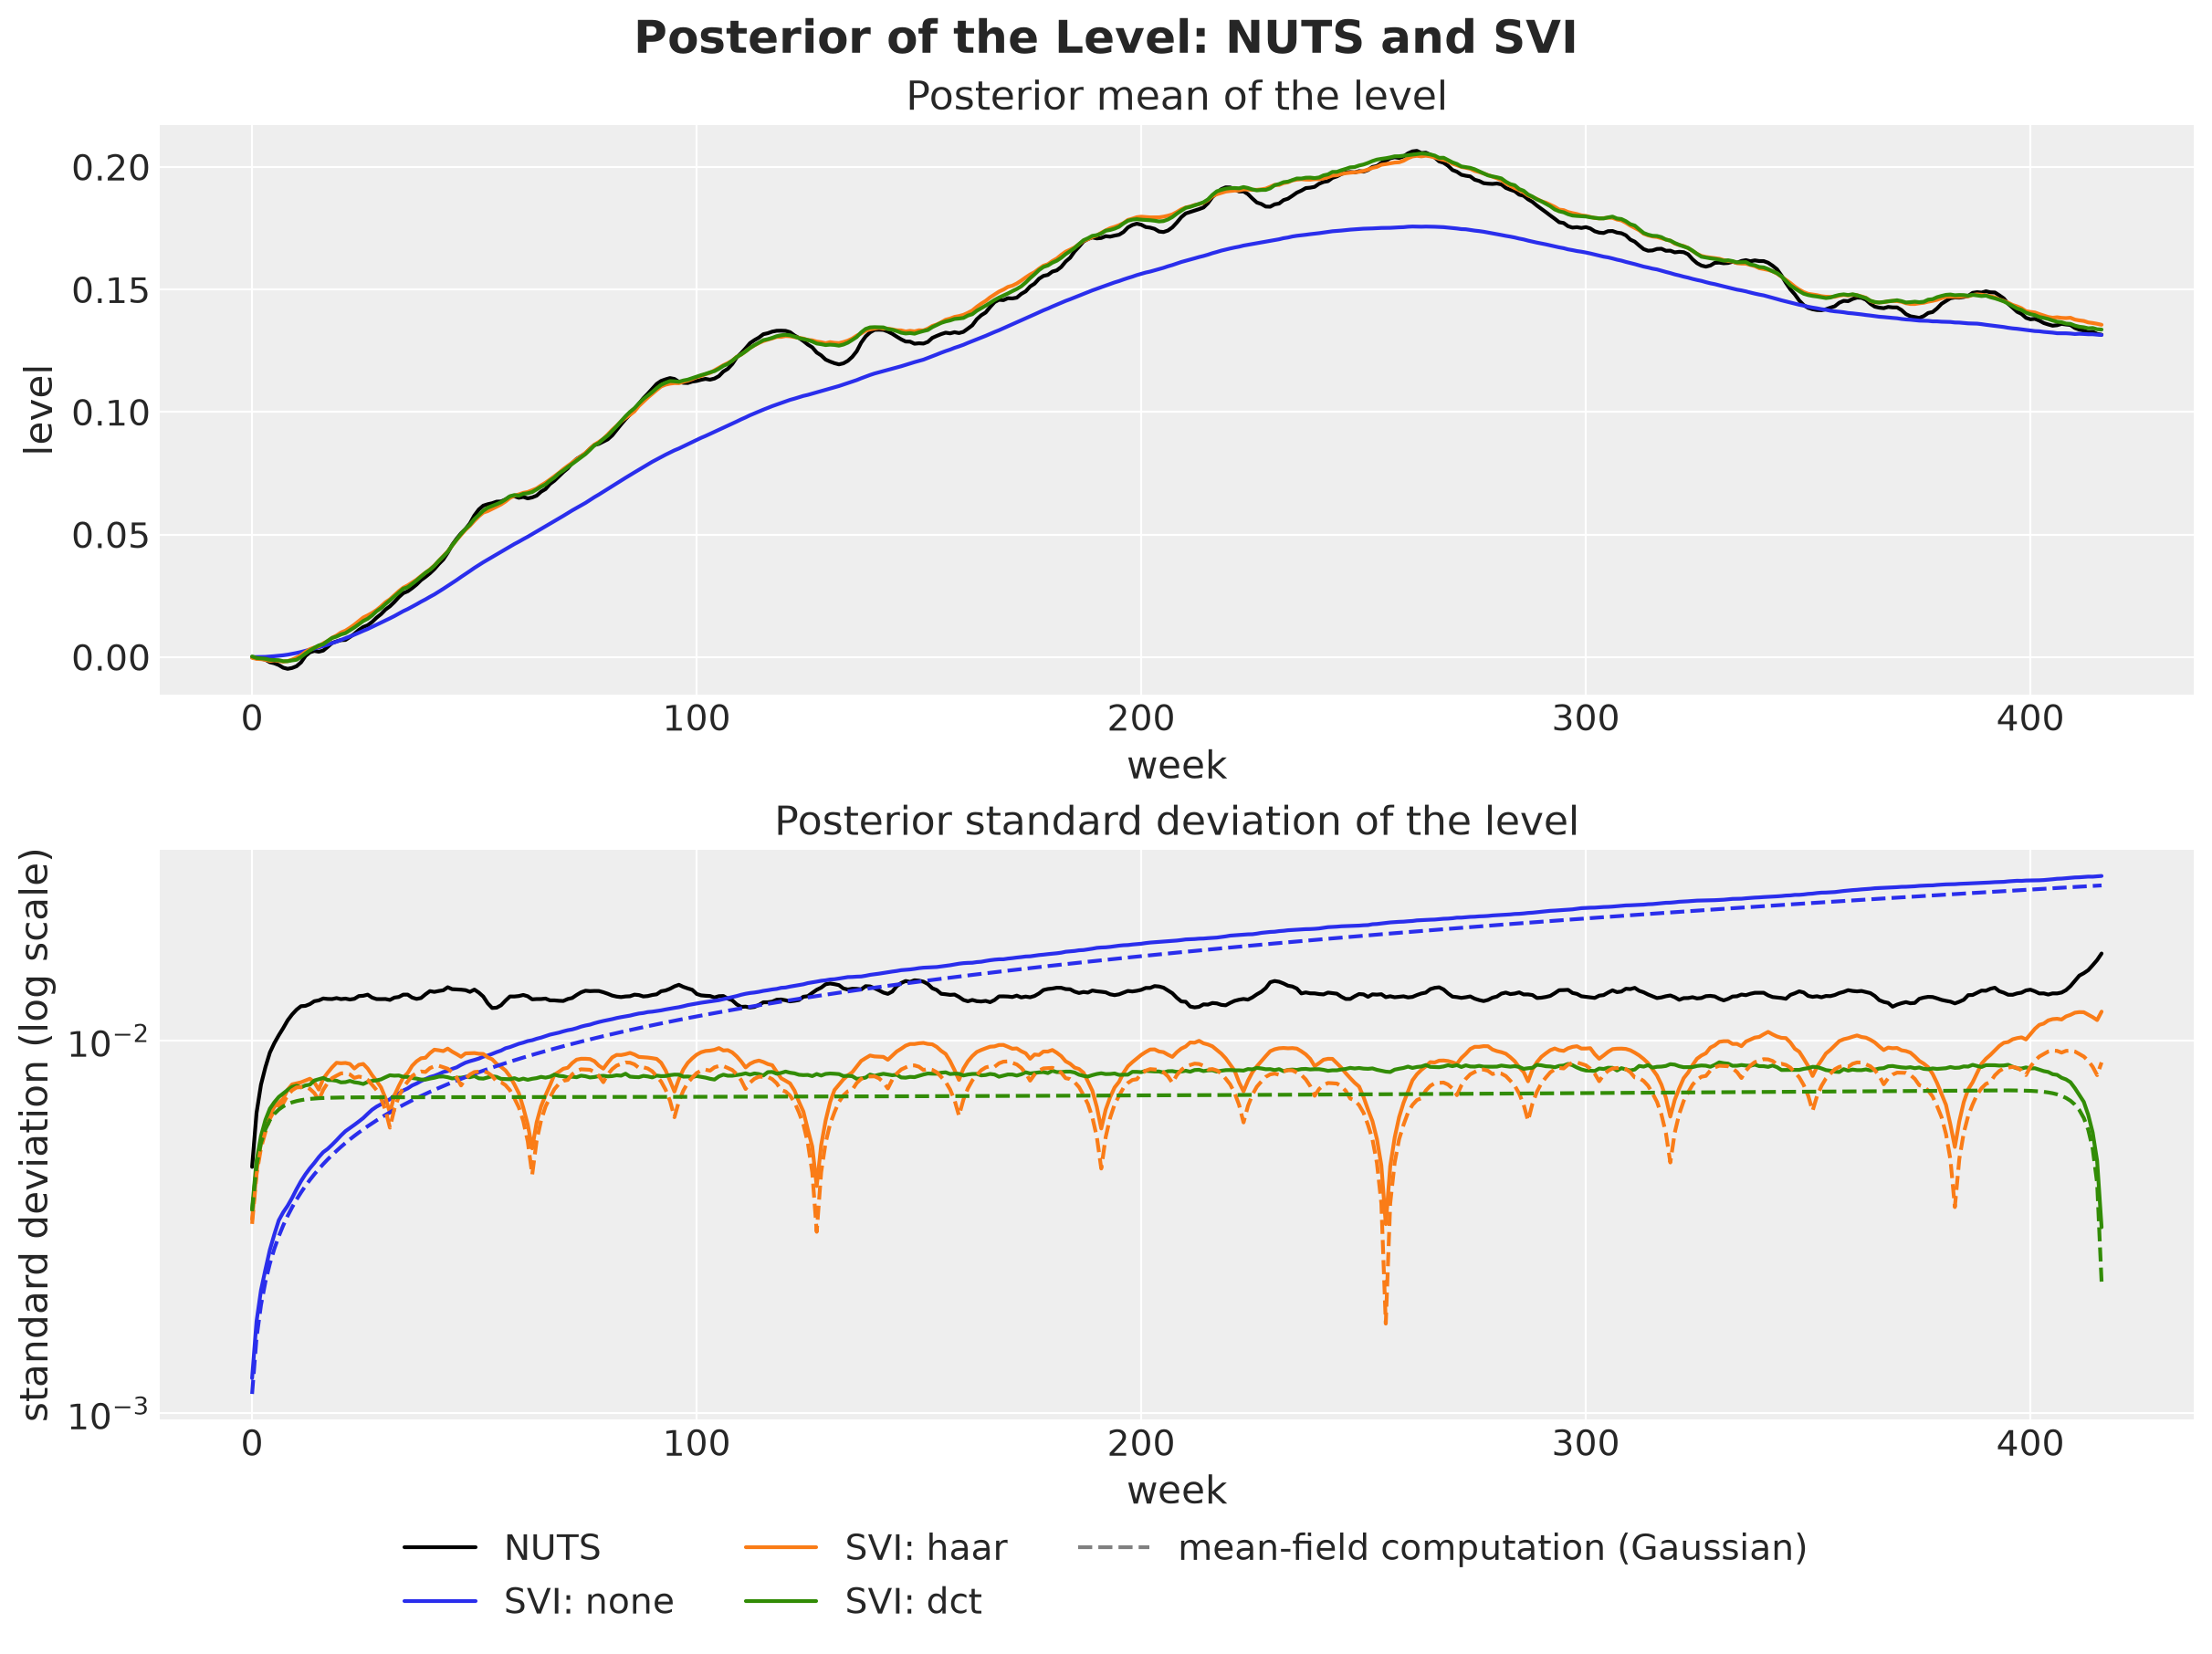

In [38]:
level_draws = {"NUTS": np.asarray(nuts_reference["level"])[..., 0]} | {
    f"SVI: {name}": np.asarray(posteriors[0]["level"])[..., 0]
    for name, posteriors in svi_posteriors.items()
}


def mean_field_level_sd_with_intercept(
    drift_scale: float, sigma: float, rotation: np.ndarray
) -> np.ndarray:
    "Level sd under the best mean-field guide of a Gaussian local level with intercept."
    t_obs = rotation.shape[0]
    cumsum = np.tril(np.ones((t_obs, t_obs)))
    # The latent variables are the intercept and the standardized increments.
    design = np.hstack([np.ones((t_obs, 1)), drift_scale * cumsum])
    prior_precision = np.diag(np.r_[1 / 10.0**2, np.ones(t_obs)])
    precision = prior_precision + design.T @ design / sigma**2
    full_rotation = np.eye(t_obs + 1)
    full_rotation[1:, 1:] = rotation
    covariance = mean_field_covariance(precision, full_rotation)[1:, 1:]
    return drift_scale * np.sqrt(np.diag(cumsum @ covariance @ cumsum.T))


ridership_rotations = {
    "none": np.eye(t_train),
    "haar": transform_matrix(HaarTransform(dim=-1), t_train),
    "dct": transform_matrix(DiscreteCosineTransform(dim=-1), t_train),
}
predicted_level_sd = {
    f"SVI: {name}": mean_field_level_sd_with_intercept(
        float(svi_posteriors[name][0]["drift_scale"].mean()),
        float(svi_posteriors[name][0]["sigma"].mean()),
        rotation,
    )
    for name, rotation in ridership_rotations.items()
}

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 9), sharex=True)
for name, color in FIT_COLORS.items():
    axes[0].plot(weeks_train, level_draws[name].mean(axis=0), color=color, label=name)
    axes[1].plot(weeks_train, level_draws[name].std(axis=0), color=color)
for name, values in predicted_level_sd.items():
    axes[1].plot(weeks_train, values, color=FIT_COLORS[name], linestyle="--")
axes[1].plot(
    [], [], color="gray", linestyle="--", label="mean-field computation (Gaussian)"
)
axes[0].tick_params(labelbottom=True)
axes[0].set(xlabel="week", ylabel="level", title="Posterior mean of the level")
axes[1].set(
    yscale="log",
    xlabel="week",
    ylabel="standard deviation (log scale)",
    title="Posterior standard deviation of the level",
)
fig.legend(loc="outside lower center", ncol=3)
fig.suptitle("Posterior of the Level: NUTS and SVI", fontsize=18, fontweight="bold");

The top panel is the posterior mean of the level and the bottom panel its posterior standard deviation, on a log scale. The dashed lines are the Gaussian mean-field computation for each fit, in the color of that fit.

- **The rotated fits recover the path of the level.** Their posterior means follow the NUTS reference. The fit in the original coordinates gives a smoother path that misses the turns.
- **In the original coordinates the uncertainty accumulates.** The standard deviation starts near zero and keeps growing, while the reference is flat after the first weeks.
- **The rotated fits have a flat profile, and it is too low.** The DCT profile is about $40\%$ below the reference, and the Haar profile about $30\%$.
- **The DCT fit collapses in the last weeks.** In the last week its standard deviation is $0.003$, against $0.017$ for NUTS. The deepest Haar dip is at week $256$, the end of the first Haar block, where the level depends on the coefficient $z_0$ alone. For $T = 417$ the Haar fit does not collapse at the end.
- **The Gaussian computation follows each fit.** The dashed lines reproduce the three profiles, about $10\%$ below the fitted guides: the growth in the original coordinates, the flat level of the rotated fits, the Haar dips and the DCT collapse.

The intercept explains the flat shortfall. The data determine the sum $b + \ell_t$ much better than each term, so the exact posterior has a strong negative dependence between the intercept and the level. A mean-field guide cannot represent it, and in the rotated coordinates it makes the level too certain everywhere.

Without the intercept, the same computation gives a DCT profile within a few percent of the exact one away from the end, as in the local level model.

Finally, we look at the forecasts. We generate the in-sample predictions and the $52$-week forecast of every fit and of every NUTS run in the original coordinates.

We score them with the continuous ranked probability score (CRPS), where lower is better. For an introduction to this score see [Intuition behind CRPS](https://juanitorduz.github.io/crps/).

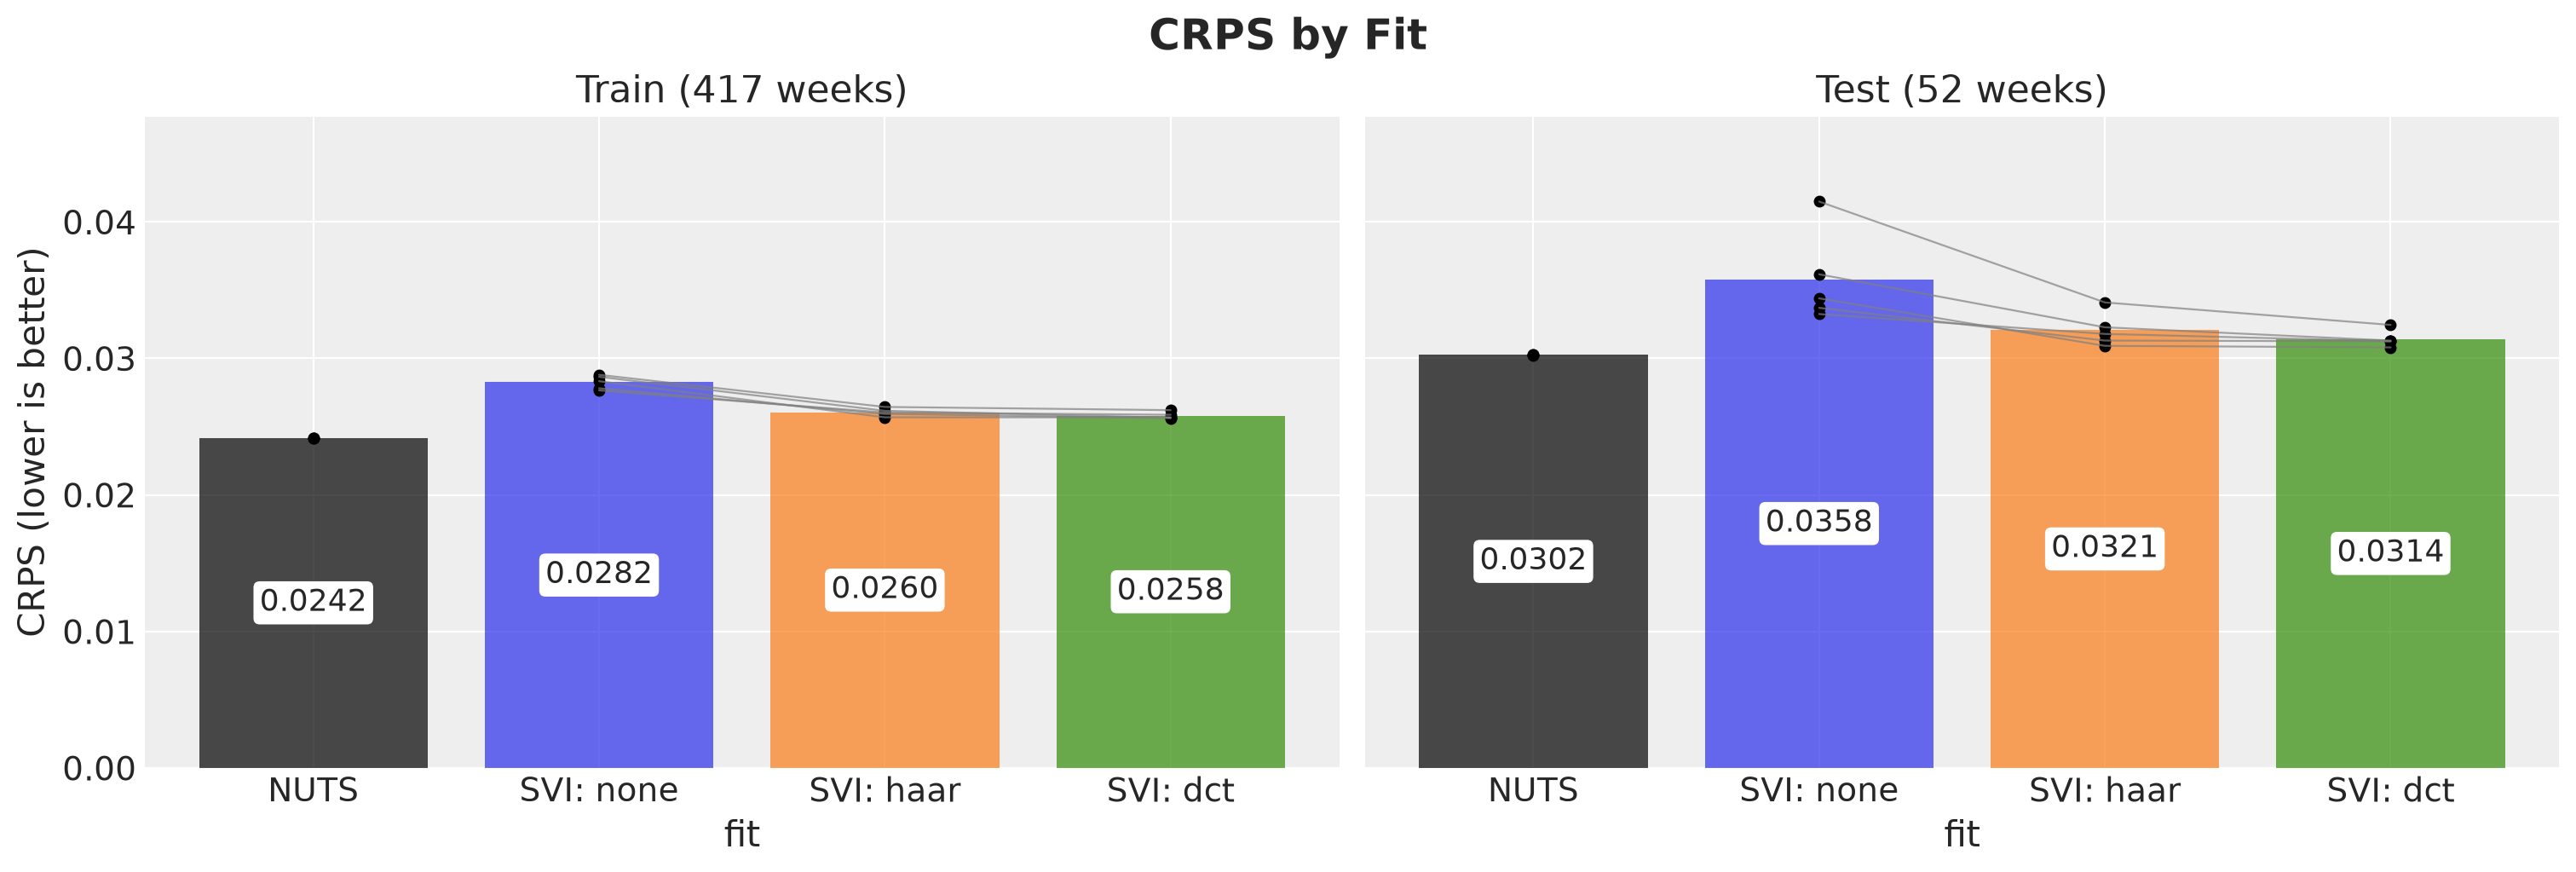

In [39]:
def score(
    rng_key: Array, model: Model, posterior: dict[str, Array]
) -> tuple[float, float, Array]:
    "Train CRPS, test CRPS and forecast draws of a posterior."
    key_train, key_test = random.split(rng_key)
    in_sample = predict_in_sample(key_train, model, posterior, covariates_train)
    forecast_draws = forecast(key_test, model, posterior, y_train, covariates)
    return (
        float(eval_crps(in_sample, y_train)),
        float(eval_crps(forecast_draws, y_test)),
        forecast_draws,
    )


rng_key, rng_subkey = random.split(rng_key)
scores = {
    "NUTS": [
        score(rng_subkey, models["none"], run.samples) for run in nuts_runs["none"]
    ]
} | {
    f"SVI: {name}": [
        score(rng_subkey, models[name], posterior) for posterior in posteriors
    ]
    for name, posteriors in svi_posteriors.items()
}

svi_fit_names = [name for name in scores if name != "NUTS"]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5), sharey=True)
for i, (ax, title) in enumerate(
    zip(axes, ["Train (417 weeks)", "Test (52 weeks)"], strict=True)
):
    plot_runs(
        ax,
        {name: [run[i] for run in runs] for name, runs in scores.items()},
        fmt=".4f",
        title=title,
        ylabel="CRPS (lower is better)",
        colors=FIT_COLORS,
        xlabel="fit",
    )
    # Join the SVI fits that share a random key.
    for key_index in range(len(svi_keys)):
        ax.plot(
            np.arange(1, len(svi_fit_names) + 1),
            [scores[name][key_index][i] for name in svi_fit_names],
            color="gray",
            linewidth=0.8,
            alpha=0.7,
        )
axes[1].set(ylabel="")
fig.suptitle("CRPS by Fit", fontsize=18, fontweight="bold");

The left panel is the in-sample score and the right panel is the score on the held-out year. Each bar is the mean over the fits (five for SVI, three for NUTS), and each black point is one fit. The thin gray lines join the SVI fits with the same random key.

- **The rotated fits have a better in-sample score.** Their train CRPS is $0.026$, between the $0.028$ of the original coordinates and the $0.024$ of NUTS.
- **The rotated fits forecast better on this split.** The mean test CRPS goes from $0.036$ in the original coordinates to $0.032$ (Haar) and $0.031$ (DCT), which is about $10\%$ lower. For each of the five random keys both rotated fits have a lower score than the original fit. The NUTS score is $0.030$.
- **Haar and DCT are close.** The difference between their means is smaller than the spread over the random keys.
- **The spread over the random keys is not negligible.** The optimizer has a constant step size, so the last iterate is noisy, most of all in the original coordinates, where the test CRPS varies between $0.033$ and $0.041$.

This is one split of one series. It supports the direction of the effect and not a precise size.

We end with the forecasts themselves. We use `az.plot_lm` to plot the forecast of the NUTS reference, of the first fit in the original coordinates, and of the first DCT fit.

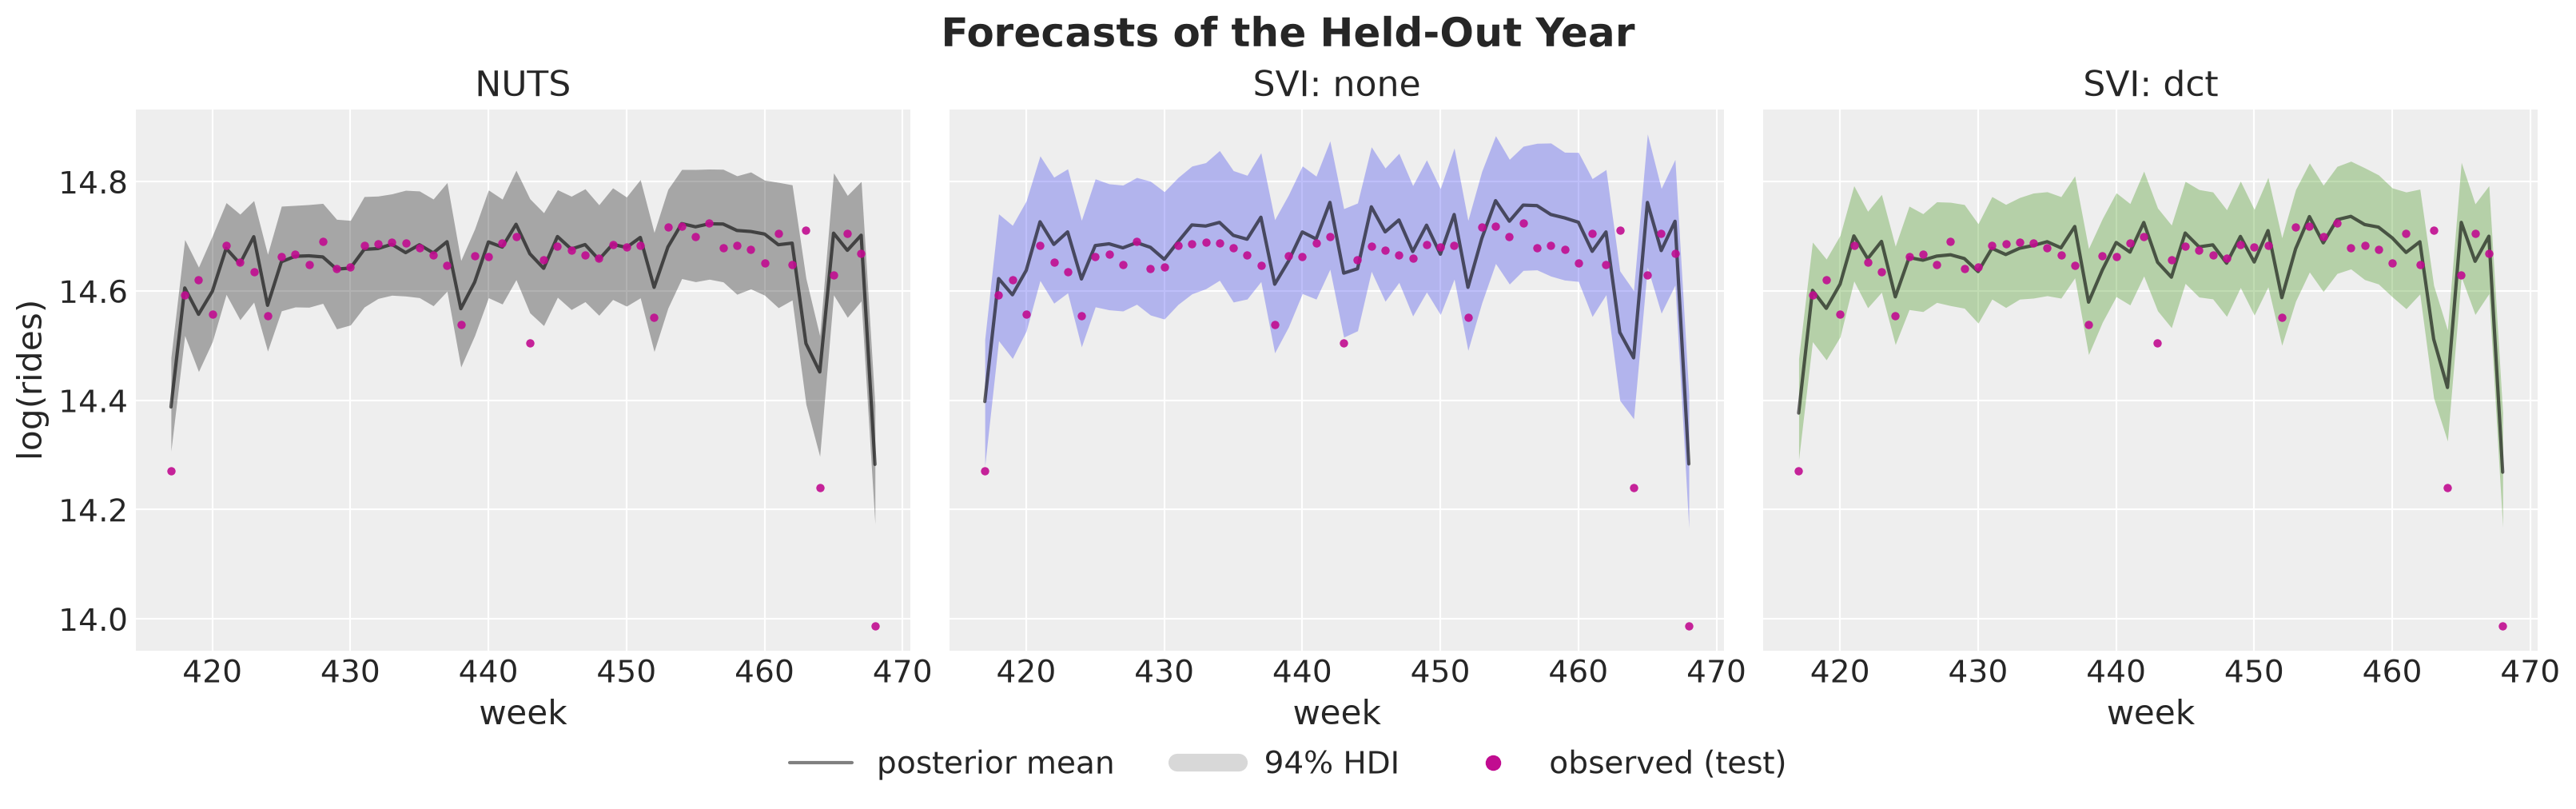

In [40]:
forecast_fits = ["NUTS", "SVI: none", "SVI: dct"]

# `az.plot_lm` draws one panel per variable, and each variable needs its own x variable.
# The three fits have the same number of draws.
forecast_tree = az.from_dict(
    {
        "posterior_predictive": {
            name: np.asarray(scores[name][0][2][..., 0])[None] for name in forecast_fits
        },
        "observed_data": {name: np.asarray(y_test[:, 0]) for name in forecast_fits},
        "constant_data": {
            f"week ({name})": weeks_test.astype(float) for name in forecast_fits
        },
    },
    coords={"time": weeks_test},
    dims={name: ["time"] for name in forecast_fits}
    | {f"week ({name})": ["time"] for name in forecast_fits},
)

pc = az.plot_lm(
    forecast_tree,
    y=forecast_fits,
    x=[f"week ({name})" for name in forecast_fits],
    ci_kind="hdi",
    ci_prob=HDI_PROB,
    smooth=False,
    color=[FIT_COLORS[name] for name in forecast_fits],
    visuals={
        "ci_band": {"alpha": 0.3},
        "observed_scatter": {"color": "C3", "s": 14, "alpha": 0.9},
    },
    figure_kwargs={"figsize": (16, 5), "sharey": True},
)
fig = pc.viz["figure"].item()
for ax, name in zip(fig.axes, forecast_fits, strict=True):
    ax.set(xlabel="week", ylabel="", title=name)
fig.axes[0].set(ylabel="log(rides)")
fig.legend(
    handles=[
        Line2D([], [], color="gray", label="posterior mean"),
        Line2D([], [], color="gray", linewidth=8, alpha=0.3, label="$94\\%$ HDI"),
        Line2D([], [], color="C3", marker="o", linestyle="", label="observed (test)"),
    ],
    loc="outside lower center",
    ncol=3,
)
fig.suptitle("Forecasts of the Held-Out Year", fontsize=18, fontweight="bold");

Each panel is the forecast of one fit for the $52$ held-out weeks. The line is the posterior mean, the band is the $94\%$ HDI and the points are the observations.

- **The three forecasts follow the seasonal pattern.** The regression on the Fourier features does this part in every fit.
- **The DCT forecast is closer to the NUTS forecast.** The mean of the fit in the original coordinates is above the observations for a good part of the year, and its band is wider, consistent with its larger noise scale `sigma`.
- **The holiday weeks are outside every band.** The heavy-tailed likelihood treats them as outliers.

## Conclusion

We studied the Haar and DCT reparameterizations of time-indexed latent variables: what they are, why they help, and how NumPyro implements them.

### Key Findings

- **It is a rotation, not a new model.** The reparameterization samples the coefficients of the latent variables in an orthonormal basis. The Jacobian determinant is one, so the log density is the same and only the coordinates change.
- **The posterior of a random walk is coupled along time.** The data constrain the smooth combinations of the increments and leave the oscillating ones at the prior. The condition number of the posterior precision grows with the square of the length of the series.
- **The gain for mean-field SVI is large.** In the local level model the gap of the best mean-field guide drops from $187$ nats to $7.4$ (Haar) and $1.4$ (DCT), and fitted guides reproduce these numbers. In the ridership model the ELBO improves by about $75$ (Haar) and $80$ (DCT) nats for every random key, the scale estimates move toward the NUTS reference, and the test CRPS improves by about $10\%$.
- **The errors of the mean-field guide are predictable.** In the original coordinates the uncertainty of the level accumulates along the series and the scale of the increments is too small. In the rotated coordinates the coarse coefficients stay coupled: the level is too certain at the end of the series with the DCT and at the ends of the Haar blocks. With an intercept the level is too certain everywhere. A Gaussian computation at the fitted scales reproduces the level uncertainty of the fitted guides in the ridership model.
- **For NUTS the rotation saves leapfrog steps, and the net gain depends on the cost of the transform.** In the local level model the sampler needs about four times fewer leapfrog steps, as the conditioning argument predicts, and the Haar basis is about $2.7$ times more efficient per second on the worst coordinate. In the ridership model the sampler needs half the steps, each step costs more, and there is no overall gain per second.

### Model Limitations

- **The theory is Gaussian.** The exact results are for a Gaussian model with fixed scales. With unknown scales and a heavy-tailed likelihood they give the direction of the bias in the scale estimates, not its size.
- **The bases are approximate.** The coarsest coefficients remain strongly coupled, and a mean-field guide underestimates the uncertainty of the level where it depends on them, for the DCT most of all at the forecast origin.
- **Only the coupling along time is addressed.** The dependence between the global parameters and the latent path is still there. It makes the level too certain and the variational posterior of `drift_scale` much too narrow.
- **The optimization problem changes.** With the default initialization, some rotated fits did not converge in $50000$ steps.
- **The models are small.** The transform is a large part of the cost of each gradient. The timings depend on the machine, and they say little about larger models.
- **The forecast evaluation is one split of one series.** It supports the direction of the effect and not a precise size.

### Recommendations

1. **Use `time_reparam` with mean-field guides.** For a model with a random-walk latent path that we fit with `AutoNormal`, we try `time_reparam(model, "dct")` and `time_reparam(model, "haar")`. It is one line and it leaves the model code as it is.
2. **Compare the two bases.** The DCT had the best ELBO in both models. The Haar basis was close, its forecasts were as good, and its transform was cheaper. For NUTS it had the higher ESS per second in both models.
3. **Initialize the intercept.** In the rotated coordinates the fits with the default initialization were slow or did not converge.
4. **Check the uncertainty of the level.** The rotated mean-field guides make the level too certain, most of all at the forecast origin with the DCT.
5. **Measure before using it with NUTS.** We compare the ESS per second and not only per leapfrog step. When the transform is a large part of the cost of a gradient, as for the DCT in both of our models, the saving in leapfrog steps does not pay off.
6. **Keep a NUTS reference.** A better ELBO does not show how much bias is left. A comparison of the scales against NUTS does.

## Next Steps

1. **Implement the exact basis.** For white increments under a cumulative sum the true axes are the rows of the DCT of type VIII, for every value of the scales. A transform with these rows makes the Gaussian local level model exact.
2. **Add structure for the coarse coefficients.** A low-rank or a full-rank block for the first few coefficients and the global parameters, the intercept above all, should address the remaining couplings and the uncertainty of the level.
3. **Test a panel of series.** In a hierarchical model the `time` plate is next to a plate of series, and `time_reparam` rotates all the series at once.
4. **Benchmark NUTS on larger models.** When the rest of the gradient is expensive, the cost of the transform should matter less. Fewer leapfrog steps do not pay off by themselves, though: in the ridership model the ESS of `level` and `bias` per leapfrog step also fell.

## References

- Pyro. [Forecasting I: univariate, heavy tailed](https://pyro.ai/examples/forecasting_i.html). Pyro tutorials.
- Pyro. [Forecasting](https://docs.pyro.ai/en/stable/contrib.forecast.html) and [Reparameterizers](https://docs.pyro.ai/en/stable/infer.reparam.html). Pyro documentation.
- NumPyro. [Reparameterizers](https://num.pyro.ai/en/stable/reparam.html). NumPyro documentation.
- [numpyro#2208](https://github.com/pyro-ppl/numpyro/pull/2208): Add `HaarTransform` and `DiscreteCosineTransform`.
- [numpyro_forecast#135](https://github.com/juanitorduz/numpyro_forecast/pull/135): Add `time_reparam`, the Haar and DCT time-axis reparameterization.
- [numpyro_forecast](https://github.com/juanitorduz/numpyro_forecast): [Univariate forecasting](https://juanitorduz.github.io/numpyro_forecast/docs/examples/forecasting_univariate.html) and [Comparing inference methods](https://juanitorduz.github.io/numpyro_forecast/docs/examples/inference_methods_comparison.html).
- Strang, G. (1999). [The Discrete Cosine Transform](https://epubs.siam.org/doi/10.1137/S0036144598336745). *SIAM Review*, 41(1), 135-147.
- Turner, R. E. and Sahani, M. (2011). [Two problems with variational expectation maximisation for time-series models](https://www.semanticscholar.org/paper/Two-problems-with-variational-expectation-for-Turner-Sahani/aaca093827e826a1118a4d2a93b0e42a09308be7). In *Bayesian Time Series Models*, Cambridge University Press.
- Neal, R. M. (2011). [MCMC using Hamiltonian dynamics](https://arxiv.org/abs/1206.1901). In *Handbook of Markov Chain Monte Carlo*, Chapman and Hall/CRC.
- Gorinova, M. I., Moore, D. and Hoffman, M. D. (2020). [Automatic Reparameterisation of Probabilistic Programs](https://arxiv.org/abs/1906.03028). *ICML 2020*.
- Orduz, J. (2024). [From Pyro to NumPyro: Forecasting a univariate, heavy tailed time series](https://juanitorduz.github.io/numpyro_forecasting-univariate/).
- Orduz, J. (2025). [PyData Berlin 2025: Introduction to Stochastic Variational Inference with NumPyro](https://juanitorduz.github.io/intro_svi/).
- Orduz, J. (2026). [Intuition behind CRPS](https://juanitorduz.github.io/crps/).